# Model A

In [9]:
import torch
import torch.nn as nn


class VelocityNet(nn.Module):
    def __init__(self,
                 dim_state: int,
                 dim_sp: int = 1,
                 dim_design: int = 7,
                 dim_error: int = 1,
                 dim_integral: int = 1,
                 hidden: int = 128):
        super().__init__()

        self.dim_state = dim_state

        input_dim = dim_state + dim_sp + dim_design + dim_error + dim_integral

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, dim_state),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

In [10]:
import torch
import numpy as np

def build_vanilla_node_from_ckpt(ckpt: dict, device: torch.device):
    """
    Rebuild vanilla NODE VelocityNet from checkpoint by inferring dimensions
    from the state_dict.
    """
    sd = ckpt["model_state_dict"]

    if "net.4.bias" not in sd:
        raise KeyError("Could not find 'net.4.bias' in checkpoint.")
    D_state = int(sd["net.4.bias"].numel())

    if "net.0.bias" not in sd:
        raise KeyError("Could not find 'net.0.bias' in checkpoint.")
    hidden = int(sd["net.0.bias"].numel())

    print("[infer vanilla NODE arch]")
    print("  D_state =", D_state)
    print("  hidden  =", hidden)

    dim_sp = int(ckpt.get("dim_sp", 1))
    dim_design = int(ckpt.get("dim_design", 7))
    dim_error = int(ckpt.get("dim_error", 1))
    dim_integral = int(ckpt.get("dim_integral", 1))

    model = VelocityNet(
        dim_state=D_state,
        dim_sp=dim_sp,
        dim_design=dim_design,
        dim_error=dim_error,
        dim_integral=dim_integral,
        hidden=hidden,
    ).to(device)

    model.load_state_dict(sd, strict=True)
    model.eval()
    return model


def _coerce_aux_arrays(aux: dict | None) -> dict:
    if aux is None:
        return {}

    aux2 = dict(aux)
    for key in ["train_sims", "val_sims"]:
        if key in aux2 and aux2[key] is not None:
            aux2[key] = np.asarray(aux2[key], dtype=np.int64)

    return aux2


def load_model_a_vanilla(r_modes: int = 9, device: str | torch.device = "cuda"):
    device = torch.device(device if isinstance(device, str) else device)

    # update this path to your vanilla checkpoint
    path = f"FINAL_models/Model_A/Model_A_Vanilla_r{r_modes}_BEST.pt"
    ckpt = torch.load(path, map_location=device)

    model = build_vanilla_node_from_ckpt(ckpt, device)
    aux = _coerce_aux_arrays(ckpt.get("aux", None))

    return model, ckpt, aux

In [11]:
import torch
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model, ckpt, aux = load_model_a_vanilla(r_modes=9, device=device)
model.eval()

print("Loaded vanilla model.")
print("Checkpoint keys:", list(ckpt.keys()))
if aux:
    print("Aux keys:", list(aux.keys()))

[infer vanilla NODE arch]
  D_state = 10
  hidden  = 128
Loaded vanilla model.
Checkpoint keys: ['model_state_dict', 'dt_nominal', 'latent_state_dim', 'input_dim', 'r_modes', 'train_losses', 'val_losses', 'lambda_rollout', 'warmup_epochs', 'n_epochs', 'volume_caps', 'vol_stage_epochs_list', 'frac_new_by_stage', 'lambda_overpred_ag', 'ag_rel_floor_cm2', 'ag_tol_cm2', 'ag_over_cap_cm2', 'roll_raw_means', 'roll_sum_means', 'roll_used_means', 'ag_over_means', 'ag_over_fracs', 'cap_fracs', 'z_mean', 'z_std', 'sp_mean', 'sp_std', 'design_mean', 'design_std', 'e_mean', 'e_std', 'I_mean', 'I_std', 'g_mean', 'g_std', 'final_ag_mean', 'final_ag_std']


## Plot Trajectory Slices

In [12]:
# ===============================
# Core imports (required for training)
# ===============================
import os
import numpy as np
import zarr
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from typing import Tuple, List


# ===============================
# Paths & templates (used by dataset + training)
# ===============================
ZARR_DISP  = "displacements.zarr"
ZARR_SDV   = "ip_growth_elem.zarr"               # lambda_g_x, lambda_g_y latents
ZARR_VOL   = "expd_volumes.zarr"
DESIGN_ZARR_PATH = "Design_and_Metadata.zarr"

U_LATENT_TEMPLATE = "latent_displ_r{r}/coeffs"


# ===============================
# Training hyperparameters
# ===============================
BATCH_SIZE   = 256
N_EPOCHS     = 20
LR           = 1e-3
SEED         = 123

CTRL_DIM   = 1   # volume setpoint
PARAM_DIM  = 7   # design params

# Nominal timestep (used only for rollouts / metadata)
FIXED_DT   = 1.4


# ===============================
# Reproducibility
# ===============================
def set_seed(seed: int = SEED):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [13]:
import numpy as np

def load_bottom_surface_mesh_direct(nodes_csv: str, elems_csv: str):
    """
    Robust bottom-surface mesh loader:

    - elems_csv contains both layers; bottom layer is second half of rows
    - bottom nodes are defined as the unique node IDs referenced by bottom elements
      (this is the only assumption that cannot be broken by file ordering)

    Returns:
      node_xyz_bot : (Nbot, 3)
      elem_conn_bot: (Ne_bot, 4) 0-based indices into node_xyz_bot
      node_ids_bot : (Nbot,)     node IDs corresponding to node_xyz_bot rows
      elem_node_ids_bot : (Ne_bot,4) original node IDs for debugging
    """
    nodes = np.loadtxt(nodes_csv, delimiter=",")
    elems = np.loadtxt(elems_csv, delimiter=",")

    node_ids = nodes[:, 0].astype(np.int64)
    node_xyz = nodes[:, 1:4].astype(np.float64)

    elem_ids = elems[:, 0].astype(np.int64)
    elem_node_ids = elems[:, 1:5].astype(np.int64)
    Ne = elem_node_ids.shape[0]
    if Ne % 2 != 0:
        raise ValueError(f"Expected even number of elements (2 layers), got Ne={Ne}")

    # bottom layer = second half of element rows
    half = Ne // 2
    elem_node_ids_bot = elem_node_ids[half:, :]   # (Ne_bot, 4)

    # bottom node IDs = unique node IDs referenced by bottom elements
    bottom_node_ids = np.unique(elem_node_ids_bot.reshape(-1))

    # pull those nodes from nodes_csv
    # (use a dict for fast lookup by ID)
    id2xyz = {int(nid): node_xyz[i] for i, nid in enumerate(node_ids)}

    missing = [int(nid) for nid in bottom_node_ids if int(nid) not in id2xyz]
    if len(missing) > 0:
        raise ValueError(
            f"{len(missing)} node IDs referenced by bottom elements are missing from nodes_csv. "
            f"Example missing IDs: {missing[:10]}"
        )

    # build bottom node table, sorted by node_id
    node_ids_bot = np.sort(bottom_node_ids.astype(np.int64))
    node_xyz_bot = np.vstack([id2xyz[int(nid)] for nid in node_ids_bot]).astype(np.float64)

    # map node_id -> local index [0..Nbot-1]
    id2bot = {int(nid): i for i, nid in enumerate(node_ids_bot)}

    # remap element connectivity to local indices
    get_idx = np.vectorize(lambda nid: id2bot.get(int(nid), -1), otypes=[np.int64])
    elem_conn_bot = get_idx(elem_node_ids_bot)

    bad = np.where(elem_conn_bot < 0)
    if bad[0].size > 0:
        ei = int(bad[0][0])
        raise ValueError(
            "Internal mapping failure (shouldn't happen if missing-check passed).\n"
            f"Example bad elem row: {ei}\n"
            f"elem_node_ids_bot[ei] = {elem_node_ids_bot[ei]}\n"
            f"elem_conn_bot[ei]     = {elem_conn_bot[ei]}"
        )

    print("[bottom surface mesh — robust]")
    print("  node_xyz_bot:", node_xyz_bot.shape)
    print("  elem_conn_bot:", elem_conn_bot.shape)
    print("  node_id range:", int(node_ids_bot.min()), int(node_ids_bot.max()))
    print("  conn min/max:", int(elem_conn_bot.min()), int(elem_conn_bot.max()))

    return node_xyz_bot, elem_conn_bot, node_ids_bot, elem_node_ids_bot


In [14]:
def load_raw_data(r_modes: int):
    """
    Load raw data for a given r_modes (per field).
    Returns:
        U_lat        : (S, r)
        volume_snap  : (S,)   actual expander volume per snapshot
        G_field      : (S, 2, H, W) OR (S, 2, N)  (teacher-forced growth fields: x and y)
        sim_index    : (S,)
        time_vals    : (S,)
        volume_SP    : (S,)   volume setpoint per snapshot
        design_all   : (S, 7)
        n_sims       : int
    """
    from pathlib import Path

    g_disp   = zarr.open_group(ZARR_DISP, mode="r")
    g_design = zarr.open_group(DESIGN_ZARR_PATH, mode="r")
    g_sdv    = zarr.open_group(ZARR_SDV, mode="r")   # contains snaps_SDV1 and snaps_SDV4

    vol_root = Path(ZARR_VOL)

    u_path = U_LATENT_TEMPLATE.format(r=r_modes)
    U_lat = np.asarray(g_disp[u_path], dtype=np.float32).T  # (S, r)

    mgrp = g_design["Mapping_indexes_and_metadata"]
    sim_index = np.asarray(mgrp["sim_index"], dtype=np.int64)
    time_vals = np.asarray(mgrp["time_vals"], dtype=np.float64)

    volume_SP = np.asarray(
        zarr.open_array(str(vol_root / "volume_setpoint_per_snapshot"), mode="r"),
        dtype=np.float32
    )

    design_all = np.asarray(
        g_design["design_params_per_snapshot"], dtype=np.float32
    )

    S = U_lat.shape[0]
    assert sim_index.shape[0] == S == time_vals.shape[0]
    assert volume_SP.shape[0] == S == design_all.shape[0]

    volume_snap = np.asarray(
        zarr.open_array(str(vol_root / "expander_volume" / "cvol"), mode="r"),
        dtype=np.float32
    )
    if volume_snap.ndim != 1 or volume_snap.shape[0] != S:
        raise ValueError(f"Expected cvol as (S,) with S={S}, got shape {volume_snap.shape}")
    return (
        U_lat,
        volume_snap,
        sim_index,
        time_vals,
        volume_SP,
        design_all,
        len(np.unique(sim_index)),
    )


In [15]:
# --- Displacement POD + snapshot path info (adjust names if needed) ---
DISP_POD_GROUP       = "pod_full"     # inside displacements.zarr
DISP_POD_U_NAME      = "U"            # dataset with basis vectors
DISP_POD_MEAN_NAME   = "mean"         # dataset with mean
DISP_SNAP_DATASET    = "snapshots"    # full-order snapshots in displacements.zarr


In [16]:
#Global Cache for the Coord and Connectivity CSVs
_BOTTOM_GRID_CACHE = None

def get_bottom_grid_cache():
    global _BOTTOM_GRID_CACHE
    if _BOTTOM_GRID_CACHE is None:
        H, W, bottom_idx, *_ = build_bottom_surface_elem_grid_mapping(
            nodes_csv="GOH_Nodes_Test_for_Visualization.csv",
            elems_csv="GOH_Elements_Test_for_Visualization.csv",
            tol_xy=1e-8,
        )
        _BOTTOM_GRID_CACHE = (H, W, bottom_idx)
    return _BOTTOM_GRID_CACHE


In [17]:
import numpy as np

def build_bottom_surface_elem_grid_mapping(
    nodes_csv: str = "GOH_Nodes_Test_for_Visualization.csv",
    elems_csv: str = "GOH_Elements_Test_for_Visualization.csv",
    tol_xy: float = 1e-8,
):
    """
    Build a structured (H,W) grid mapping for a two-layer quad mesh by selecting
    ONLY the bottom layer (smaller element centroid z) at each in-plane (x,y) cell.

    Assumed CSV formats (no headers):
      Nodes: [node_id, x, y, z]   (z required here)
      Elems: [elem_id, n1, n2, n3, n4]  (quads)

    Returns:
      H, W: inferred grid shape from unique centroid x/y positions
      bottom_elem_idx: (H*W,) element indices (0..Ne-1) selecting bottom element per cell
      cell_xy: (H*W, 2) centroid (x,y) per cell (for debugging)
      elem_id: (Ne,) element ids
      node_id: (Nn,) node ids
      node_xyz: (Nn,3)
      elem_conn_local: (Ne,4) node indices (0..Nn-1)
      xs, ys: grid lines (unique x and y centroid coords)
    """
    # ---- load nodes ----
    nodes = np.loadtxt(nodes_csv, delimiter=",", dtype=np.float64)
    if nodes.ndim != 2 or nodes.shape[1] < 4:
        raise ValueError(
            f"Nodes CSV must have 4 cols [id,x,y,z] (no headers). Got shape {nodes.shape}"
        )

    node_id = nodes[:, 0].astype(np.int64)
    node_xyz = nodes[:, 1:4].astype(np.float64)  # (Nn,3)

    node_id_to_local = {int(nid): i for i, nid in enumerate(node_id)}

    # ---- load elements ----
    elems = np.loadtxt(elems_csv, delimiter=",", dtype=np.int64)
    if elems.ndim != 2 or elems.shape[1] < 5:
        raise ValueError(
            f"Elements CSV must have >=5 cols [eid,n1,n2,n3,n4] (no headers). Got shape {elems.shape}"
        )

    elem_id = elems[:, 0].astype(np.int64)
    elem_conn_ids = elems[:, 1:5].astype(np.int64)  # (Ne,4)
    Ne = elem_conn_ids.shape[0]

    # Convert node IDs -> local node indices
    elem_conn_local = np.empty((Ne, 4), dtype=np.int64)
    for a in range(4):
        try:
            elem_conn_local[:, a] = np.array(
                [node_id_to_local[int(nid)] for nid in elem_conn_ids[:, a]],
                dtype=np.int64
            )
        except KeyError as e:
            raise KeyError(f"Element connectivity references node id not found: {e}")

    # ---- element centroids ----
    cent = node_xyz[elem_conn_local].mean(axis=1)  # (Ne,3)
    xe, ye, ze = cent[:, 0], cent[:, 1], cent[:, 2]

    # Quantize x,y to remove floating noise
    xe_q = np.round(xe / tol_xy) * tol_xy
    ye_q = np.round(ye / tol_xy) * tol_xy

    # Build grid lines
    xs = np.unique(xe_q); xs.sort()
    ys = np.unique(ye_q); ys.sort()
    W = xs.size
    H = ys.size
    n_cells = H * W

    ix = np.searchsorted(xs, xe_q)
    iy = np.searchsorted(ys, ye_q)
    cell = (iy * W + ix).astype(np.int64)  # (Ne,)

    # ---- select bottom element per cell (min z) ----
    bottom_elem_idx = np.full(n_cells, -1, dtype=np.int64)
    best_z = np.full(n_cells, np.inf, dtype=np.float64)

    for e in range(Ne):
        c = cell[e]
        if ze[e] < best_z[c]:
            best_z[c] = ze[e]
            bottom_elem_idx[c] = e

    occupied = bottom_elem_idx >= 0
    if not np.all(occupied):
        missing = np.where(~occupied)[0][:10]
        raise ValueError(
            f"Some grid cells have no assigned element (unexpected for structured mesh). "
            f"Example missing cell indices: {missing}"
        )

    # Debug: check it really reduced 2 layers -> 1 per cell
    # Count elements per cell (should be 2 for most cells in a 2-layer mesh)
    counts = np.bincount(cell, minlength=n_cells)
    print(f"[bottom mapping] Ne={Ne}, grid H={H}, W={W}, H*W={n_cells}")
    print(f"[bottom mapping] per-cell counts: min={counts[counts>0].min()}, max={counts.max()}, "
          f"unique occupied cells={np.count_nonzero(counts)}")
    print(f"[bottom mapping] selected bottom elems: {bottom_elem_idx.shape[0]} (should equal H*W)")

    # For debugging: centroid (x,y) per cell (from selected bottom element)
    cell_xy = np.stack([xe[bottom_elem_idx], ye[bottom_elem_idx]], axis=1)

    return H, W, bottom_elem_idx, cell_xy, elem_id, node_id, node_xyz, elem_conn_local, xs, ys


def rasterize_bottom_surface_field(
    vec_elem: np.ndarray,          # (Ne,)
    H: int, W: int,
    bottom_elem_idx: np.ndarray,   # (H*W,)
):
    """
    Convert an element field vector (Ne,) into a bottom-surface grid image (H,W)
    by selecting vec_elem at bottom_elem_idx for each cell.
    """
    flat = vec_elem[bottom_elem_idx]          # (H*W,)
    return flat.reshape(H, W)


In [18]:
import numpy as np
import zarr

def load_disp_decoder(
    r_modes: int,
    zarr_disp_path: str = "displacements.zarr",
    pod_group: str = "pod_full",
    pod_u_name: str = "U",
    pod_mean_name: str = "mean",
    verbose: bool = True,
):
    """
    Returns a callable decode(alpha)->u_nodes (N,3).
    Assumes flatten order: [ux_block, uy_block, uz_block].
    """
    g_disp = zarr.open_group(zarr_disp_path, mode="r")

    U_key  = f"{pod_group}/{pod_u_name}"
    mu_key = f"{pod_group}/{pod_mean_name}"

    # Load POD basis + mean
    U_full = np.asarray(g_disp[U_key])               # (M, Rmax) typically
    mu     = np.asarray(g_disp[mu_key]).reshape(-1)  # (M,)

    if U_full.ndim != 2:
        raise ValueError(f"Expected POD basis U to be 2D (M,Rmax). Got {U_full.shape} at '{U_key}'")

    M, Rmax = U_full.shape
    if mu.shape[0] != M:
        raise ValueError(f"Mean length must match basis rows M={M}. Got mu.shape={mu.shape} at '{mu_key}'")

    if r_modes > Rmax:
        raise ValueError(f"Requested r_modes={r_modes} exceeds available Rmax={Rmax} in '{U_key}'")

    U_r = U_full[:, :r_modes]

    # Infer node count from block layout [ux, uy, uz]
    if M % 3 != 0:
        raise ValueError(f"Expected M divisible by 3 for [ux,uy,uz] blocks. Got M={M}")
    N = M // 3

    if verbose:
        print(f"[load_disp_decoder] Using U='{U_key}' shape={U_full.shape}")
        print(f"[load_disp_decoder] Using mean='{mu_key}' shape={mu.shape}")
        print(f"[load_disp_decoder] r_modes={r_modes}, N_nodes={N}")

    def decode(alpha: np.ndarray) -> np.ndarray:
        alpha = np.asarray(alpha).reshape(-1)
        if alpha.shape[0] != r_modes:
            raise ValueError(f"alpha must have shape ({r_modes},), got {alpha.shape}")

        u_flat = mu + U_r @ alpha  # (M,)
        ux = u_flat[0:N]
        uy = u_flat[N:2*N]
        uz = u_flat[2*N:3*N]
        return np.stack([ux, uy, uz], axis=1)  # (N,3)

    return decode


In [19]:
import numpy as np
import zarr

def get_growth_params_for_sim(sim_id: int):
    """
    Map sim_id -> job_id using displacements.zarr/mapping/job_index_per_sim,
    then read the correct row from the design file:
        'PGOH_Ideal_tol_Tcrit_V_mu_kk1_kk2_kappa_k1_design.txt'

    The design file:
        - Has a header row to skip
        - Each subsequent row corresponds to job_id = line_number (1-based)
        - Columns are comma- or space-delimited
        - We extract columns 2, 5, 6 (0-based) as:
             theta_crit = col 2
             k1         = col 5
             k2         = col 6
    """

    # --- 1) sim_id -> job_id ---
    g_disp = zarr.open("Design_and_Metadata.zarr", mode="r")
    job_index_per_sim = g_disp["Mapping_indexes_and_metadata"]["job_index_per_sim"][:]  # shape (n_sims,)
    job_id = int(job_index_per_sim[sim_id])   # job index for this sim (1-based!)

    # --- 2) Load design table from text file ---
    design_file = "PGOH_Ideal_tol_Tcrit_V_mu_kk1_kk2_kappa_k1_design.txt"

    # Load skipping header, allowing space or comma separators
    design_table = np.loadtxt(design_file, skiprows=0)

    # Because job_id is 1-based, convert to 0-based row index:
    row_index = job_id - 1

    if row_index < 0 or row_index >= design_table.shape[0]:
        raise IndexError(
            f"Job ID {job_id} (row idx {row_index}) is out of range for design table "
            f"with {design_table.shape[0]} rows."
        )

    row = design_table[row_index]

    # --- 3) Extract θ_crit, k1, k2 ---
    theta_crit = float(row[2])   # column 2 (0-based index)
    k1         = float(row[5])   # column 5
    k2         = float(row[6])   # column 6

    return job_id, theta_crit, k1, k2


In [20]:
import zarr

def load_elem_growth_for_sim(
    sim_id: int,
    sim_index: np.ndarray,
    time_vals: np.ndarray,
    zarr_sdv_path: str = "ip_growth_elem.zarr",
    folder_x: str = "snaps_SDV1",
    folder_y: str = "snaps_SDV4",
):
    """
    Returns element growth for this sim for ALL frames:
      t_sim: (T,)
      Gx_sim: (T, Ne)
      Gy_sim: (T, Ne)
      idx_sorted: (T,) global snapshot indices for this sim
    """
    g_sdv = zarr.open_group(zarr_sdv_path, mode="r")

    def _load_snap_folder(folder_name: str) -> np.ndarray:
        candidates = [
            f"{folder_name}/{folder_name}",
            f"{folder_name}/data",
            f"{folder_name}/snaps",
            f"{folder_name}",
        ]
        last_err = None
        for key in candidates:
            try:
                return np.asarray(g_sdv[key], dtype=np.float32)
            except Exception as e:
                last_err = e
        raise KeyError(f"Could not load '{folder_name}'. Tried={candidates}. Last error={repr(last_err)}")

    Gx_raw = _load_snap_folder(folder_x)
    Gy_raw = _load_snap_folder(folder_y)

    # select frames for this sim
    idx = np.where(sim_index == sim_id)[0]
    if idx.size < 2:
        raise ValueError(f"Sim {sim_id} has too few frames ({idx.size}).")

    t_s = time_vals[idx]
    order = np.argsort(t_s)
    idx_sorted = idx[order]
    t_sim = t_s[order]

    # Make snapshot-major: (S, Ne)
    S = sim_index.shape[0]
    if Gx_raw.shape[1] == S:   # (Ne, S)
        Gx_all = Gx_raw.T
    else:                      # assume (S, Ne)
        Gx_all = Gx_raw

    if Gy_raw.shape[1] == S:
        Gy_all = Gy_raw.T
    else:
        Gy_all = Gy_raw

    # slice sim
    Gx_sim = Gx_all[idx_sorted, :]  # (T, Ne)
    Gy_sim = Gy_all[idx_sorted, :]  # (T, Ne)

    return t_sim, Gx_sim, Gy_sim, idx_sorted


In [21]:
def integrate_growth_fast(node_coords, elem_conn, node_u, elem_lamdag, k1, k2, theta_crit, time, dt=1.4):
    dN_dxi, dN_deta = shape_function_gradients(0.0, 0.0)  # compute once per call
    dN_dxi  = np.asarray(dN_dxi,  dtype=np.float64).reshape(4,)
    dN_deta = np.asarray(dN_deta, dtype=np.float64).reshape(4,)
    return integrate_growth_numba(
        np.asarray(node_coords, dtype=np.float64),
        np.asarray(elem_conn, dtype=np.int64),
        np.asarray(node_u, dtype=np.float64),
        np.asarray(elem_lamdag, dtype=np.float64),
        float(k1), float(k2), float(theta_crit), float(time), float(dt),
        dN_dxi, dN_deta
    )

In [22]:
import numpy as np

def shape_function_gradients(xi, eta):
    """Return arrays dN_dxi, dN_deta of length 4 for bilinear quad."""
    dN_dxi = np.array([
        -(1 - eta) / 4,
         (1 - eta) / 4,
         (1 + eta) / 4,
        -(1 + eta) / 4
    ])
    dN_deta = np.array([
        -(1 - xi) / 4,
        -(1 + xi) / 4,
         (1 + xi) / 4,
         (1 - xi) / 4
    ])
    return dN_dxi, dN_deta

# Example: compute Gξ and Gη for one element
# Suppose nodal coordinates X are shape (4,3), each row is a node [x,y,z]
X_elem = np.array([
    [0.0, 0.0, 0.0],   # node 1
    [1.0, 0.0, 0.0],   # node 2
    [1.0, 1.0, 0.0],   # node 3
    [0.0, 1.0, 0.0]    # node 4
])

xi, eta = 0.0, 0.0  # evaluate at element center
dN_dxi, dN_deta = shape_function_gradients(xi, eta)

# Gξ and Gη are 3D vectors
Gxi = X_elem.T @ dN_dxi   # (3,) vector
Geta = X_elem.T @ dN_deta # (3,) vector

print("Gxi =", Gxi)
print("Geta =", Geta)


Gxi = [0.5 0.  0. ]
Geta = [0.  0.5 0. ]


In [23]:
def evalN1(xi,eta):
  N1 = (1 - xi)*(1 - eta) / 4
  return N1
def evalN2(xi,eta):
  N2 = (1 + xi)*(1 - eta) / 4
  return N2
def evalN3(xi,eta):
  N3 = (1 + xi)*(1 + eta) / 4
  return N3
def evalN4(xi,eta):
  N4 = (1 - xi)*(1 + eta) / 4
  return N4
def dN1_dxi(xi, eta):
    return -(1 - eta) / 4
def dN1_deta(xi, eta):
    return -(1 - xi) / 4

def dN2_dxi(xi, eta):
    return (1 - eta) / 4
def dN2_deta(xi, eta):
    return -(1 + xi) / 4

def dN3_dxi(xi, eta):
    return (1 + eta) / 4
def dN3_deta(xi, eta):
    return (1 + xi) / 4

def dN4_dxi(xi, eta):
    return -(1 + eta) / 4
def dN4_deta(xi, eta):
    return (1 - xi) / 4


In [24]:
import numpy as np
from numba import njit, prange

@njit
def _growth_gate(time):
    # returns 0.0 when growth is off else 1.0
    if (0.0 < time < 7.0) or (14.0 < time < 21.0) or (28.0 < time < 35.0) or \
       (42.0 < time < 49.0) or (56.0 < time < 63.0) or (70.0 < time < 77.0) or \
       (84.0 < time < 91.0) or (98.0 < time < 105.0):
        return 0.0
    return 1.0

@njit
def _inv3x3(A):
    # explicit inverse for speed (A is (3,3))
    det = (A[0,0]*(A[1,1]*A[2,2]-A[1,2]*A[2,1])
         - A[0,1]*(A[1,0]*A[2,2]-A[1,2]*A[2,0])
         + A[0,2]*(A[1,0]*A[2,1]-A[1,1]*A[2,0]))
    invA = np.empty((3,3), dtype=A.dtype)
    invA[0,0] =  (A[1,1]*A[2,2]-A[1,2]*A[2,1]) / det
    invA[0,1] = -(A[0,1]*A[2,2]-A[0,2]*A[2,1]) / det
    invA[0,2] =  (A[0,1]*A[1,2]-A[0,2]*A[1,1]) / det
    invA[1,0] = -(A[1,0]*A[2,2]-A[1,2]*A[2,0]) / det
    invA[1,1] =  (A[0,0]*A[2,2]-A[0,2]*A[2,0]) / det
    invA[1,2] = -(A[0,0]*A[1,2]-A[0,2]*A[1,0]) / det
    invA[2,0] =  (A[1,0]*A[2,1]-A[1,1]*A[2,0]) / det
    invA[2,1] = -(A[0,0]*A[2,1]-A[0,1]*A[2,0]) / det
    invA[2,2] =  (A[0,0]*A[1,1]-A[0,1]*A[1,0]) / det
    return invA

@njit(parallel=True, fastmath=True)
def integrate_growth_numba(node_coords, elem_conn, node_u, elem_lamdag,
                           k1, k2, theta_crit, time, dt,
                           dN_dxi, dN_deta):
    """
    Numba-parallel version. Returns a NEW array (doesn't mutate input).
    node_coords: (N,3) float64
    elem_conn: (Ne,4) int64/int32
    node_u: (N,3) float64
    elem_lamdag: (Ne,2) float64
    dN_dxi,dN_deta: (4,) float64
    """
    Ne = elem_conn.shape[0]
    out = elem_lamdag.copy()

    gate = _growth_gate(time)

    # growth directions (constant for your planar case)
    a0x, a0y, a0z = 1.0, 0.0, 0.0
    s0x, s0y, s0z = 0.0, 1.0, 0.0

    for ei in prange(Ne):
        nids = elem_conn[ei]  # (4,)

        # X_ni and x_ni
        X = node_coords[nids, :]  # (4,3)
        u = node_u[nids, :]       # (4,3)
        x = X + u                 # (4,3)

        # Gxi = X^T dN_dxi, Geta = X^T dN_deta
        Gxi  = np.zeros(3, dtype=np.float64)
        Geta = np.zeros(3, dtype=np.float64)
        gxi  = np.zeros(3, dtype=np.float64)
        geta = np.zeros(3, dtype=np.float64)

        for a in range(4):
            Gxi[0]  += X[a,0] * dN_dxi[a]
            Gxi[1]  += X[a,1] * dN_dxi[a]
            Gxi[2]  += X[a,2] * dN_dxi[a]

            Geta[0] += X[a,0] * dN_deta[a]
            Geta[1] += X[a,1] * dN_deta[a]
            Geta[2] += X[a,2] * dN_deta[a]

            gxi[0]  += x[a,0] * dN_dxi[a]
            gxi[1]  += x[a,1] * dN_dxi[a]
            gxi[2]  += x[a,2] * dN_dxi[a]

            geta[0] += x[a,0] * dN_deta[a]
            geta[1] += x[a,1] * dN_deta[a]
            geta[2] += x[a,2] * dN_deta[a]

        # N = normalize(cross(Gxi,Geta))
        Nx = Gxi[1]*Geta[2] - Gxi[2]*Geta[1]
        Ny = Gxi[2]*Geta[0] - Gxi[0]*Geta[2]
        Nz = Gxi[0]*Geta[1] - Gxi[1]*Geta[0]
        nrm = np.sqrt(Nx*Nx + Ny*Ny + Nz*Nz) + 1e-12
        Nx /= nrm; Ny /= nrm; Nz /= nrm

        # n = normalize(cross(gxi,geta))
        nx = gxi[1]*geta[2] - gxi[2]*geta[1]
        ny = gxi[2]*geta[0] - gxi[0]*geta[2]
        nz = gxi[0]*geta[1] - gxi[1]*geta[0]
        nrm2 = np.sqrt(nx*nx + ny*ny + nz*nz) + 1e-12
        nx /= nrm2; ny /= nrm2; nz /= nrm2

        # G matrix columns: [Gxi, Geta, N]
        G = np.empty((3,3), dtype=np.float64)
        G[0,0]=Gxi[0];  G[1,0]=Gxi[1];  G[2,0]=Gxi[2]
        G[0,1]=Geta[0]; G[1,1]=Geta[1]; G[2,1]=Geta[2]
        G[0,2]=Nx;      G[1,2]=Ny;      G[2,2]=Nz

        Ginv = _inv3x3(G)
        G_dual_xi  = Ginv[0, :]
        G_dual_eta = Ginv[1, :]

        # F = gxi ⊗ G^xi + geta ⊗ G^eta + n ⊗ N
        F = np.empty((3,3), dtype=np.float64)
        for i in range(3):
            for j in range(3):
                F[i,j] = gxi[i]*G_dual_xi[j] + geta[i]*G_dual_eta[j]
        F[0,0] += nx*Nx; F[0,1] += nx*Ny; F[0,2] += nx*Nz
        F[1,0] += ny*Nx; F[1,1] += ny*Ny; F[1,2] += ny*Nz
        F[2,0] += nz*Nx; F[2,1] += nz*Ny; F[2,2] += nz*Nz

        lam1g_t = out[ei,0]
        lam2g_t = out[ei,1]

        # Fg_inv in your basis (avoids inv)
        inv1 = 1.0/(lam1g_t + 1e-12)
        inv2 = 1.0/(lam2g_t + 1e-12)

        # a0⊗a0 is diag([1,0,0]); s0⊗s0 is diag([0,1,0]); N⊗N is outer(N,N)
        Fg_inv = np.empty((3,3), dtype=np.float64)
        Fg_inv[0,0] = inv1 + Nx*Nx;  Fg_inv[0,1] = Nx*Ny;       Fg_inv[0,2] = Nx*Nz
        Fg_inv[1,0] = Ny*Nx;         Fg_inv[1,1] = inv2 + Ny*Ny; Fg_inv[1,2] = Ny*Nz
        Fg_inv[2,0] = Nz*Nx;         Fg_inv[2,1] = Nz*Ny;        Fg_inv[2,2] = 1.0 + Nz*Nz

        # Fe = F * Fg_inv
        Fe = F @ Fg_inv
        Ce = Fe.T @ Fe

        lam1e = np.sqrt(Ce[0,0])  # a0 = e1
        lam2e = np.sqrt(Ce[1,1])  # s0 = e2

        lam1gdot = 0.0
        lam2gdot = 0.0
        if lam1e >= theta_crit:
            lam1gdot = k1 * (lam1e - theta_crit)
        if lam2e >= theta_crit:
            lam2gdot = k2 * (lam2e - theta_crit)

        lam1gdot *= gate
        lam2gdot *= gate

        out[ei,0] = lam1g_t + dt * lam1gdot
        out[ei,1] = lam2g_t + dt * lam2gdot

    return out


In [25]:
import numpy as np

def compute_net_area_gain_from_lamdag_elem(lamdag_elem: np.ndarray, A0_cm2: float = 0.25) -> float:
    """
    lamdag_elem: (Ne,2) with columns [Gx, Gy] = [lambda_g_x, lambda_g_y] (RAW, not normalized)
    Each element final area = Gx*Gy*A0.
    Net gain per elem = (Gx*Gy*A0 - A0).
    Total net gain = sum over elems.
    """
    gx = lamdag_elem[:, 0]
    gy = lamdag_elem[:, 1]
    A_final = gx * gy * A0_cm2
    net_gain = A_final - A0_cm2
    return float(np.sum(net_gain))


In [26]:
import torch
import numpy as np

def rollout_single_sim_vanilla_node(
    r_modes: int,
    sim_id: int,
    nodes_csv: str,
    elems_csv: str,
    max_steps: int | None = None,
    ckpt_path_template: str = "FINAL_models/Model_A/Model_A_Vanilla_r{r_modes}_BEST.pt",
):
    """
    Rollout for vanilla NODE (no CNN, no growth-feedback input):

      z_{k+1} = z_k + dt_k * f(x_k)

    where
      x_k = [z_k, e_k, I_k, SP_k, design]

    Growth is still integrated AFTER each predicted displacement step so that we can:
      - compute predicted growth fields
      - compute final net area gain
      - compare predicted growth to true growth
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    ckpt_path = ckpt_path_template.format(r=r_modes, r_modes=r_modes)
    ckpt = torch.load(ckpt_path, map_location=device)

    D_state = int(ckpt["latent_state_dim"])

    volume_idx = int(r_modes)
    if D_state <= volume_idx:
        raise ValueError(f"D_state={D_state} too small for volume_idx=r_modes={r_modes}")

    z_mean = np.asarray(ckpt["z_mean"], dtype=np.float32).reshape(-1)
    z_std  = np.asarray(ckpt["z_std"], dtype=np.float32).reshape(-1)
    if z_mean.shape[0] != D_state or z_std.shape[0] != D_state:
        raise ValueError(
            f"Checkpoint z_mean/z_std length mismatch with D_state={D_state}. "
            f"Got z_mean={z_mean.shape}, z_std={z_std.shape}"
        )

    sp_mean = float(np.asarray(ckpt["sp_mean"], dtype=np.float32).reshape(-1)[0])
    sp_std  = float(np.asarray(ckpt["sp_std"], dtype=np.float32).reshape(-1)[0])

    design_mean = np.asarray(ckpt["design_mean"], dtype=np.float32).reshape(1, -1)
    design_std  = np.asarray(ckpt["design_std"], dtype=np.float32).reshape(1, -1)

    e_mean = float(np.asarray(ckpt["e_mean"], dtype=np.float32).reshape(-1)[0])
    e_std  = float(np.asarray(ckpt["e_std"], dtype=np.float32).reshape(-1)[0])

    I_mean = float(np.asarray(ckpt["I_mean"], dtype=np.float32).reshape(-1)[0])
    I_std  = float(np.asarray(ckpt["I_std"], dtype=np.float32).reshape(-1)[0])

    model = build_vanilla_node_from_ckpt(ckpt, device)
    model.eval()

    # ----------------------------
    # 2) Load raw sim data
    # ----------------------------
    (U_lat,
     volume_snap,
     sim_index, time_vals,
     volume_SP, design_all,
     n_sims) = load_raw_data(r_modes)

    Z_state_all = np.concatenate([U_lat, volume_snap.reshape(-1, 1)], axis=1).astype(np.float32)

    idx = np.where(sim_index == sim_id)[0]
    if idx.size < 2:
        raise ValueError(f"Sim {sim_id} has too few frames ({idx.size}).")

    t_s   = time_vals[idx]
    order = np.argsort(t_s)
    idx_sorted = idx[order]
    t_sim = t_s[order]

    Z_true_sim = Z_state_all[idx_sorted, :]
    SP_sim     = volume_SP[idx_sorted]
    design_sim = design_all[idx_sorted, :]

    T_true  = Z_true_sim.shape[0]
    n_steps = (T_true - 1) if max_steps is None else min(max_steps, T_true - 1)

    design_raw    = design_sim[0:1, :].astype(np.float32)
    design_norm   = (design_raw - design_mean) / design_std
    design_tensor = torch.from_numpy(design_norm.astype(np.float32)).to(device)

    # ----------------------------
    # 3) Mesh + decoder
    # ----------------------------
    node_xyz_bot, elem_conn_bot, node_ids_bot, elem_node_ids_bot = load_bottom_surface_mesh_direct(nodes_csv, elems_csv)

    H, W, _ = get_bottom_grid_cache()
    if H * W != elem_conn_bot.shape[0]:
        raise ValueError(f"Expected bottom elems = H*W={H*W}, got {elem_conn_bot.shape[0]}")

    decode_u = load_disp_decoder(
        r_modes,
        zarr_disp_path=ZARR_DISP,
        pod_group=DISP_POD_GROUP,
        pod_u_name=DISP_POD_U_NAME,
        pod_mean_name=DISP_POD_MEAN_NAME,
    )

    job_id, theta_crit, k1, k2 = get_growth_params_for_sim(sim_id)
    print(f"[sim {sim_id}] job_id={job_id}  theta_crit={theta_crit:.6g}  k1={k1:.6g}  k2={k2:.6g}")

    # ----------------------------
    # 4) init growth from TRUE (bottom = second half)
    # ----------------------------
    t_sim_g, Gx_sim_elem, Gy_sim_elem, _ = load_elem_growth_for_sim(
        sim_id=sim_id,
        sim_index=sim_index,
        time_vals=time_vals,
        zarr_sdv_path=ZARR_SDV,
        folder_x="snaps_SDV1",
        folder_y="snaps_SDV4",
    )

    Ne_full = Gx_sim_elem.shape[1]
    if Ne_full % 2 != 0:
        raise ValueError(f"Expected even Ne from growth arrays, got Ne={Ne_full}")
    half = Ne_full // 2

    gx0 = Gx_sim_elem[0, half:]
    gy0 = Gy_sim_elem[0, half:]
    if gx0.shape[0] != H * W:
        raise ValueError(f"Expected bottom growth length H*W={H*W}, got {gx0.shape[0]}")

    lamdag_elem = np.stack([gx0, gy0], axis=1).astype(np.float64)  # RAW

    g_pred_grid = []
    G0_raw = np.zeros((2, H, W), dtype=np.float32)
    G0_raw[0] = lamdag_elem[:, 0].reshape(H, W)
    G0_raw[1] = lamdag_elem[:, 1].reshape(H, W)
    g_pred_grid.append(G0_raw.copy())

    # ----------------------------
    # 5) init state + PI
    # ----------------------------
    Z0_raw  = Z_true_sim[0, :].astype(np.float32)
    V0_raw  = float(Z0_raw[volume_idx])
    SP0_raw = float(SP_sim[0])

    e_raw = SP0_raw - V0_raw
    I_raw = 0.0

    z0_norm = ((Z0_raw - z_mean) / z_std).astype(np.float32)[None, :]
    z_curr  = torch.from_numpy(z0_norm.astype(np.float32)).to(device)

    t_list        = [float(t_sim[0])]
    z_true_list   = [Z0_raw.copy()]
    z_pred_list   = [Z0_raw.copy()]
    vol_true_list = [V0_raw]
    vol_pred_list = [V0_raw]
    e_hist        = [e_raw]
    I_hist        = [I_raw]

    u_pred_nodes     = []
    lamdag_pred_elem = []

    u0 = decode_u(Z0_raw[:r_modes])
    if u0.shape[0] != node_xyz_bot.shape[0]:
        raise ValueError(f"Decode nodes mismatch: u0={u0.shape}, node_xyz_bot={node_xyz_bot.shape}")
    u_pred_nodes.append(u0.astype(np.float32))
    lamdag_pred_elem.append(lamdag_elem.copy())

    # ----------------------------
    # 6) rollout
    # ----------------------------
    with torch.no_grad():
        for k in range(n_steps):
            t_k  = float(t_sim[k])
            t_k1 = float(t_sim[k+1])
            dt_k = float(t_k1 - t_k)
            if (not np.isfinite(dt_k)) or (dt_k <= 0.0):
                raise ValueError(f"Bad dt at step {k}: dt_k={dt_k} (t_k={t_k}, t_k1={t_k1})")

            SP_k_raw = float(SP_sim[k])
            e_norm   = (e_raw - e_mean) / e_std
            I_norm   = (I_raw - I_mean) / I_std
            sp_norm  = (SP_k_raw - sp_mean) / sp_std

            e_tensor  = torch.tensor([[e_norm]], dtype=torch.float32, device=device)
            I_tensor  = torch.tensor([[I_norm]], dtype=torch.float32, device=device)
            sp_tensor = torch.tensor([[sp_norm]], dtype=torch.float32, device=device)

            x = torch.cat([z_curr, e_tensor, I_tensor, sp_tensor, design_tensor], dim=1)

            dz_norm = model(x)

            z_next    = z_curr + dt_k * dz_norm
            z_next_np = z_next.detach().cpu().numpy()[0]

            Z_next_raw = (z_next_np * z_std + z_mean).astype(np.float32)
            V_next_raw = float(Z_next_raw[volume_idx])
            V_true_raw = float(Z_true_sim[k+1, volume_idx])

            z_pred_list.append(Z_next_raw.copy())
            z_true_list.append(Z_true_sim[k+1, :].astype(np.float32).copy())
            t_list.append(t_k1)
            vol_pred_list.append(V_next_raw)
            vol_true_list.append(V_true_raw)

            u_nodes = decode_u(Z_next_raw[:r_modes])
            if u_nodes.shape[0] != node_xyz_bot.shape[0]:
                raise ValueError(
                    f"u_nodes and node_xyz_bot mismatch at step {k}: "
                    f"u_nodes={u_nodes.shape}, node_xyz_bot={node_xyz_bot.shape}"
                )
            if elem_conn_bot.max() >= u_nodes.shape[0]:
                raise ValueError(
                    f"elem_conn_bot out of range at step {k}: max={elem_conn_bot.max()} "
                    f"but u_nodes has {u_nodes.shape[0]} nodes."
                )

            lamdag_elem = integrate_growth_fast(
                node_coords=node_xyz_bot,
                elem_conn=elem_conn_bot,
                node_u=u_nodes,
                elem_lamdag=lamdag_elem,
                k1=k1, k2=k2, theta_crit=theta_crit,
                time=t_k,
                dt=dt_k,
            )

            G_raw = np.zeros((2, H, W), dtype=np.float32)
            G_raw[0] = lamdag_elem[:, 0].reshape(H, W)
            G_raw[1] = lamdag_elem[:, 1].reshape(H, W)

            u_pred_nodes.append(u_nodes.astype(np.float32))
            g_pred_grid.append(G_raw.copy())
            lamdag_pred_elem.append(lamdag_elem.copy())

            I_raw = I_raw + dt_k * e_raw
            SP_next_raw = float(SP_sim[k+1])
            e_raw = SP_next_raw - V_next_raw
            e_hist.append(e_raw)
            I_hist.append(I_raw)

            z_curr = z_next

    # ----------------------------
    # 7) pack outputs
    # ----------------------------
    z_true_raw = np.vstack(z_true_list)
    z_pred_raw = np.vstack(z_pred_list)
    t_arr      = np.array(t_list, dtype=np.float64)

    vol_true = np.array(vol_true_list, dtype=np.float64)
    vol_pred = np.array(vol_pred_list, dtype=np.float64)

    err_L2  = np.linalg.norm(z_pred_raw - z_true_raw, axis=1)
    err_vol = np.abs(vol_pred - vol_true)

    area_gain_pred_final = compute_net_area_gain_from_lamdag_elem(
        lamdag_pred_elem[-1], A0_cm2=0.25
    )

    rollout = {
        "t": t_arr,
        "z_true": z_true_raw,
        "z_pred": z_pred_raw,
        "vol_true": vol_true,
        "vol_pred": vol_pred,
        "err_L2": err_L2,
        "err_vol": err_vol,
        "e_hist": np.array(e_hist, dtype=np.float64),
        "I_hist": np.array(I_hist, dtype=np.float64),

        "u_pred_nodes": np.stack(u_pred_nodes, axis=0),
        "g_pred_grid": np.stack(g_pred_grid, axis=0),          # raw grids
        "lamdag_pred_elem": np.stack(lamdag_pred_elem, axis=0),

        "r_modes": r_modes,
        "sim_id": sim_id,
        "volume_idx": int(volume_idx),
        "volume_dim": int(volume_idx),
        "state_names": [*(f"u_lat_{i}" for i in range(r_modes)), "volume"],
        "H": int(H),
        "W": int(W),

        "area_gain_pred_final_cm2": float(area_gain_pred_final),
    }

    print(f"[rollout vanilla NODE] r={r_modes}, sim={sim_id}, steps={n_steps}")
    print("  Final L2 error:", err_L2[-1])
    print("  Final volume error:", err_vol[-1])
    print("  Pred final net area gain [cm^2]:", rollout["area_gain_pred_final_cm2"])

    try:
        final_k = len(t_sim) - 1

        u_true_final = get_true_u_nodes_for_sim_step(
            sim_id=sim_id,
            step_k=final_k,
            sim_index=sim_index,
            time_vals=time_vals,
            zarr_disp_path=ZARR_DISP,
            snapshots_key="snapshots",
        )

        plot_disp_pred_vs_true_final(
            rollout,
            u_true_final,
            title_prefix=f"Final displacement comparison | sim={sim_id} | r={r_modes}"
        )

        G_true_final = get_true_bottom_growth_grid_for_sim_step(
            sim_id=sim_id,
            step_k=final_k,
            sim_index=sim_index,
            time_vals=time_vals,
            H=H, W=W,
            zarr_sdv_path=ZARR_SDV,
            folder_x="snaps_SDV1",
            folder_y="snaps_SDV4",
        )

        plot_growth_pred_vs_true_final(
            rollout,
            G_true_final,
            title_prefix=f"Final growth comparison | sim={sim_id} | r={r_modes}"
        )

    except Exception as e:
        print("[warn] Could not plot final displacement/growth fields:", repr(e))

    return rollout

In [44]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def plot_selected_sim_vanilla_node_z1_z2_slice(
    r_modes: int,
    sim_id: int,
    rollout: dict,
    traj_end_step: int | None = None,
    ckpt_path_template: str = "FINAL_models/Model_A/Model_A_Vanilla_r{r_modes}_BEST.pt",
    mode1_idx: int = 0,
    mode2_idx: int = 1,
    grid_n: int = 31,
    z1_lim: tuple | None = None,
    z2_lim: tuple | None = None,
    pad_frac: float = 0.10,
    normalize_arrows: bool = True,
    use_streamplot: bool = False,

    # quiver styling
    quiver_color: str = "black",
    quiver_alpha: float = 0.45,
    quiver_width: float = 0.0022,
    quiver_headwidth: float = 3.0,
    quiver_headlength: float = 5.0,
    quiver_headaxislength: float = 4.5,
    quiver_linewidth: float = 0.5,

    # streamplot styling
    stream_color: str = "0.35",
    stream_linewidth: float = 1.0,
    stream_density: float = 1.1,
    stream_arrowsize: float = 1.0,

    # trajectory styling
    pred_color=None,
    pred_linewidth: float = 2.8,
    pred_linestyle: str = "-",
    true_color=None,
    true_linewidth: float = 2.0,
    true_linestyle: str = "--",
    true_alpha: float = 0.9,
    show_true_traj: bool = False,

    # markers
    start_marker: str = "o",
    start_markersize: float = 40,
    end_marker: str = "x",
    end_markersize: float = 55,

    # axes / figure
    figsize=(8, 6),
    title: str | None = None,
    show_grid: bool = True,
    grid_alpha: float = 0.2,

    # autoscaling knob
    arrow_length_frac: float = 2.0,
    
    # terminal tangent arrow
    show_terminal_tangent: bool = True,
    terminal_tangent_color: str = "red",
    terminal_tangent_width: float = 0.004,
    terminal_tangent_headwidth: float = 4.5,
    terminal_tangent_headlength: float = 6.0,
    terminal_tangent_headaxislength: float = 5.0,
    terminal_tangent_alpha: float = 1.0,
    terminal_tangent_length_frac: float = 2.2,
    show_terminal_x_only_if_last: bool = True,

    save_path: str | None = None,
    save_dpi: int = 400,
    save_bbox_inches: str = "tight",
    save_pad_inches: float = 0.02,
):
    """
    Plot a z1-z2 latent vector field slice for ONE selected simulation.

    The vector field is frozen using the rollout state/auxiliary values at
    traj_end_step, and the plotted trajectory is truncated to steps [0, traj_end_step].

    Model input order is kept exactly as in rollout_single_sim_vanilla_node:
        x = [z, e, I, sp, design]
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # --------------------------------------------------
    # 1) Load checkpoint + model + normalization stats
    # --------------------------------------------------
    ckpt_path = ckpt_path_template.format(r=r_modes, r_modes=r_modes)
    ckpt = torch.load(ckpt_path, map_location=device)
    model = build_vanilla_node_from_ckpt(ckpt, device)
    model.eval()

    D_state = int(ckpt["latent_state_dim"])

    z_mean = np.asarray(ckpt["z_mean"], dtype=np.float32).reshape(-1)
    z_std  = np.asarray(ckpt["z_std"],  dtype=np.float32).reshape(-1)

    sp_mean = float(np.asarray(ckpt["sp_mean"], dtype=np.float32).reshape(-1)[0])
    sp_std  = float(np.asarray(ckpt["sp_std"],  dtype=np.float32).reshape(-1)[0])

    design_mean = np.asarray(ckpt["design_mean"], dtype=np.float32).reshape(1, -1)
    design_std  = np.asarray(ckpt["design_std"],  dtype=np.float32).reshape(1, -1)

    e_mean = float(np.asarray(ckpt["e_mean"], dtype=np.float32).reshape(-1)[0])
    e_std  = float(np.asarray(ckpt["e_std"],  dtype=np.float32).reshape(-1)[0])

    I_mean = float(np.asarray(ckpt["I_mean"], dtype=np.float32).reshape(-1)[0])
    I_std  = float(np.asarray(ckpt["I_std"],  dtype=np.float32).reshape(-1)[0])

    # --------------------------------------------------
    # 2) Load raw data so we can grab this sim's design + SP
    # --------------------------------------------------
    (
        U_lat,
        volume_snap,
        sim_index,
        time_vals,
        volume_SP,
        design_all,
        n_sims
    ) = load_raw_data(r_modes)

    Z_state_all = np.concatenate(
        [U_lat, volume_snap.reshape(-1, 1)],
        axis=1
    ).astype(np.float32)

    idx = np.where(sim_index == sim_id)[0]
    if idx.size < 2:
        raise ValueError(f"Sim {sim_id} has too few frames ({idx.size}).")

    t_s = time_vals[idx]
    order = np.argsort(t_s)
    idx_sorted = idx[order]

    Z_true_sim = Z_state_all[idx_sorted, :]
    SP_sim     = np.asarray(volume_SP[idx_sorted], dtype=np.float32)
    design_sim = np.asarray(design_all[idx_sorted, :], dtype=np.float32)

    design_raw  = design_sim[0:1, :]
    design_norm = (design_raw - design_mean) / design_std
    design_vec  = design_norm.reshape(-1).astype(np.float32)

    # --------------------------------------------------
    # 3) Pull rollout arrays
    # --------------------------------------------------
    z_pred = np.asarray(rollout["z_pred"], dtype=np.float32)
    z_true = np.asarray(rollout["z_true"], dtype=np.float32)
    e_hist = np.asarray(rollout["e_hist"], dtype=np.float32)
    I_hist = np.asarray(rollout["I_hist"], dtype=np.float32)
    t_roll = np.asarray(rollout["t"], dtype=np.float64)

    if z_pred.ndim != 2 or z_pred.shape[1] != D_state:
        raise ValueError(f"rollout['z_pred'] has shape {z_pred.shape}, expected (*, {D_state}).")

    T = z_pred.shape[0]
    if traj_end_step is None:
        traj_end_step = T - 1
    traj_end_step = int(np.clip(traj_end_step, 0, T - 1))

    # truncated trajectories to display
    z_pred_plot = z_pred[:traj_end_step + 1]
    z_true_plot = z_true[:traj_end_step + 1]

    # --------------------------------------------------
    # 4) Build conditioning point from selected sim/final plotted step
    # --------------------------------------------------
    z_ref_raw = z_pred[traj_end_step].copy()
    e_raw     = float(e_hist[traj_end_step])
    I_raw     = float(I_hist[traj_end_step])
    SP_raw    = float(SP_sim[traj_end_step])

    # --------------------------------------------------
    # 5) Determine plot limits from truncated trajectory
    # --------------------------------------------------
    z1_traj = z_pred_plot[:, mode1_idx]
    z2_traj = z_pred_plot[:, mode2_idx]

    if z1_lim is None:
        dz1 = z1_traj.max() - z1_traj.min()
        pad1 = pad_frac * (dz1 + 1e-12)
        z1_lim = (z1_traj.min() - pad1, z1_traj.max() + pad1)

    if z2_lim is None:
        dz2 = z2_traj.max() - z2_traj.min()
        pad2 = pad_frac * (dz2 + 1e-12)
        z2_lim = (z2_traj.min() - pad2, z2_traj.max() + pad2)

    z1_grid = np.linspace(z1_lim[0], z1_lim[1], grid_n)
    z2_grid = np.linspace(z2_lim[0], z2_lim[1], grid_n)
    Z1, Z2 = np.meshgrid(z1_grid, z2_grid)

    # --------------------------------------------------
    # 6) Evaluate vector field on grid
    # --------------------------------------------------
    X_list = []

    for a, b in zip(Z1.ravel(), Z2.ravel()):
        z_raw = z_ref_raw.copy()
        z_raw[mode1_idx] = a
        z_raw[mode2_idx] = b

        z_norm = (z_raw - z_mean) / z_std
        e_norm = (e_raw - e_mean) / e_std
        I_norm = (I_raw - I_mean) / I_std
        sp_norm = (SP_raw - sp_mean) / sp_std

        x = np.concatenate([
            z_norm.astype(np.float32),
            np.array([e_norm], dtype=np.float32),
            np.array([I_norm], dtype=np.float32),
            np.array([sp_norm], dtype=np.float32),
            design_vec.astype(np.float32),
        ])
        X_list.append(x)

    X = np.asarray(X_list, dtype=np.float32)

    with torch.no_grad():
        x_t = torch.from_numpy(X).to(device)
        dz_norm = model(x_t).detach().cpu().numpy()

    dz_raw = dz_norm * z_std[None, :]

    DZ1 = dz_raw[:, mode1_idx].reshape(Z1.shape)
    DZ2 = dz_raw[:, mode2_idx].reshape(Z2.shape)

    # --------------------------------------------------
    # 6b) Auto-scale arrows for quiver
    # --------------------------------------------------
    mag = np.sqrt(DZ1**2 + DZ2**2)

    if normalize_arrows:
        Udir = DZ1 / (mag + 1e-12)
        Vdir = DZ2 / (mag + 1e-12)
    else:
        Udir = DZ1.copy()
        Vdir = DZ2.copy()

    dx = float(z1_grid[1] - z1_grid[0]) if len(z1_grid) > 1 else 1.0
    dy = float(z2_grid[1] - z2_grid[0]) if len(z2_grid) > 1 else 1.0

    target_len = arrow_length_frac * max(dx, dy)

    if normalize_arrows:
        U_plot = target_len * Udir
        V_plot = target_len * Vdir
    else:
        mag_flat = mag.ravel()
        finite_mask = np.isfinite(mag_flat)
        mag_ref = np.percentile(mag_flat[finite_mask], 75) if np.any(finite_mask) else 1.0
        mag_ref = max(float(mag_ref), 1e-12)

        U_plot = target_len * (Udir / mag_ref)
        V_plot = target_len * (Vdir / mag_ref)


    # --------------------------------------------------
    # 6c) Evaluate model instantaneous velocity at terminal plotted point
    # --------------------------------------------------
    z_end_raw_full = z_pred[traj_end_step].copy()
    z_end_norm = (z_end_raw_full - z_mean) / z_std
    e_end_norm = (e_raw - e_mean) / e_std
    I_end_norm = (I_raw - I_mean) / I_std
    sp_end_norm = (SP_raw - sp_mean) / sp_std
    
    x_end = np.concatenate([
        z_end_norm.astype(np.float32),
        np.array([e_end_norm], dtype=np.float32),
        np.array([I_end_norm], dtype=np.float32),
        np.array([sp_end_norm], dtype=np.float32),
        design_vec.astype(np.float32),
    ])[None, :]
    
    with torch.no_grad():
        x_end_t = torch.from_numpy(x_end).to(device)
        dz_end_norm = model(x_end_t).detach().cpu().numpy()[0]
    
    dz_end_raw = dz_end_norm * z_std
    vz1_end = float(dz_end_raw[mode1_idx])
    vz2_end = float(dz_end_raw[mode2_idx])

    # --------------------------------------------------
    # 7) Plot
    # --------------------------------------------------
    fig, ax = plt.subplots(figsize=figsize)

    if use_streamplot:
        ax.streamplot(
            Z1, Z2,
            DZ1, DZ2,
            density=stream_density,
            color=stream_color,
            linewidth=stream_linewidth,
            arrowsize=stream_arrowsize,
        )
    else:
        ax.quiver(
            Z1, Z2,
            U_plot, V_plot,
            color=quiver_color,
            alpha=quiver_alpha,
            angles="xy",
            scale_units="xy",
            scale=1.0,
            width=quiver_width,
            headwidth=quiver_headwidth,
            headlength=quiver_headlength,
            headaxislength=quiver_headaxislength,
            linewidths=quiver_linewidth,
        )

    ax.plot(
        z_pred_plot[:, mode1_idx],
        z_pred_plot[:, mode2_idx],
        linewidth=pred_linewidth,
        linestyle=pred_linestyle,
        color=pred_color,
    )

    ax.scatter(
        z_pred_plot[0, mode1_idx], z_pred_plot[0, mode2_idx],
        s=start_markersize,
        marker=start_marker,
        color=pred_color,
        zorder=5,
    )

    # terminal plotted point
    z_end_1 = float(z_pred_plot[-1, mode1_idx])
    z_end_2 = float(z_pred_plot[-1, mode2_idx])
    
    # draw terminal tangent arrow
    if show_terminal_tangent:
        vmag = np.sqrt(vz1_end**2 + vz2_end**2)
    
        if vmag > 1e-12:
            tangent_len = terminal_tangent_length_frac * max(dx, dy)
            u_tan = tangent_len * vz1_end / vmag
            v_tan = tangent_len * vz2_end / vmag
    
            ax.quiver(
                [z_end_1], [z_end_2],
                [u_tan], [v_tan],
                color=terminal_tangent_color,
                alpha=terminal_tangent_alpha,
                angles="xy",
                scale_units="xy",
                scale=1.0,
                width=terminal_tangent_width,
                headwidth=terminal_tangent_headwidth,
                headlength=terminal_tangent_headlength,
                headaxislength=terminal_tangent_headaxislength,
                zorder=7,
            )
    
    # draw red x only if this is the full rollout endpoint
    is_last_point = (traj_end_step == T - 1)
    
    if (not show_terminal_x_only_if_last) or is_last_point:
        ax.scatter(
            z_end_1, z_end_2,
            s=end_markersize,
            marker=end_marker,
            color="red",
            zorder=8,
        )

    if show_true_traj:
        ax.plot(
            z_true_plot[:, mode1_idx],
            z_true_plot[:, mode2_idx],
            linestyle=true_linestyle,
            linewidth=true_linewidth,
            alpha=true_alpha,
            color=true_color,
        )

    ax.set_xlabel(r"$z_1$")
    ax.set_ylabel(r"$z_2$")

    if title is not None:
        ax.set_title(title)

    if show_grid:
        ax.grid(alpha=grid_alpha)

    plt.tight_layout()
    ax.set_xlim(z1_lim)
    ax.set_ylim(z2_lim)
    
    plt.tight_layout()
    
    if save_path is not None:
        fig.savefig(
            save_path,
            dpi=save_dpi,
            bbox_inches=save_bbox_inches,
            pad_inches=save_pad_inches,
        )
        print(f"[saved figure] {save_path}")
    
    plt.show()
    plt.show()

    print(f"[slice plot] sim={sim_id}, traj_end_step={traj_end_step}")
    print(f"  conditioning time t = {t_roll[traj_end_step]:.6g}")
    print(f"  SP_raw = {SP_raw:.6g}")
    print(f"  e_raw  = {e_raw:.6g}")
    print(f"  I_raw  = {I_raw:.6g}")

    return {
        "traj_end_step": traj_end_step,
        "z_ref_raw": z_ref_raw,
        "SP_raw": SP_raw,
        "e_raw": e_raw,
        "I_raw": I_raw,
        "design_raw": design_raw.copy(),
        "z1_lim": z1_lim,
        "z2_lim": z2_lim,
        "DZ1": DZ1,
        "DZ2": DZ2,
        "U_plot": U_plot,
        "V_plot": V_plot,
        "Z1": Z1,
        "Z2": Z2,
        "dx": dx,
        "dy": dy,
        "target_len": target_len,
    }

In [45]:
import matplotlib as mpl
import matplotlib.pyplot as plt

def set_pub_plot_style():
    mpl.rcParams.update({
        # Use LaTeX-style math text without requiring full TeX install
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "serif",

        # Font sizes
        "font.size": 18,
        "axes.titlesize": 20,
        "axes.labelsize": 20,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 16,

        # Figure / line defaults
        "figure.dpi": 120,
        "savefig.dpi": 600,
        "axes.linewidth": 1.2,
        "lines.linewidth": 2.5,

        # Ticks
        "xtick.major.size": 6,
        "ytick.major.size": 6,
        "xtick.major.width": 1.1,
        "ytick.major.width": 1.1,
        "xtick.direction": "in",
        "ytick.direction": "in",
    })

In [46]:
set_pub_plot_style()

In [47]:
def rollout_and_plot_selected_sim_z1_z2_slice(
    r_modes: int,
    sim_id: int,
    nodes_csv: str,
    elems_csv: str,
    max_steps: int | None = None,
    traj_end_step: int | None = None,
    ckpt_path_template: str = "FINAL_models/Model_A/Model_A_Vanilla_r{r_modes}_BEST.pt",
    mode1_idx: int = 0,
    mode2_idx: int = 1,
    grid_n: int = 31,
    z1_lim: tuple | None = None,
    z2_lim: tuple | None = None,
    pad_frac: float = 0.10,
    normalize_arrows: bool = True,
    use_streamplot: bool = False,

    # quiver styling
    quiver_color: str = "black",
    quiver_alpha: float = 0.45,
    quiver_width: float = 0.0022,
    quiver_headwidth: float = 3.0,
    quiver_headlength: float = 5.0,
    quiver_headaxislength: float = 4.5,
    quiver_linewidth: float = 0.5,

    # streamplot styling
    stream_color: str = "0.35",
    stream_linewidth: float = 1.0,
    stream_density: float = 1.1,
    stream_arrowsize: float = 1.0,

    # trajectory styling
    pred_color=None,
    pred_linewidth: float = 5.8,
    pred_linestyle: str = "-",
    true_color="crimson",
    true_linewidth: float = 5.8,
    true_linestyle: str = "--",
    true_alpha: float = 1.0,
    show_true_traj: bool = False,

    # markers
    start_marker: str = "o",
    start_markersize: float = 40,
    end_marker: str = "x",
    end_markersize: float = 55,

    # axes / figure
    figsize=(8, 6),
    title: str | None = None,
    show_grid: bool = True,
    grid_alpha: float = 0.2,

    # autoscaling knob
    arrow_length_frac: float = 2.0,

    # terminal tangent arrow
    show_terminal_tangent: bool = True,
    terminal_tangent_color: str = "#b22222",
    terminal_tangent_width: float = 0.003,
    terminal_tangent_headwidth: float = 4.5,
    terminal_tangent_headlength: float = 6.0,
    terminal_tangent_headaxislength: float = 5.0,
    terminal_tangent_alpha: float = 1.0,
    terminal_tangent_length_frac: float = 2.2,
    show_terminal_x_only_if_last: bool = True,

    save_path: str | None = None,
    save_dpi: int = 400,
    save_bbox_inches: str = "tight",
    save_pad_inches: float = 0.02,
):
    rollout = rollout_single_sim_vanilla_node(
        r_modes=r_modes,
        sim_id=sim_id,
        nodes_csv=nodes_csv,
        elems_csv=elems_csv,
        max_steps=max_steps,
        ckpt_path_template=ckpt_path_template,
    )

    meta = plot_selected_sim_vanilla_node_z1_z2_slice(
        r_modes=r_modes,
        sim_id=sim_id,
        rollout=rollout,
        traj_end_step=traj_end_step,
        ckpt_path_template=ckpt_path_template,
        mode1_idx=mode1_idx,
        mode2_idx=mode2_idx,
        grid_n=grid_n,
        z1_lim=z1_lim,
        z2_lim=z2_lim,
        pad_frac=pad_frac,
        normalize_arrows=normalize_arrows,
        use_streamplot=use_streamplot,
        quiver_color=quiver_color,
        quiver_alpha=quiver_alpha,
        quiver_width=quiver_width,
        quiver_headwidth=quiver_headwidth,
        quiver_headlength=quiver_headlength,
        quiver_headaxislength=quiver_headaxislength,
        quiver_linewidth=quiver_linewidth,
        stream_color=stream_color,
        stream_linewidth=stream_linewidth,
        stream_density=stream_density,
        stream_arrowsize=stream_arrowsize,
        pred_color=pred_color,
        pred_linewidth=pred_linewidth,
        pred_linestyle=pred_linestyle,
        true_color=true_color,
        true_linewidth=true_linewidth,
        true_linestyle=true_linestyle,
        true_alpha=true_alpha,
        show_true_traj=show_true_traj,
        start_marker=start_marker,
        start_markersize=start_markersize,
        end_marker=end_marker,
        end_markersize=end_markersize,
        figsize=figsize,
        title=title,
        show_grid=show_grid,
        grid_alpha=grid_alpha,
        arrow_length_frac=arrow_length_frac,
        show_terminal_tangent=show_terminal_tangent,
        save_path=save_path
    )

    return rollout, meta

[infer vanilla NODE arch]
  D_state = 10
  hidden  = 128
[bottom surface mesh — robust]
  node_xyz_bot: (3721, 3)
  elem_conn_bot: (3600, 4)
  node_id range: 3722 7442
  conn min/max: 0 3720
[load_disp_decoder] Using U='pod_full/U' shape=(11163, 10)
[load_disp_decoder] Using mean='pod_full/mean' shape=(11163,)
[load_disp_decoder] r_modes=9, N_nodes=3721
[sim 804] job_id=868  theta_crit=1.069  k1=2.189  k2=0.354
[rollout vanilla NODE] r=9, sim=804, steps=68
  Final L2 error: 29093.326
  Final volume error: 29090.0625
  Pred final net area gain [cm^2]: 19.525103742719633
[warn] Could not plot final displacement/growth fields: NameError("name 'get_true_u_nodes_for_sim_step' is not defined")
[infer vanilla NODE arch]
  D_state = 10
  hidden  = 128
[saved figure] Model_A_sim804_step_10_show_true.png


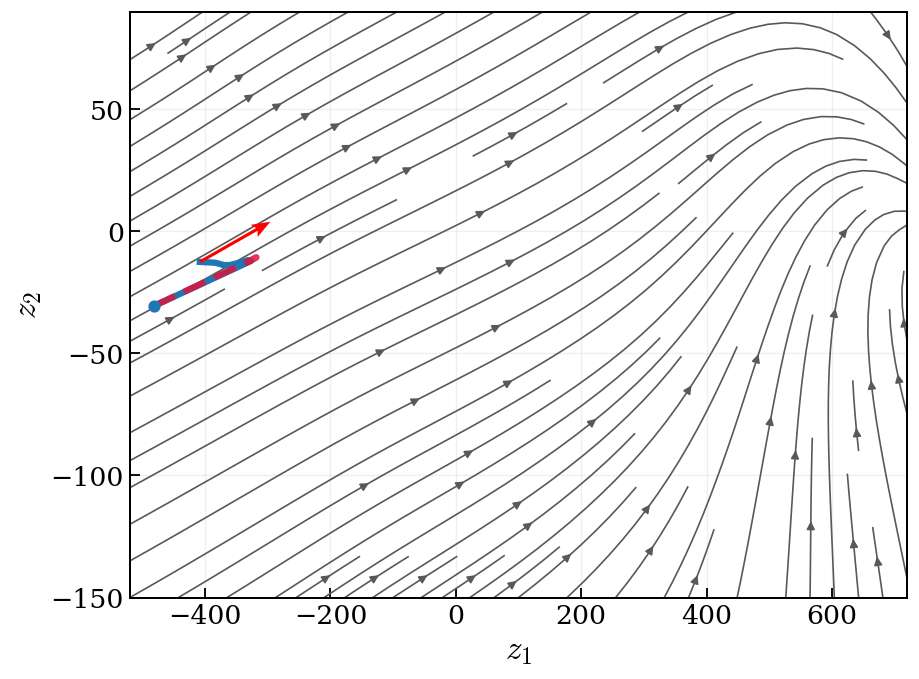

[slice plot] sim=804, traj_end_step=10
  conditioning time t = 14
  SP_raw = 200000
  e_raw  = 99053.4
  I_raw  = 94749.9


In [52]:
nodes_csv = "GOH_Nodes_Test_for_Visualization.csv"
elems_csv = "GOH_Elements_Test_for_Visualization.csv"
z1_lim = (-520, 720)
z2_lim = (-150, 90)

rollout, meta = rollout_and_plot_selected_sim_z1_z2_slice(
    r_modes=9,
    sim_id=804,
    nodes_csv=nodes_csv,
    elems_csv=elems_csv,
    grid_n=25,
    normalize_arrows=False,
    use_streamplot=True,
    traj_end_step=10,

    z1_lim=z1_lim,
    z2_lim=z2_lim,
    
    quiver_color="#b22222",
    quiver_alpha=0.85,
    quiver_width=0.0025,
    quiver_headwidth=4.0,
    quiver_headlength=5.0,
    quiver_headaxislength=4.5,
    quiver_linewidth=0.4,
    arrow_length_frac=0.6,
    show_terminal_tangent=True,
    show_true_traj=True,
    save_path="Model_A_sim804_step_10_show_true.png",

    
    pred_linewidth=3.8,
    true_linewidth=3.8,
    true_alpha=0.85,
    title=None,
    
)

In [ ]:
import numpy as np
import zarr

def job_id_to_sim_id(job_id):
    g_disp = zarr.open("Design_and_Metadata.zarr", mode="r")
    job_index_per_sim = g_disp["Mapping_indexes_and_metadata"]["job_index_per_sim"][:]

    matches = np.where(job_index_per_sim == job_id)[0]

    if len(matches) == 0:
        raise ValueError(f"No sim_id found for job_id={job_id}")
    elif len(matches) > 1:
        raise ValueError(f"Multiple sim_ids found for job_id={job_id}: {matches}")

    return int(matches[0])

[infer vanilla NODE arch]
  D_state = 10
  hidden  = 128
[bottom surface mesh — robust]
  node_xyz_bot: (3721, 3)
  elem_conn_bot: (3600, 4)
  node_id range: 3722 7442
  conn min/max: 0 3720
[load_disp_decoder] Using U='pod_full/U' shape=(11163, 10)
[load_disp_decoder] Using mean='pod_full/mean' shape=(11163,)
[load_disp_decoder] r_modes=9, N_nodes=3721
[sim 7] job_id=8  theta_crit=1.193  k1=2.2  k2=0.96
[rollout vanilla NODE] r=9, sim=7, steps=68
  Final L2 error: 54144.13
  Final volume error: 54141.5
  Pred final net area gain [cm^2]: 5.0128130771942345
[warn] Could not plot final displacement/growth fields: NameError("name 'get_true_u_nodes_for_sim_step' is not defined")
[infer vanilla NODE arch]
  D_state = 10
  hidden  = 128


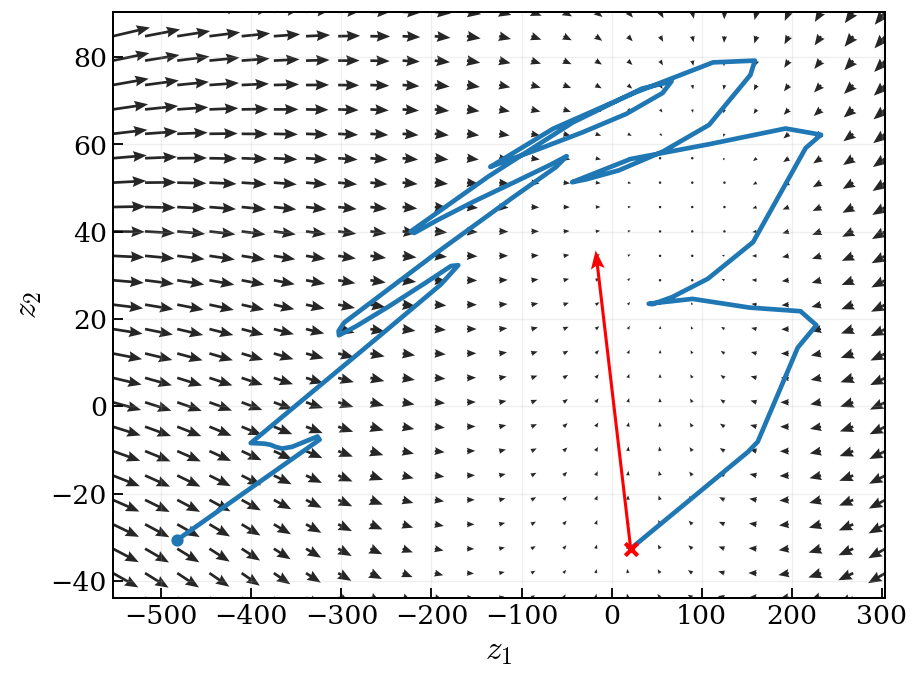

[slice plot] sim=7, traj_end_step=68
  conditioning time t = 98
  SP_raw = 673568
  e_raw  = 53225.7
  I_raw  = 216964


In [81]:
nodes_csv = "GOH_Nodes_Test_for_Visualization.csv"
elems_csv = "GOH_Elements_Test_for_Visualization.csv"
rollout, meta = rollout_and_plot_selected_sim_z1_z2_slice(
    r_modes=9,
    sim_id=7,
    nodes_csv=nodes_csv,
    elems_csv=elems_csv,
    grid_n=25,
    normalize_arrows=False,
    use_streamplot=False,

    quiver_color="black",
    quiver_alpha=0.85,
    quiver_width=0.0035,
    quiver_headwidth=4.0,
    quiver_headlength=5.0,
    quiver_headaxislength=4.5,
    quiver_linewidth=0.6,
    arrow_length_frac=0.6,

    pred_linewidth=2.8,
    true_linewidth=2.0,
    true_alpha=0.85,
    title=None,
)


## Plot the reconstructed displacement

In [188]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


def plot_rollout_reconstructed_displacement_3d(
    rollout: dict,
    nodes_csv: str,
    elems_csv: str,
    step_idx: int | None = None,
    scale: float = 1.0,
    color_by: str = "disp_mag",   # "disp_mag", "ux", "uy", "uz"
    cmap: str = "viridis",
    vmin: float | None = None,
    vmax: float | None = None,
    show_undeformed: bool = True,
    undeformed_alpha: float = 0.18,
    deformed_alpha: float = 1.0,
    edgecolor: str | None = None,
    linewidth: float = 0.0,
    elev: float = 22,
    azim: float = -60,
    figsize=(9, 7),
    title: str | None = None,
    axis_equal: bool = True,
    show_colorbar: bool = True,
    save_path: str | None = None,
    save_dpi: int = 400,
):
    """
    Plot reconstructed predicted displacement on the bottom-surface mesh
    for a specified rollout timepoint.

    Parameters
    ----------
    rollout : dict
        Output from rollout_single_sim_vanilla_node(...), must contain:
          - "u_pred_nodes": (T, N, 3)
          - "t": (T,)
          - "sim_id"
    nodes_csv, elems_csv : str
        Mesh files used by load_bottom_surface_mesh_direct.
    step_idx : int or None
        Rollout time index to plot. Defaults to final step.
    scale : float
        Visual scaling applied to displacement before plotting.
    color_by : str
        One of: "disp_mag", "ux", "uy", "uz".
    vmin, vmax : float or None
        Fixed color limits. If None, inferred from the selected frame.
    """

    if "u_pred_nodes" not in rollout:
        raise KeyError("rollout must contain 'u_pred_nodes'.")

    u_pred_nodes = np.asarray(rollout["u_pred_nodes"], dtype=np.float64)
    t_arr = np.asarray(rollout.get("t", []), dtype=np.float64)

    if u_pred_nodes.ndim != 3 or u_pred_nodes.shape[2] != 3:
        raise ValueError(f"Expected u_pred_nodes shape (T, N, 3), got {u_pred_nodes.shape}")

    T, N, _ = u_pred_nodes.shape
    if step_idx is None:
        step_idx = T - 1
    step_idx = int(np.clip(step_idx, 0, T - 1))

    # Load bottom surface mesh
    node_xyz_bot, elem_conn_bot, node_ids_bot, elem_node_ids_bot = load_bottom_surface_mesh_direct(
        nodes_csv, elems_csv
    )

    node_xyz_bot = np.asarray(node_xyz_bot, dtype=np.float64)
    elem_conn_bot = np.asarray(elem_conn_bot)

    if node_xyz_bot.shape[0] != N:
        raise ValueError(
            f"Mesh node count ({node_xyz_bot.shape[0]}) does not match rollout u_pred_nodes ({N})."
        )

    u = u_pred_nodes[step_idx]
    x_def = node_xyz_bot + scale * u

    if color_by == "disp_mag":
        node_scalar = np.linalg.norm(u, axis=1)
        cbar_label = r"$\|\mathbf{u}\|$"
    elif color_by == "ux":
        node_scalar = u[:, 0]
        cbar_label = r"$u_x$"
    elif color_by == "uy":
        node_scalar = u[:, 1]
        cbar_label = r"$u_y$"
    elif color_by == "uz":
        node_scalar = u[:, 2]
        cbar_label = r"$u_z$"
    else:
        raise ValueError("color_by must be one of: 'disp_mag', 'ux', 'uy', 'uz'")

    # Build polygon faces and per-face scalar
    faces_def = []
    faces_und = []
    face_scalar = []

    for conn in elem_conn_bot:
        conn = np.asarray(conn, dtype=int)

        pts_def = x_def[conn]
        pts_und = node_xyz_bot[conn]

        faces_def.append(pts_def)
        faces_und.append(pts_und)

        # Average nodal scalar to face color
        face_scalar.append(np.mean(node_scalar[conn]))

    face_scalar = np.asarray(face_scalar, dtype=np.float64)

    # Fixed or automatic color limits
    cmin = np.min(face_scalar) if vmin is None else float(vmin)
    cmax = np.max(face_scalar) if vmax is None else float(vmax)

    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection="3d")

    if show_undeformed:
        poly_und = Poly3DCollection(
            faces_und,
            facecolor=(0.7, 0.7, 0.7, undeformed_alpha),
            edgecolor="none",
            linewidth=0.0,
        )
        ax.add_collection3d(poly_und)

    poly_def = Poly3DCollection(
        faces_def,
        linewidth=linewidth,
        edgecolor=edgecolor if edgecolor is not None else "none",
        alpha=deformed_alpha,
    )
    poly_def.set_array(face_scalar)
    poly_def.set_cmap(cmap)
    poly_def.set_clim(cmin, cmax)
    ax.add_collection3d(poly_def)

    # Set axes limits from both undeformed and deformed geometry
    xyz_all = np.vstack([node_xyz_bot, x_def])
    xmin, ymin, zmin = xyz_all.min(axis=0)
    xmax, ymax, zmax = xyz_all.max(axis=0)

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_zlim(zmin, zmax)

    if axis_equal:
        ranges = np.array([xmax - xmin, ymax - ymin, zmax - zmin], dtype=float)
        max_range = np.max(ranges)
        xmid = 0.5 * (xmin + xmax)
        ymid = 0.5 * (ymin + ymax)
        zmid = 0.5 * (zmin + zmax)

        ax.set_xlim(xmid - 0.5 * max_range, xmid + 0.5 * max_range)
        ax.set_ylim(ymid - 0.5 * max_range, ymid + 0.5 * max_range)
        ax.set_zlim(0, zmid + 0.5 * max_range)

    ax.view_init(elev=elev, azim=azim)

    xticks = ax.get_xticks()
    yticks = ax.get_yticks()
    zticks = ax.get_zticks()

    # hide the default z-axis line
    ax.zaxis.line.set_color((0, 0, 0, 0))
    
    # draw a custom z-axis line only up to the highest tick you want
    z0, z1 = ax.get_zlim()
    ztop = 80   # highest tick you want the visible axis to reach
    
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    
    # choose the corner where matplotlib is drawing that z-axis
    x_axis_corner = xmax
    y_axis_corner = ymax
    
    ax.plot(
        [x_axis_corner, x_axis_corner],
        [y_axis_corner, y_axis_corner],
        [z0, ztop],
        color='k',
        lw=1.2
    )
    
    ax.set_xticks([0, 100, 200])
    ax.set_yticks([0, 100, 200])
    ax.set_zticks([0, 80])
    ax.tick_params(axis='x', labelbottom=False)
    ax.tick_params(axis='y', labelleft=False)
    ax.tick_params(axis='z', labelleft=False)
    ax.grid(False)
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor('white')
    ax.yaxis.pane.set_edgecolor('white')
    ax.zaxis.pane.set_edgecolor('white')
    
    sim_id = rollout.get("sim_id", "unknown")
    t_val = t_arr[step_idx] if len(t_arr) > step_idx else step_idx

    if title is None:
        title = f"Predicted reconstructed displacement | sim={sim_id} | step={step_idx} | t={t_val:.4g}"
    ax.set_title(title)

    if show_colorbar:
        mappable = plt.cm.ScalarMappable(cmap=cmap)
        mappable.set_array(face_scalar)
        mappable.set_clim(cmin, cmax)
        cbar = fig.colorbar(mappable, ax=ax, shrink=0.75, pad=0.08)
        cbar.set_label(cbar_label)

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=save_dpi, bbox_inches="tight")
        print(f"[saved figure] {save_path}")

    plt.show()

    return {
        "step_idx": step_idx,
        "t": float(t_val) if np.isscalar(t_val) else t_val,
        "u": u,
        "x_def": x_def,
        "node_scalar": node_scalar,
        "face_scalar": face_scalar,
        "vmin_used": cmin,
        "vmax_used": cmax,
    }

[bottom surface mesh — robust]
  node_xyz_bot: (3721, 3)
  elem_conn_bot: (3600, 4)
  node_id range: 3722 7442
  conn min/max: 0 3720
[saved figure] sim_804_rollout_disp_68_steps.png


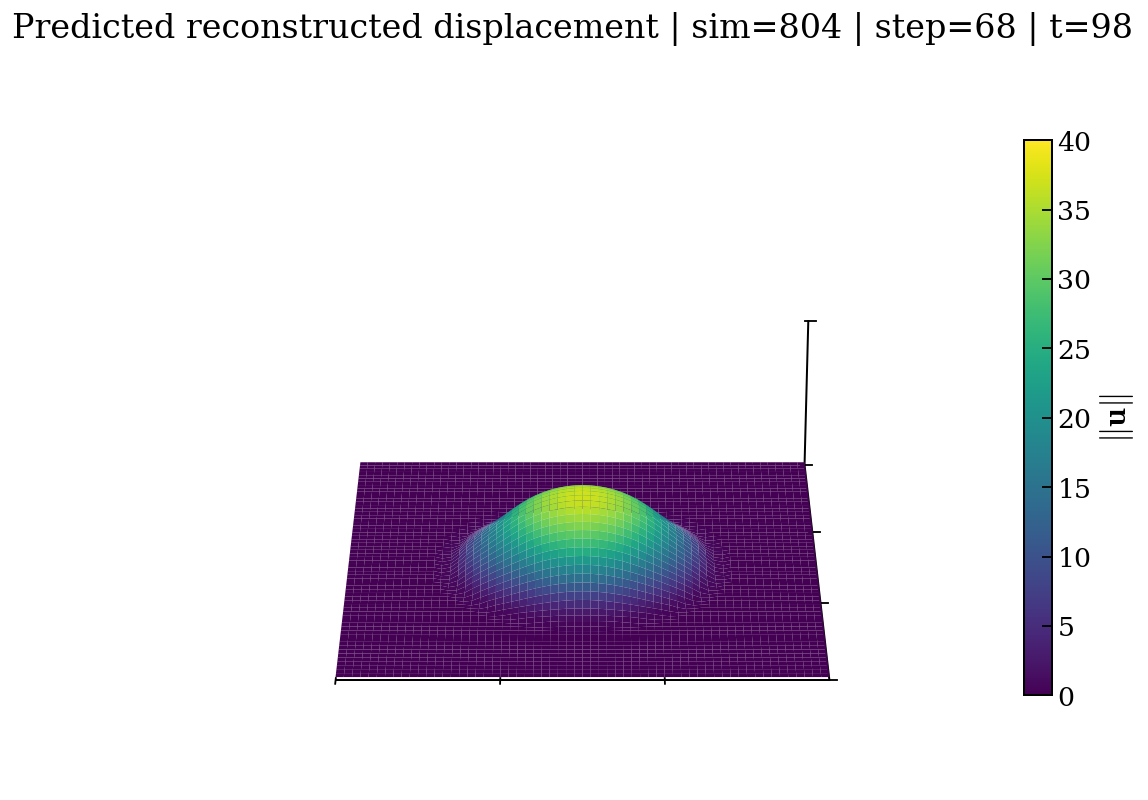

{'step_idx': 68,
 't': 98.0,
 'u': array([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]], shape=(3721, 3)),
 'x_def': array([[  0. ,   0. ,   1.5],
        [  0. ,   5. ,   1.5],
        [  0. ,  10. ,   1.5],
        ...,
        [300. , 290. ,   1.5],
        [300. , 295. ,   1.5],
        [300. , 300. ,   1.5]], shape=(3721, 3)),
 'node_scalar': array([0., 0., 0., ..., 0., 0., 0.], shape=(3721,)),
 'face_scalar': array([0., 0., 0., ..., 0., 0., 0.], shape=(3600,)),
 'vmin_used': 0.0,
 'vmax_used': 40.0}

In [200]:
plot_rollout_reconstructed_displacement_3d(
    rollout=rollout,
    nodes_csv=nodes_csv,
    elems_csv=elems_csv,
    step_idx=68,              # or None for final
    scale=1.0,
    color_by="disp_mag",
    cmap="viridis",
    show_undeformed=True,
    vmin=0.0,
    vmax=40.0,
    elev=25,
    azim=-90,
    save_dpi=500,
    save_path="sim_804_rollout_disp_68_steps.png",

)

## Plot Growth

In [206]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


def plot_rollout_growth_3d(
    rollout: dict,
    nodes_csv: str,
    elems_csv: str,
    step_idx: int | None = None,
    plot_on_deformed: bool = True,
    disp_scale: float = 1.0,
    color_by: str = "gx",   # "gx", "gy", "gmag"
    cmap: str = "viridis",
    vmin: float | None = None,
    vmax: float | None = None,
    show_undeformed: bool = True,
    undeformed_alpha: float = 0.18,
    deformed_alpha: float = 1.0,
    edgecolor: str | None = None,
    linewidth: float = 0.0,
    elev: float = 22,
    azim: float = -60,
    figsize=(9, 7),
    title: str | None = None,
    axis_equal: bool = True,
    show_colorbar: bool = True,
    save_path: str | None = None,
    save_dpi: int = 400,
):
    """
    Plot predicted growth on the bottom-surface mesh for a specified rollout timepoint.

    Parameters
    ----------
    rollout : dict
        Must contain:
          - "lamdag_pred_elem": (T, Ne, 2)
          - "u_pred_nodes": (T, N, 3) if plot_on_deformed=True
          - "t": (T,)
          - "sim_id"
    nodes_csv, elems_csv : str
        Mesh files used by load_bottom_surface_mesh_direct.
    step_idx : int or None
        Rollout time index to plot. Defaults to final step.
    plot_on_deformed : bool
        If True, show growth on the deformed mesh at that step.
        If False, show growth on the undeformed mesh.
    disp_scale : float
        Visual scaling applied to displacement before plotting if plot_on_deformed=True.
    color_by : str
        One of: "gx", "gy", "gmag".
    vmin, vmax : float or None
        Fixed color limits. If None, inferred from selected frame.
    """

    if "lamdag_pred_elem" not in rollout:
        raise KeyError("rollout must contain 'lamdag_pred_elem'.")

    lamdag_pred_elem = np.asarray(rollout["lamdag_pred_elem"], dtype=np.float64)
    t_arr = np.asarray(rollout.get("t", []), dtype=np.float64)

    if lamdag_pred_elem.ndim != 3 or lamdag_pred_elem.shape[2] != 2:
        raise ValueError(
            f"Expected lamdag_pred_elem shape (T, Ne, 2), got {lamdag_pred_elem.shape}"
        )

    T, Ne, _ = lamdag_pred_elem.shape
    if step_idx is None:
        step_idx = T - 1
    step_idx = int(np.clip(step_idx, 0, T - 1))

    # Load bottom surface mesh
    node_xyz_bot, elem_conn_bot, node_ids_bot, elem_node_ids_bot = load_bottom_surface_mesh_direct(
        nodes_csv, elems_csv
    )

    node_xyz_bot = np.asarray(node_xyz_bot, dtype=np.float64)
    elem_conn_bot = np.asarray(elem_conn_bot)

    if elem_conn_bot.shape[0] != Ne:
        raise ValueError(
            f"Mesh element count ({elem_conn_bot.shape[0]}) does not match "
            f"rollout lamdag_pred_elem ({Ne})."
        )

    # Choose plotting geometry
    if plot_on_deformed:
        if "u_pred_nodes" not in rollout:
            raise KeyError("rollout must contain 'u_pred_nodes' when plot_on_deformed=True.")
        u_pred_nodes = np.asarray(rollout["u_pred_nodes"], dtype=np.float64)
        if u_pred_nodes.ndim != 3 or u_pred_nodes.shape[2] != 3:
            raise ValueError(f"Expected u_pred_nodes shape (T, N, 3), got {u_pred_nodes.shape}")
        if u_pred_nodes.shape[1] != node_xyz_bot.shape[0]:
            raise ValueError(
                f"Mesh node count ({node_xyz_bot.shape[0]}) does not match "
                f"rollout u_pred_nodes ({u_pred_nodes.shape[1]})."
            )
        u = u_pred_nodes[step_idx]
        plot_xyz = node_xyz_bot + disp_scale * u
    else:
        plot_xyz = node_xyz_bot.copy()

    g_elem = lamdag_pred_elem[step_idx]

    if color_by == "gx":
        face_scalar = g_elem[:, 0]
        cbar_label = r"$\lambda^g_x$"
    elif color_by == "gy":
        face_scalar = g_elem[:, 1]
        cbar_label = r"$\lambda^g_y$"
    elif color_by == "gmag":
        face_scalar = np.linalg.norm(g_elem, axis=1)
        cbar_label = r"$\|\lambda^g\|$"
    else:
        raise ValueError("color_by must be one of: 'gx', 'gy', 'gmag'")

    # Build polygons
    faces_plot = []
    faces_und = []

    for conn in elem_conn_bot:
        conn = np.asarray(conn, dtype=int)
        faces_plot.append(plot_xyz[conn])
        faces_und.append(node_xyz_bot[conn])

    # Fixed or automatic color limits
    cmin = np.min(face_scalar) if vmin is None else float(vmin)
    cmax = np.max(face_scalar) if vmax is None else float(vmax)

    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection="3d")

    if show_undeformed and plot_on_deformed:
        poly_und = Poly3DCollection(
            faces_und,
            facecolor=(0.7, 0.7, 0.7, undeformed_alpha),
            edgecolor="none",
            linewidth=0.0,
        )
        ax.add_collection3d(poly_und)

    poly = Poly3DCollection(
        faces_plot,
        linewidth=linewidth,
        edgecolor=edgecolor if edgecolor is not None else "none",
        alpha=deformed_alpha,
    )
    poly.set_array(face_scalar)
    poly.set_cmap(cmap)
    poly.set_clim(cmin, cmax)
    ax.add_collection3d(poly)

    # Axes limits
    xyz_all = np.vstack([node_xyz_bot, plot_xyz])
    xmin, ymin, zmin = xyz_all.min(axis=0)
    xmax, ymax, zmax = xyz_all.max(axis=0)

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_zlim(zmin, zmax)

    if axis_equal:
        ranges = np.array([xmax - xmin, ymax - ymin, zmax - zmin], dtype=float)
        max_range = np.max(ranges)
        xmid = 0.5 * (xmin + xmax)
        ymid = 0.5 * (ymin + ymax)
        zmid = 0.5 * (zmin + zmax)

        ax.set_xlim(xmid - 0.5 * max_range, xmid + 0.5 * max_range)
        ax.set_ylim(ymid - 0.5 * max_range, ymid + 0.5 * max_range)
        ax.set_zlim(0, zmid + 0.5 * max_range)

    ax.view_init(elev=elev, azim=azim)

    xticks = ax.get_xticks()
    yticks = ax.get_yticks()
    zticks = ax.get_zticks()

    # hide the default z-axis line
    ax.zaxis.line.set_color((0, 0, 0, 0))

    # draw a custom z-axis line
    z0, z1 = ax.get_zlim()
    ztop = 80

    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    x_axis_corner = xmax
    y_axis_corner = ymax

    ax.plot(
        [x_axis_corner, x_axis_corner],
        [y_axis_corner, y_axis_corner],
        [z0, ztop],
        color='k',
        lw=1.2
    )

    ax.set_xticks([0, 100, 200])
    ax.set_yticks([0, 100, 200])
    ax.set_zticks([0, 80])
    ax.tick_params(axis='x', labelbottom=False)
    ax.tick_params(axis='y', labelleft=False)
    ax.tick_params(axis='z', labelleft=False)
    
    ax.grid(False)
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor('white')
    ax.yaxis.pane.set_edgecolor('white')
    ax.zaxis.pane.set_edgecolor('white')

    sim_id = rollout.get("sim_id", "unknown")
    t_val = t_arr[step_idx] if len(t_arr) > step_idx else step_idx

    if title is None:
        surf_str = "deformed" if plot_on_deformed else "undeformed"
        title = f"Predicted growth ({color_by}) on {surf_str} mesh | sim={sim_id} | step={step_idx} | t={t_val:.4g}"
    ax.set_title(title)

    if show_colorbar:
        mappable = plt.cm.ScalarMappable(cmap=cmap)
        mappable.set_array(face_scalar)
        mappable.set_clim(cmin, cmax)
        cbar = fig.colorbar(mappable, ax=ax, shrink=0.75, pad=0.08)
        cbar.set_label(cbar_label)

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=save_dpi, bbox_inches="tight")
        print(f"[saved figure] {save_path}")

    plt.show()

    return {
        "step_idx": step_idx,
        "t": float(t_val) if np.isscalar(t_val) else t_val,
        "face_scalar": face_scalar,
        "plot_xyz": plot_xyz,
        "vmin_used": cmin,
        "vmax_used": cmax,
    }

[bottom surface mesh — robust]
  node_xyz_bot: (3721, 3)
  elem_conn_bot: (3600, 4)
  node_id range: 3722 7442
  conn min/max: 0 3720


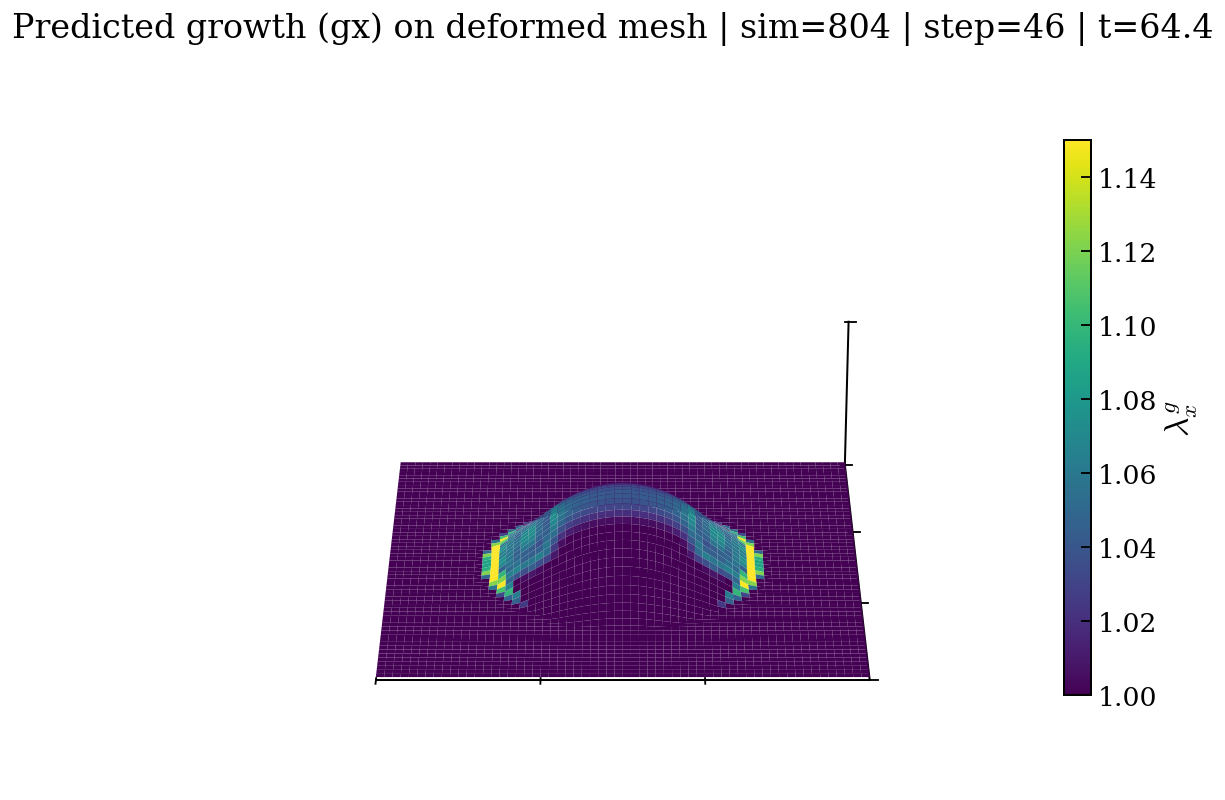

{'step_idx': 46,
 't': 64.4000015258789,
 'face_scalar': array([1., 1., 1., ..., 1., 1., 1.], shape=(3600,)),
 'plot_xyz': array([[  0. ,   0. ,   1.5],
        [  0. ,   5. ,   1.5],
        [  0. ,  10. ,   1.5],
        ...,
        [300. , 290. ,   1.5],
        [300. , 295. ,   1.5],
        [300. , 300. ,   1.5]], shape=(3721, 3)),
 'vmin_used': 1.0,
 'vmax_used': 1.15}

In [227]:
plot_rollout_growth_3d(
    rollout=rollout,
    nodes_csv=nodes_csv,
    elems_csv=elems_csv,
    step_idx=45,
    plot_on_deformed=True,
    disp_scale=1.0,
    color_by="gy",
    vmin=1.0,
    vmax=1.15,
    save_dpi=500,
    elev=25,
    azim=-90,
    save_path="sim_804_rollout_gy_45_steps.png",
)

# Model D

In [53]:
# ===============================
# Core imports (required for training)
# ===============================
import os
import numpy as np
import zarr
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from typing import Tuple, List


# ===============================
# Paths & templates (used by dataset + training)
# ===============================
ZARR_DISP  = "displacements.zarr"
ZARR_SDV   = "ip_growth_elem.zarr"               # lambda_g_x, lambda_g_y latents
ZARR_VOL   = "expd_volumes.zarr"
DESIGN_ZARR_PATH = "Design_and_Metadata.zarr"

U_LATENT_TEMPLATE = "latent_displ_r{r}/coeffs"


# ===============================
# Training hyperparameters
# ===============================
BATCH_SIZE   = 256
N_EPOCHS     = 20
LR           = 1e-3
SEED         = 123

CTRL_DIM   = 1   # volume setpoint
PARAM_DIM  = 7   # design params

# Nominal timestep (used only for rollouts / metadata)
FIXED_DT   = 1.4


# ===============================
# Reproducibility
# ===============================
def set_seed(seed: int = SEED):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [54]:
def load_raw_data(r_modes: int):
    """
    Load raw data for a given r_modes (per field).
    Returns:
        U_lat        : (S, r)
        volume_snap  : (S,)   actual expander volume per snapshot
        G_field      : (S, 2, H, W) OR (S, 2, N)  (teacher-forced growth fields: x and y)
        sim_index    : (S,)
        time_vals    : (S,)
        volume_SP    : (S,)   volume setpoint per snapshot
        design_all   : (S, 7)
        n_sims       : int
    """
    from pathlib import Path

    g_disp   = zarr.open_group(ZARR_DISP, mode="r")
    g_design = zarr.open_group(DESIGN_ZARR_PATH, mode="r")
    g_sdv    = zarr.open_group(ZARR_SDV, mode="r")   # contains snaps_SDV1 and snaps_SDV4

    vol_root = Path(ZARR_VOL)

    u_path = U_LATENT_TEMPLATE.format(r=r_modes)
    U_lat = np.asarray(g_disp[u_path], dtype=np.float32).T  # (S, r)

    mgrp = g_design["Mapping_indexes_and_metadata"]
    sim_index = np.asarray(mgrp["sim_index"], dtype=np.int64)
    time_vals = np.asarray(mgrp["time_vals"], dtype=np.float64)

    volume_SP = np.asarray(
        zarr.open_array(str(vol_root / "volume_setpoint_per_snapshot"), mode="r"),
        dtype=np.float32
    )

    design_all = np.asarray(
        g_design["design_params_per_snapshot"], dtype=np.float32
    )

    S = U_lat.shape[0]
    assert sim_index.shape[0] == S == time_vals.shape[0]
    assert volume_SP.shape[0] == S == design_all.shape[0]

    volume_snap = np.asarray(
        zarr.open_array(str(vol_root / "expander_volume" / "cvol"), mode="r"),
        dtype=np.float32
    )
    if volume_snap.ndim != 1 or volume_snap.shape[0] != S:
        raise ValueError(f"Expected cvol as (S,) with S={S}, got shape {volume_snap.shape}")
    return (
        U_lat,
        volume_snap,
        sim_index,
        time_vals,
        volume_SP,
        design_all,
        len(np.unique(sim_index)),
    )


In [55]:
import numpy as np

def load_bottom_surface_mesh_direct(nodes_csv: str, elems_csv: str):
    """
    Robust bottom-surface mesh loader:

    - elems_csv contains both layers; bottom layer is second half of rows
    - bottom nodes are defined as the unique node IDs referenced by bottom elements
      (this is the only assumption that cannot be broken by file ordering)

    Returns:
      node_xyz_bot : (Nbot, 3)
      elem_conn_bot: (Ne_bot, 4) 0-based indices into node_xyz_bot
      node_ids_bot : (Nbot,)     node IDs corresponding to node_xyz_bot rows
      elem_node_ids_bot : (Ne_bot,4) original node IDs for debugging
    """
    nodes = np.loadtxt(nodes_csv, delimiter=",")
    elems = np.loadtxt(elems_csv, delimiter=",")

    node_ids = nodes[:, 0].astype(np.int64)
    node_xyz = nodes[:, 1:4].astype(np.float64)

    elem_ids = elems[:, 0].astype(np.int64)
    elem_node_ids = elems[:, 1:5].astype(np.int64)
    Ne = elem_node_ids.shape[0]
    if Ne % 2 != 0:
        raise ValueError(f"Expected even number of elements (2 layers), got Ne={Ne}")

    # bottom layer = second half of element rows
    half = Ne // 2
    elem_node_ids_bot = elem_node_ids[half:, :]   # (Ne_bot, 4)

    # bottom node IDs = unique node IDs referenced by bottom elements
    bottom_node_ids = np.unique(elem_node_ids_bot.reshape(-1))

    # pull those nodes from nodes_csv
    # (use a dict for fast lookup by ID)
    id2xyz = {int(nid): node_xyz[i] for i, nid in enumerate(node_ids)}

    missing = [int(nid) for nid in bottom_node_ids if int(nid) not in id2xyz]
    if len(missing) > 0:
        raise ValueError(
            f"{len(missing)} node IDs referenced by bottom elements are missing from nodes_csv. "
            f"Example missing IDs: {missing[:10]}"
        )

    # build bottom node table, sorted by node_id
    node_ids_bot = np.sort(bottom_node_ids.astype(np.int64))
    node_xyz_bot = np.vstack([id2xyz[int(nid)] for nid in node_ids_bot]).astype(np.float64)

    # map node_id -> local index [0..Nbot-1]
    id2bot = {int(nid): i for i, nid in enumerate(node_ids_bot)}

    # remap element connectivity to local indices
    get_idx = np.vectorize(lambda nid: id2bot.get(int(nid), -1), otypes=[np.int64])
    elem_conn_bot = get_idx(elem_node_ids_bot)

    bad = np.where(elem_conn_bot < 0)
    if bad[0].size > 0:
        ei = int(bad[0][0])
        raise ValueError(
            "Internal mapping failure (shouldn't happen if missing-check passed).\n"
            f"Example bad elem row: {ei}\n"
            f"elem_node_ids_bot[ei] = {elem_node_ids_bot[ei]}\n"
            f"elem_conn_bot[ei]     = {elem_conn_bot[ei]}"
        )

    print("[bottom surface mesh — robust]")
    print("  node_xyz_bot:", node_xyz_bot.shape)
    print("  elem_conn_bot:", elem_conn_bot.shape)
    print("  node_id range:", int(node_ids_bot.min()), int(node_ids_bot.max()))
    print("  conn min/max:", int(elem_conn_bot.min()), int(elem_conn_bot.max()))

    return node_xyz_bot, elem_conn_bot, node_ids_bot, elem_node_ids_bot


In [56]:
def load_raw_data(r_modes: int):
    """
    Load raw data for a given r_modes (per field).
    Returns:
        U_lat        : (S, r)
        volume_snap  : (S,)   actual expander volume per snapshot
        G_field      : (S, 2, H, W) OR (S, 2, N)  (teacher-forced growth fields: x and y)
        sim_index    : (S,)
        time_vals    : (S,)
        volume_SP    : (S,)   volume setpoint per snapshot
        design_all   : (S, 7)
        n_sims       : int
    """
    from pathlib import Path

    g_disp   = zarr.open_group(ZARR_DISP, mode="r")
    g_design = zarr.open_group(DESIGN_ZARR_PATH, mode="r")
    g_sdv    = zarr.open_group(ZARR_SDV, mode="r")   # contains snaps_SDV1 and snaps_SDV4

    vol_root = Path(ZARR_VOL)

    u_path = U_LATENT_TEMPLATE.format(r=r_modes)
    U_lat = np.asarray(g_disp[u_path], dtype=np.float32).T  # (S, r)

    mgrp = g_design["Mapping_indexes_and_metadata"]
    sim_index = np.asarray(mgrp["sim_index"], dtype=np.int64)
    time_vals = np.asarray(mgrp["time_vals"], dtype=np.float64)

    volume_SP = np.asarray(
        zarr.open_array(str(vol_root / "volume_setpoint_per_snapshot"), mode="r"),
        dtype=np.float32
    )

    design_all = np.asarray(
        g_design["design_params_per_snapshot"], dtype=np.float32
    )

    S = U_lat.shape[0]
    assert sim_index.shape[0] == S == time_vals.shape[0]
    assert volume_SP.shape[0] == S == design_all.shape[0]

    volume_snap = np.asarray(
        zarr.open_array(str(vol_root / "expander_volume" / "cvol"), mode="r"),
        dtype=np.float32
    )
    if volume_snap.ndim != 1 or volume_snap.shape[0] != S:
        raise ValueError(f"Expected cvol as (S,) with S={S}, got shape {volume_snap.shape}")
    return (
        U_lat,
        volume_snap,
        sim_index,
        time_vals,
        volume_SP,
        design_all,
        len(np.unique(sim_index)),
    )


In [57]:
# --- Displacement POD + snapshot path info (adjust names if needed) ---
DISP_POD_GROUP       = "pod_full"     # inside displacements.zarr
DISP_POD_U_NAME      = "U"            # dataset with basis vectors
DISP_POD_MEAN_NAME   = "mean"         # dataset with mean
DISP_SNAP_DATASET    = "snapshots"    # full-order snapshots in displacements.zarr


In [58]:
#Global Cache for the Coord and Connectivity CSVs
_BOTTOM_GRID_CACHE = None

def get_bottom_grid_cache():
    global _BOTTOM_GRID_CACHE
    if _BOTTOM_GRID_CACHE is None:
        H, W, bottom_idx, *_ = build_bottom_surface_elem_grid_mapping(
            nodes_csv="GOH_Nodes_Test_for_Visualization.csv",
            elems_csv="GOH_Elements_Test_for_Visualization.csv",
            tol_xy=1e-8,
        )
        _BOTTOM_GRID_CACHE = (H, W, bottom_idx)
    return _BOTTOM_GRID_CACHE


In [59]:
import numpy as np

def build_bottom_surface_elem_grid_mapping(
    nodes_csv: str = "GOH_Nodes_Test_for_Visualization.csv",
    elems_csv: str = "GOH_Elements_Test_for_Visualization.csv",
    tol_xy: float = 1e-8,
):
    """
    Build a structured (H,W) grid mapping for a two-layer quad mesh by selecting
    ONLY the bottom layer (smaller element centroid z) at each in-plane (x,y) cell.

    Assumed CSV formats (no headers):
      Nodes: [node_id, x, y, z]   (z required here)
      Elems: [elem_id, n1, n2, n3, n4]  (quads)

    Returns:
      H, W: inferred grid shape from unique centroid x/y positions
      bottom_elem_idx: (H*W,) element indices (0..Ne-1) selecting bottom element per cell
      cell_xy: (H*W, 2) centroid (x,y) per cell (for debugging)
      elem_id: (Ne,) element ids
      node_id: (Nn,) node ids
      node_xyz: (Nn,3)
      elem_conn_local: (Ne,4) node indices (0..Nn-1)
      xs, ys: grid lines (unique x and y centroid coords)
    """
    # ---- load nodes ----
    nodes = np.loadtxt(nodes_csv, delimiter=",", dtype=np.float64)
    if nodes.ndim != 2 or nodes.shape[1] < 4:
        raise ValueError(
            f"Nodes CSV must have 4 cols [id,x,y,z] (no headers). Got shape {nodes.shape}"
        )

    node_id = nodes[:, 0].astype(np.int64)
    node_xyz = nodes[:, 1:4].astype(np.float64)  # (Nn,3)

    node_id_to_local = {int(nid): i for i, nid in enumerate(node_id)}

    # ---- load elements ----
    elems = np.loadtxt(elems_csv, delimiter=",", dtype=np.int64)
    if elems.ndim != 2 or elems.shape[1] < 5:
        raise ValueError(
            f"Elements CSV must have >=5 cols [eid,n1,n2,n3,n4] (no headers). Got shape {elems.shape}"
        )

    elem_id = elems[:, 0].astype(np.int64)
    elem_conn_ids = elems[:, 1:5].astype(np.int64)  # (Ne,4)
    Ne = elem_conn_ids.shape[0]

    # Convert node IDs -> local node indices
    elem_conn_local = np.empty((Ne, 4), dtype=np.int64)
    for a in range(4):
        try:
            elem_conn_local[:, a] = np.array(
                [node_id_to_local[int(nid)] for nid in elem_conn_ids[:, a]],
                dtype=np.int64
            )
        except KeyError as e:
            raise KeyError(f"Element connectivity references node id not found: {e}")

    # ---- element centroids ----
    cent = node_xyz[elem_conn_local].mean(axis=1)  # (Ne,3)
    xe, ye, ze = cent[:, 0], cent[:, 1], cent[:, 2]

    # Quantize x,y to remove floating noise
    xe_q = np.round(xe / tol_xy) * tol_xy
    ye_q = np.round(ye / tol_xy) * tol_xy

    # Build grid lines
    xs = np.unique(xe_q); xs.sort()
    ys = np.unique(ye_q); ys.sort()
    W = xs.size
    H = ys.size
    n_cells = H * W

    ix = np.searchsorted(xs, xe_q)
    iy = np.searchsorted(ys, ye_q)
    cell = (iy * W + ix).astype(np.int64)  # (Ne,)

    # ---- select bottom element per cell (min z) ----
    bottom_elem_idx = np.full(n_cells, -1, dtype=np.int64)
    best_z = np.full(n_cells, np.inf, dtype=np.float64)

    for e in range(Ne):
        c = cell[e]
        if ze[e] < best_z[c]:
            best_z[c] = ze[e]
            bottom_elem_idx[c] = e

    occupied = bottom_elem_idx >= 0
    if not np.all(occupied):
        missing = np.where(~occupied)[0][:10]
        raise ValueError(
            f"Some grid cells have no assigned element (unexpected for structured mesh). "
            f"Example missing cell indices: {missing}"
        )

    # Debug: check it really reduced 2 layers -> 1 per cell
    # Count elements per cell (should be 2 for most cells in a 2-layer mesh)
    counts = np.bincount(cell, minlength=n_cells)
    print(f"[bottom mapping] Ne={Ne}, grid H={H}, W={W}, H*W={n_cells}")
    print(f"[bottom mapping] per-cell counts: min={counts[counts>0].min()}, max={counts.max()}, "
          f"unique occupied cells={np.count_nonzero(counts)}")
    print(f"[bottom mapping] selected bottom elems: {bottom_elem_idx.shape[0]} (should equal H*W)")

    # For debugging: centroid (x,y) per cell (from selected bottom element)
    cell_xy = np.stack([xe[bottom_elem_idx], ye[bottom_elem_idx]], axis=1)

    return H, W, bottom_elem_idx, cell_xy, elem_id, node_id, node_xyz, elem_conn_local, xs, ys


def rasterize_bottom_surface_field(
    vec_elem: np.ndarray,          # (Ne,)
    H: int, W: int,
    bottom_elem_idx: np.ndarray,   # (H*W,)
):
    """
    Convert an element field vector (Ne,) into a bottom-surface grid image (H,W)
    by selecting vec_elem at bottom_elem_idx for each cell.
    """
    flat = vec_elem[bottom_elem_idx]          # (H*W,)
    return flat.reshape(H, W)


In [60]:
import numpy as np
import zarr

def load_disp_decoder(
    r_modes: int,
    zarr_disp_path: str = "displacements.zarr",
    pod_group: str = "pod_full",
    pod_u_name: str = "U",
    pod_mean_name: str = "mean",
    verbose: bool = True,
):
    """
    Returns a callable decode(alpha)->u_nodes (N,3).
    Assumes flatten order: [ux_block, uy_block, uz_block].
    """
    g_disp = zarr.open_group(zarr_disp_path, mode="r")

    U_key  = f"{pod_group}/{pod_u_name}"
    mu_key = f"{pod_group}/{pod_mean_name}"

    # Load POD basis + mean
    U_full = np.asarray(g_disp[U_key])               # (M, Rmax) typically
    mu     = np.asarray(g_disp[mu_key]).reshape(-1)  # (M,)

    if U_full.ndim != 2:
        raise ValueError(f"Expected POD basis U to be 2D (M,Rmax). Got {U_full.shape} at '{U_key}'")

    M, Rmax = U_full.shape
    if mu.shape[0] != M:
        raise ValueError(f"Mean length must match basis rows M={M}. Got mu.shape={mu.shape} at '{mu_key}'")

    if r_modes > Rmax:
        raise ValueError(f"Requested r_modes={r_modes} exceeds available Rmax={Rmax} in '{U_key}'")

    U_r = U_full[:, :r_modes]

    # Infer node count from block layout [ux, uy, uz]
    if M % 3 != 0:
        raise ValueError(f"Expected M divisible by 3 for [ux,uy,uz] blocks. Got M={M}")
    N = M // 3

    if verbose:
        print(f"[load_disp_decoder] Using U='{U_key}' shape={U_full.shape}")
        print(f"[load_disp_decoder] Using mean='{mu_key}' shape={mu.shape}")
        print(f"[load_disp_decoder] r_modes={r_modes}, N_nodes={N}")

    def decode(alpha: np.ndarray) -> np.ndarray:
        alpha = np.asarray(alpha).reshape(-1)
        if alpha.shape[0] != r_modes:
            raise ValueError(f"alpha must have shape ({r_modes},), got {alpha.shape}")

        u_flat = mu + U_r @ alpha  # (M,)
        ux = u_flat[0:N]
        uy = u_flat[N:2*N]
        uz = u_flat[2*N:3*N]
        return np.stack([ux, uy, uz], axis=1)  # (N,3)

    return decode


In [61]:
import numpy as np
import zarr

def get_growth_params_for_sim(sim_id: int):
    """
    Map sim_id -> job_id using displacements.zarr/mapping/job_index_per_sim,
    then read the correct row from the design file:
        'PGOH_Ideal_tol_Tcrit_V_mu_kk1_kk2_kappa_k1_design.txt'

    The design file:
        - Has a header row to skip
        - Each subsequent row corresponds to job_id = line_number (1-based)
        - Columns are comma- or space-delimited
        - We extract columns 2, 5, 6 (0-based) as:
             theta_crit = col 2
             k1         = col 5
             k2         = col 6
    """

    # --- 1) sim_id -> job_id ---
    g_disp = zarr.open("Design_and_Metadata.zarr", mode="r")
    job_index_per_sim = g_disp["Mapping_indexes_and_metadata"]["job_index_per_sim"][:]  # shape (n_sims,)
    job_id = int(job_index_per_sim[sim_id])   # job index for this sim (1-based!)

    # --- 2) Load design table from text file ---
    design_file = "PGOH_Ideal_tol_Tcrit_V_mu_kk1_kk2_kappa_k1_design.txt"

    # Load skipping header, allowing space or comma separators
    design_table = np.loadtxt(design_file, skiprows=0)

    # Because job_id is 1-based, convert to 0-based row index:
    row_index = job_id - 1

    if row_index < 0 or row_index >= design_table.shape[0]:
        raise IndexError(
            f"Job ID {job_id} (row idx {row_index}) is out of range for design table "
            f"with {design_table.shape[0]} rows."
        )

    row = design_table[row_index]

    # --- 3) Extract θ_crit, k1, k2 ---
    theta_crit = float(row[2])   # column 2 (0-based index)
    k1         = float(row[5])   # column 5
    k2         = float(row[6])   # column 6

    return job_id, theta_crit, k1, k2


In [62]:
import zarr

def load_elem_growth_for_sim(
    sim_id: int,
    sim_index: np.ndarray,
    time_vals: np.ndarray,
    zarr_sdv_path: str = "ip_growth_elem.zarr",
    folder_x: str = "snaps_SDV1",
    folder_y: str = "snaps_SDV4",
):
    """
    Returns element growth for this sim for ALL frames:
      t_sim: (T,)
      Gx_sim: (T, Ne)
      Gy_sim: (T, Ne)
      idx_sorted: (T,) global snapshot indices for this sim
    """
    g_sdv = zarr.open_group(zarr_sdv_path, mode="r")

    def _load_snap_folder(folder_name: str) -> np.ndarray:
        candidates = [
            f"{folder_name}/{folder_name}",
            f"{folder_name}/data",
            f"{folder_name}/snaps",
            f"{folder_name}",
        ]
        last_err = None
        for key in candidates:
            try:
                return np.asarray(g_sdv[key], dtype=np.float32)
            except Exception as e:
                last_err = e
        raise KeyError(f"Could not load '{folder_name}'. Tried={candidates}. Last error={repr(last_err)}")

    Gx_raw = _load_snap_folder(folder_x)
    Gy_raw = _load_snap_folder(folder_y)

    # select frames for this sim
    idx = np.where(sim_index == sim_id)[0]
    if idx.size < 2:
        raise ValueError(f"Sim {sim_id} has too few frames ({idx.size}).")

    t_s = time_vals[idx]
    order = np.argsort(t_s)
    idx_sorted = idx[order]
    t_sim = t_s[order]

    # Make snapshot-major: (S, Ne)
    S = sim_index.shape[0]
    if Gx_raw.shape[1] == S:   # (Ne, S)
        Gx_all = Gx_raw.T
    else:                      # assume (S, Ne)
        Gx_all = Gx_raw

    if Gy_raw.shape[1] == S:
        Gy_all = Gy_raw.T
    else:
        Gy_all = Gy_raw

    # slice sim
    Gx_sim = Gx_all[idx_sorted, :]  # (T, Ne)
    Gy_sim = Gy_all[idx_sorted, :]  # (T, Ne)

    return t_sim, Gx_sim, Gy_sim, idx_sorted


In [63]:
def integrate_growth_fast(node_coords, elem_conn, node_u, elem_lamdag, k1, k2, theta_crit, time, dt=1.4):
    dN_dxi, dN_deta = shape_function_gradients(0.0, 0.0)  # compute once per call
    dN_dxi  = np.asarray(dN_dxi,  dtype=np.float64).reshape(4,)
    dN_deta = np.asarray(dN_deta, dtype=np.float64).reshape(4,)
    return integrate_growth_numba(
        np.asarray(node_coords, dtype=np.float64),
        np.asarray(elem_conn, dtype=np.int64),
        np.asarray(node_u, dtype=np.float64),
        np.asarray(elem_lamdag, dtype=np.float64),
        float(k1), float(k2), float(theta_crit), float(time), float(dt),
        dN_dxi, dN_deta
    )

In [64]:
import numpy as np

def shape_function_gradients(xi, eta):
    """Return arrays dN_dxi, dN_deta of length 4 for bilinear quad."""
    dN_dxi = np.array([
        -(1 - eta) / 4,
         (1 - eta) / 4,
         (1 + eta) / 4,
        -(1 + eta) / 4
    ])
    dN_deta = np.array([
        -(1 - xi) / 4,
        -(1 + xi) / 4,
         (1 + xi) / 4,
         (1 - xi) / 4
    ])
    return dN_dxi, dN_deta

# Example: compute Gξ and Gη for one element
# Suppose nodal coordinates X are shape (4,3), each row is a node [x,y,z]
X_elem = np.array([
    [0.0, 0.0, 0.0],   # node 1
    [1.0, 0.0, 0.0],   # node 2
    [1.0, 1.0, 0.0],   # node 3
    [0.0, 1.0, 0.0]    # node 4
])

xi, eta = 0.0, 0.0  # evaluate at element center
dN_dxi, dN_deta = shape_function_gradients(xi, eta)

# Gξ and Gη are 3D vectors
Gxi = X_elem.T @ dN_dxi   # (3,) vector
Geta = X_elem.T @ dN_deta # (3,) vector

print("Gxi =", Gxi)
print("Geta =", Geta)


Gxi = [0.5 0.  0. ]
Geta = [0.  0.5 0. ]


In [65]:
def evalN1(xi,eta):
  N1 = (1 - xi)*(1 - eta) / 4
  return N1
def evalN2(xi,eta):
  N2 = (1 + xi)*(1 - eta) / 4
  return N2
def evalN3(xi,eta):
  N3 = (1 + xi)*(1 + eta) / 4
  return N3
def evalN4(xi,eta):
  N4 = (1 - xi)*(1 + eta) / 4
  return N4
def dN1_dxi(xi, eta):
    return -(1 - eta) / 4
def dN1_deta(xi, eta):
    return -(1 - xi) / 4

def dN2_dxi(xi, eta):
    return (1 - eta) / 4
def dN2_deta(xi, eta):
    return -(1 + xi) / 4

def dN3_dxi(xi, eta):
    return (1 + eta) / 4
def dN3_deta(xi, eta):
    return (1 + xi) / 4

def dN4_dxi(xi, eta):
    return -(1 + eta) / 4
def dN4_deta(xi, eta):
    return (1 - xi) / 4


In [78]:
import numpy as np
from numba import njit, prange

@njit
def _growth_gate(time):
    # returns 0.0 when growth is off else 1.0
    if (0.0 < time < 7.0) or (14.0 < time < 21.0) or (28.0 < time < 35.0) or \
       (42.0 < time < 49.0) or (56.0 < time < 63.0) or (70.0 < time < 77.0) or \
       (84.0 < time < 91.0) or (98.0 < time < 105.0):
        return 0.0
    return 1.0

@njit
def _inv3x3(A):
    # explicit inverse for speed (A is (3,3))
    det = (A[0,0]*(A[1,1]*A[2,2]-A[1,2]*A[2,1])
         - A[0,1]*(A[1,0]*A[2,2]-A[1,2]*A[2,0])
         + A[0,2]*(A[1,0]*A[2,1]-A[1,1]*A[2,0]))
    invA = np.empty((3,3), dtype=A.dtype)
    invA[0,0] =  (A[1,1]*A[2,2]-A[1,2]*A[2,1]) / det
    invA[0,1] = -(A[0,1]*A[2,2]-A[0,2]*A[2,1]) / det
    invA[0,2] =  (A[0,1]*A[1,2]-A[0,2]*A[1,1]) / det
    invA[1,0] = -(A[1,0]*A[2,2]-A[1,2]*A[2,0]) / det
    invA[1,1] =  (A[0,0]*A[2,2]-A[0,2]*A[2,0]) / det
    invA[1,2] = -(A[0,0]*A[1,2]-A[0,2]*A[1,0]) / det
    invA[2,0] =  (A[1,0]*A[2,1]-A[1,1]*A[2,0]) / det
    invA[2,1] = -(A[0,0]*A[2,1]-A[0,1]*A[2,0]) / det
    invA[2,2] =  (A[0,0]*A[1,1]-A[0,1]*A[1,0]) / det
    return invA

@njit(parallel=True, fastmath=True)
def integrate_growth_numba(node_coords, elem_conn, node_u, elem_lamdag,
                           k1, k2, theta_crit, time, dt,
                           dN_dxi, dN_deta):
    """
    Numba-parallel version. Returns a NEW array (doesn't mutate input).
    node_coords: (N,3) float64
    elem_conn: (Ne,4) int64/int32
    node_u: (N,3) float64
    elem_lamdag: (Ne,2) float64
    dN_dxi,dN_deta: (4,) float64
    """
    Ne = elem_conn.shape[0]
    out = elem_lamdag.copy()

    gate = _growth_gate(time)

    # growth directions (constant for your planar case)
    a0x, a0y, a0z = 1.0, 0.0, 0.0
    s0x, s0y, s0z = 0.0, 1.0, 0.0

    for ei in prange(Ne):
        nids = elem_conn[ei]  # (4,)

        # X_ni and x_ni
        X = node_coords[nids, :]  # (4,3)
        u = node_u[nids, :]       # (4,3)
        x = X + u                 # (4,3)

        # Gxi = X^T dN_dxi, Geta = X^T dN_deta
        Gxi  = np.zeros(3, dtype=np.float64)
        Geta = np.zeros(3, dtype=np.float64)
        gxi  = np.zeros(3, dtype=np.float64)
        geta = np.zeros(3, dtype=np.float64)

        for a in range(4):
            Gxi[0]  += X[a,0] * dN_dxi[a]
            Gxi[1]  += X[a,1] * dN_dxi[a]
            Gxi[2]  += X[a,2] * dN_dxi[a]

            Geta[0] += X[a,0] * dN_deta[a]
            Geta[1] += X[a,1] * dN_deta[a]
            Geta[2] += X[a,2] * dN_deta[a]

            gxi[0]  += x[a,0] * dN_dxi[a]
            gxi[1]  += x[a,1] * dN_dxi[a]
            gxi[2]  += x[a,2] * dN_dxi[a]

            geta[0] += x[a,0] * dN_deta[a]
            geta[1] += x[a,1] * dN_deta[a]
            geta[2] += x[a,2] * dN_deta[a]

        # N = normalize(cross(Gxi,Geta))
        Nx = Gxi[1]*Geta[2] - Gxi[2]*Geta[1]
        Ny = Gxi[2]*Geta[0] - Gxi[0]*Geta[2]
        Nz = Gxi[0]*Geta[1] - Gxi[1]*Geta[0]
        nrm = np.sqrt(Nx*Nx + Ny*Ny + Nz*Nz) + 1e-12
        Nx /= nrm; Ny /= nrm; Nz /= nrm

        # n = normalize(cross(gxi,geta))
        nx = gxi[1]*geta[2] - gxi[2]*geta[1]
        ny = gxi[2]*geta[0] - gxi[0]*geta[2]
        nz = gxi[0]*geta[1] - gxi[1]*geta[0]
        nrm2 = np.sqrt(nx*nx + ny*ny + nz*nz) + 1e-12
        nx /= nrm2; ny /= nrm2; nz /= nrm2

        # G matrix columns: [Gxi, Geta, N]
        G = np.empty((3,3), dtype=np.float64)
        G[0,0]=Gxi[0];  G[1,0]=Gxi[1];  G[2,0]=Gxi[2]
        G[0,1]=Geta[0]; G[1,1]=Geta[1]; G[2,1]=Geta[2]
        G[0,2]=Nx;      G[1,2]=Ny;      G[2,2]=Nz

        Ginv = _inv3x3(G)
        G_dual_xi  = Ginv[0, :]
        G_dual_eta = Ginv[1, :]

        # F = gxi ⊗ G^xi + geta ⊗ G^eta + n ⊗ N
        F = np.empty((3,3), dtype=np.float64)
        for i in range(3):
            for j in range(3):
                F[i,j] = gxi[i]*G_dual_xi[j] + geta[i]*G_dual_eta[j]
        F[0,0] += nx*Nx; F[0,1] += nx*Ny; F[0,2] += nx*Nz
        F[1,0] += ny*Nx; F[1,1] += ny*Ny; F[1,2] += ny*Nz
        F[2,0] += nz*Nx; F[2,1] += nz*Ny; F[2,2] += nz*Nz

        lam1g_t = out[ei,0]
        lam2g_t = out[ei,1]

        # Fg_inv in your basis (avoids inv)
        inv1 = 1.0/(lam1g_t + 1e-12)
        inv2 = 1.0/(lam2g_t + 1e-12)

        # a0⊗a0 is diag([1,0,0]); s0⊗s0 is diag([0,1,0]); N⊗N is outer(N,N)
        Fg_inv = np.empty((3,3), dtype=np.float64)
        Fg_inv[0,0] = inv1 + Nx*Nx;  Fg_inv[0,1] = Nx*Ny;       Fg_inv[0,2] = Nx*Nz
        Fg_inv[1,0] = Ny*Nx;         Fg_inv[1,1] = inv2 + Ny*Ny; Fg_inv[1,2] = Ny*Nz
        Fg_inv[2,0] = Nz*Nx;         Fg_inv[2,1] = Nz*Ny;        Fg_inv[2,2] = 1.0 + Nz*Nz

        # Fe = F * Fg_inv
        Fe = F @ Fg_inv
        Ce = Fe.T @ Fe

        lam1e = np.sqrt(Ce[0,0])  # a0 = e1
        lam2e = np.sqrt(Ce[1,1])  # s0 = e2

        lam1gdot = 0.0
        lam2gdot = 0.0
        if lam1e >= theta_crit:
            lam1gdot = k1 * (lam1e - theta_crit)
        if lam2e >= theta_crit:
            lam2gdot = k2 * (lam2e - theta_crit)

        lam1gdot *= gate
        lam2gdot *= gate

        out[ei,0] = lam1g_t + dt * lam1gdot
        out[ei,1] = lam2g_t + dt * lam2gdot

    return out


In [79]:
import numpy as np

def compute_net_area_gain_from_lamdag_elem(lamdag_elem: np.ndarray, A0_cm2: float = 0.25) -> float:
    """
    lamdag_elem: (Ne,2) with columns [Gx, Gy] = [lambda_g_x, lambda_g_y] (RAW, not normalized)
    Each element final area = Gx*Gy*A0.
    Net gain per elem = (Gx*Gy*A0 - A0).
    Total net gain = sum over elems.
    """
    gx = lamdag_elem[:, 0]
    gy = lamdag_elem[:, 1]
    A_final = gx * gy * A0_cm2
    net_gain = A_final - A0_cm2
    return float(np.sum(net_gain))


In [80]:
import numpy as np

def normalize_growth_grid(G_grid: np.ndarray, g_mean, g_std, eps: float = 1e-8) -> np.ndarray:
    """
    Normalize growth in the SAME way as training.

    G_grid: (B, 2, H, W) or (2, H, W)
    g_mean/g_std: either scalars or array-like of shape (2,)

    Returns normalized array with same shape as G_grid.
    """
    G = G_grid.astype(np.float32, copy=False)

    g_mean = np.asarray(g_mean, dtype=np.float32)
    g_std  = np.asarray(g_std, dtype=np.float32)

    if G.ndim == 3:  # (2,H,W)
        # reshape stats to (2,1,1)
        if g_mean.shape == (2,):
            mu = g_mean[:, None, None]
            sig = g_std[:, None, None]
        else:
            mu = float(g_mean)
            sig = float(g_std)
        return (G - mu) / (sig + eps)

    if G.ndim == 4:  # (B,2,H,W)
        if g_mean.shape == (2,):
            mu = g_mean[None, :, None, None]
            sig = g_std[None, :, None, None]
        else:
            mu = float(g_mean)
            sig = float(g_std)
        return (G - mu) / (sig + eps)

    raise ValueError(f"Expected G_grid with shape (2,H,W) or (B,2,H,W), got {G.shape}")


In [81]:
import torch
import torch.nn as nn
from typing import Optional, Tuple


class GrowthEncoderCNN(nn.Module):
    """
    Encodes a (teacher-forced) growth field G into a feature vector h.

    Accepts:
      - G as [B, H, W] or [B, 1, H, W]
    Returns:
      - h as [B, dim_gfeat]
    """
    def __init__(self, dim_gfeat: int = 32, in_channels: int = 1, base_channels: int = 16):
        super().__init__()
        C = base_channels
        self.cnn = nn.Sequential(
            nn.Conv2d(in_channels, C, kernel_size=3, stride=1, padding=1),
            nn.GroupNorm(num_groups=4, num_channels=C),
            nn.SiLU(),

            nn.Conv2d(C, 2 * C, kernel_size=3, stride=2, padding=1),  # /2
            nn.GroupNorm(num_groups=8, num_channels=2 * C),
            nn.SiLU(),

            nn.Conv2d(2 * C, 4 * C, kernel_size=3, stride=2, padding=1),  # /4
            nn.GroupNorm(num_groups=8, num_channels=4 * C),
            nn.SiLU(),

            nn.Conv2d(4 * C, 4 * C, kernel_size=3, stride=2, padding=1),  # /8
            nn.GroupNorm(num_groups=8, num_channels=4 * C),
            nn.SiLU(),

            # makes this work for any H,W (no need to hardcode grid size)
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(4 * C, dim_gfeat),
            nn.SiLU(),
        )

    def forward(self, G: torch.Tensor) -> torch.Tensor:
        # Expected: [B, C, H, W]
        if G.dim() == 3:
            # If you ever pass single-channel [B,H,W], make it [B,1,H,W]
            G = G.unsqueeze(1)
        if G.dim() != 4:
            raise ValueError(f"Expected G with shape [B,C,H,W], got {tuple(G.shape)}")
        return self.head(self.cnn(G))


class VelocityNet(nn.Module):
    """
    Modified VelocityNet: replaces scalar 'dim_ag' input with CNN-encoded features from a growth field.

    Old: input_dim = dim_state + dim_sp + dim_design + dim_error + dim_integral + dim_ag
    New: input_dim = dim_state + dim_sp + dim_design + dim_error + dim_integral + dim_gfeat

    Usage:
      vel = VelocityNet(dim_state=r, dim_gfeat=32)
      dz  = vel(x_base, G)   # x_base excludes Ag; G is growth field tensor
    """
    def __init__(self,
                 dim_state: int,
                 dim_sp: int = 1,
                 dim_design: int = 7,
                 dim_error: int = 1,
                 dim_integral: int = 1,
                 dim_gfeat: int = 32,     # <-- replaces dim_ag
                 hidden: int = 128,
                 growth_in_channels: int = 2):
        super().__init__()

        # store this so downstream code can access it
        self.dim_state = dim_state
        self.dim_gfeat = dim_gfeat

        # CNN that turns growth field -> feature vector
        self.growth_encoder = GrowthEncoderCNN(
            dim_gfeat=dim_gfeat,
            in_channels=growth_in_channels
        )

        # NOTE: no dim_ag in the concatenated vector anymore
        input_dim = dim_state + dim_sp + dim_design + dim_error + dim_integral + dim_gfeat

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, dim_state),
        )

    def forward(self, x_base: torch.Tensor, G: torch.Tensor) -> torch.Tensor:
        """
        x_base: [B, dim_state + dim_sp + dim_design + dim_error + dim_integral]
                (i.e., everything EXCEPT the old scalar Ag)
        G:      growth field, [B,H,W] or [B,1,H,W]

        returns: [B, dim_state]
        """
        h = self.growth_encoder(G)                 # [B, dim_gfeat]
        x = torch.cat([x_base, h], dim=-1)         # [B, input_dim]
        return self.net(x)


In [82]:
import torch
import numpy as np

def build_cnn_node_from_ckpt(ckpt: dict, device: torch.device):
    """
    Robust rebuild for CNN-NODE VelocityNet by inferring architecture from state_dict.
    Works even if you did NOT save dim_gfeat / hidden / base_channels in ckpt.

    Also leaves ckpt['aux'] untouched (if present).
    """
    sd = ckpt["model_state_dict"]

    # --- infer dims from state_dict ---
    if "net.4.bias" not in sd:
        raise KeyError("Could not find 'net.4.bias' in checkpoint. Architecture naming mismatch?")
    D_state = int(sd["net.4.bias"].numel())

    if "net.0.bias" not in sd:
        raise KeyError("Could not find 'net.0.bias' in checkpoint. Architecture naming mismatch?")
    hidden = int(sd["net.0.bias"].numel())

    if "growth_encoder.head.1.bias" not in sd:
        raise KeyError("Could not find 'growth_encoder.head.1.bias' in checkpoint. Architecture naming mismatch?")
    dim_gfeat = int(sd["growth_encoder.head.1.bias"].numel())

    if "growth_encoder.cnn.0.weight" not in sd:
        raise KeyError("Could not find 'growth_encoder.cnn.0.weight' in checkpoint. Architecture naming mismatch?")
    w0 = sd["growth_encoder.cnn.0.weight"]
    base_channels = int(w0.shape[0])
    growth_in_channels = int(w0.shape[1])

    print("[infer CNN-NODE arch]")
    print("  D_state            =", D_state)
    print("  hidden             =", hidden)
    print("  dim_gfeat          =", dim_gfeat)
    print("  growth_in_channels =", growth_in_channels)
    print("  base_channels      =", base_channels)

    # --- optional dims (usually fixed in your code) ---
    dim_sp = int(ckpt.get("dim_sp", 1))
    dim_design = int(ckpt.get("dim_design", 7))
    dim_error = int(ckpt.get("dim_error", 1))
    dim_integral = int(ckpt.get("dim_integral", 1))

    # --- build model (must match your class signature) ---
    model = VelocityNet(
        dim_state=D_state,
        dim_sp=dim_sp,
        dim_design=dim_design,
        dim_error=dim_error,
        dim_integral=dim_integral,
        dim_gfeat=dim_gfeat,
        hidden=hidden,
        growth_in_channels=growth_in_channels,
    ).to(device)

    model.load_state_dict(sd, strict=True)
    model.eval()
    return model


def _coerce_aux_arrays(aux: dict | None) -> dict:
    """
    Convert aux fields like train_sims/val_sims back into numpy arrays for convenience.
    Safe even if aux is missing or partially filled.
    """
    if aux is None:
        return {}

    aux2 = dict(aux)

    for key in ["train_sims", "val_sims"]:
        if key in aux2 and aux2[key] is not None:
            aux2[key] = np.asarray(aux2[key], dtype=np.int64)

    return aux2


def load_model_d_cnn(r_modes: int = 9, device: str | torch.device = "cuda"):
    device = torch.device(device if isinstance(device, str) else device)
    path = f"FINAL_models/Model_D/Model_D_CNN_r{r_modes}_BEST.pt"
    ckpt = torch.load(path, map_location=device)

    model = build_cnn_node_from_ckpt(ckpt, device)

    # ✅ NEW: pull aux (if you saved it) and coerce common fields to arrays
    aux = _coerce_aux_arrays(ckpt.get("aux", None))

    return model, ckpt, aux


# Example:
# model, ckpt, aux = load_model_c2_cnn(r_modes=9, device="cuda")
# print(aux.keys())
# print("n_val:", len(aux["val_sims"]))
# print("first val sims:", aux["val_sims"][:10])


In [83]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# new loader returns (model, ckpt, aux)
model, ckpt, aux = load_model_d_cnn(r_modes=9, device=device)

print("Loaded model OK.")
print("Checkpoint keys:", list(ckpt.keys()))
print("Aux present:", bool(aux))

if aux:
    print("Aux keys:", list(aux.keys()))
    if "val_sims" in aux:
        print("n_val sims:", len(aux["val_sims"]))
        print("val_sims sample:", aux["val_sims"][:10])


[infer CNN-NODE arch]
  D_state            = 10
  hidden             = 128
  dim_gfeat          = 16
  growth_in_channels = 2
  base_channels      = 16
Loaded model OK.
Checkpoint keys: ['model_state_dict', 'dt_nominal', 'latent_state_dim', 'input_dim', 'r_modes', 'train_losses', 'val_losses', 'lambda_rollout', 'warmup_epochs', 'n_epochs', 'volume_caps', 'vol_stage_epochs_list', 'frac_new_by_stage', 'lambda_overpred_ag', 'ag_rel_floor_cm2', 'ag_tol_cm2', 'ag_over_cap_cm2', 'roll_raw_means', 'roll_sum_means', 'roll_used_means', 'ag_over_means', 'ag_over_fracs', 'cap_fracs', 'z_mean', 'z_std', 'sp_mean', 'sp_std', 'design_mean', 'design_std', 'e_mean', 'e_std', 'I_mean', 'I_std', 'g_mean', 'g_std', 'final_ag_mean', 'final_ag_std']
Aux present: False


In [84]:
import torch
import numpy as np

def rollout_single_sim_cnn_node(
    r_modes: int,
    sim_id: int,
    nodes_csv: str,
    elems_csv: str,
    max_steps: int | None = None,
    ckpt_path_template: str = "FINAL_models/Model_D/Model_D_CNN_r{r}_BEST.pt",
):
    """
    Rollout with growth feedback (Euler):
      z_{k+1} = z_k + dt_k * f(x_base_k, G_k_norm)

    Growth feedback loop:
      z_k -> decode u_k -> integrate growth (elem) -> rasterize (2,H,W) -> normalize -> CNN -> NODE

    Expects load_raw_data(r_modes) returns EXACTLY 7 values:
      (U_lat, volume_snap, sim_index, time_vals, volume_SP, design_all, n_sims)
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    ckpt_path = ckpt_path_template.format(r=r_modes)
    ckpt = torch.load(ckpt_path, map_location=device)

    D_state = int(ckpt["latent_state_dim"])

    volume_idx = int(r_modes)
    if D_state <= volume_idx:
        raise ValueError(f"D_state={D_state} too small for volume_idx=r_modes={r_modes}")

    z_mean = np.asarray(ckpt["z_mean"], dtype=np.float32).reshape(-1)
    z_std  = np.asarray(ckpt["z_std"], dtype=np.float32).reshape(-1)
    if z_mean.shape[0] != D_state or z_std.shape[0] != D_state:
        raise ValueError(
            f"Checkpoint z_mean/z_std length mismatch with D_state={D_state}. "
            f"Got z_mean={z_mean.shape}, z_std={z_std.shape}"
        )

    sp_mean = float(np.asarray(ckpt["sp_mean"], dtype=np.float32).reshape(-1)[0])
    sp_std  = float(np.asarray(ckpt["sp_std"], dtype=np.float32).reshape(-1)[0])

    design_mean = np.asarray(ckpt["design_mean"], dtype=np.float32).reshape(1, -1)
    design_std  = np.asarray(ckpt["design_std"], dtype=np.float32).reshape(1, -1)

    e_mean = float(np.asarray(ckpt["e_mean"], dtype=np.float32).reshape(-1)[0])
    e_std  = float(np.asarray(ckpt["e_std"], dtype=np.float32).reshape(-1)[0])

    I_mean = float(np.asarray(ckpt["I_mean"], dtype=np.float32).reshape(-1)[0])
    I_std  = float(np.asarray(ckpt["I_std"], dtype=np.float32).reshape(-1)[0])

    g_mean = np.asarray(ckpt["g_mean"], dtype=np.float32).reshape(-1)
    g_std  = np.asarray(ckpt["g_std"], dtype=np.float32).reshape(-1)
    if g_mean.shape[0] != 2 or g_std.shape[0] != 2:
        raise ValueError(f"Expected g_mean/g_std shape (2,), got {g_mean.shape}, {g_std.shape}")

    model = build_cnn_node_from_ckpt(ckpt, device)
    model.eval()

    # ----------------------------
    # 2) Load raw sim data
    # ----------------------------
    (U_lat,
     volume_snap,
     sim_index, time_vals,
     volume_SP, design_all,
     n_sims) = load_raw_data(r_modes)

    Z_state_all = np.concatenate([U_lat, volume_snap.reshape(-1, 1)], axis=1).astype(np.float32)

    idx = np.where(sim_index == sim_id)[0]
    if idx.size < 2:
        raise ValueError(f"Sim {sim_id} has too few frames ({idx.size}).")

    t_s   = time_vals[idx]
    order = np.argsort(t_s)
    idx_sorted = idx[order]
    t_sim = t_s[order]

    Z_true_sim = Z_state_all[idx_sorted, :]
    SP_sim     = volume_SP[idx_sorted]
    design_sim = design_all[idx_sorted, :]

    T_true  = Z_true_sim.shape[0]
    n_steps = (T_true - 1) if max_steps is None else min(max_steps, T_true - 1)

    design_raw    = design_sim[0:1, :].astype(np.float32)
    design_norm   = (design_raw - design_mean) / design_std
    design_tensor = torch.from_numpy(design_norm.astype(np.float32)).to(device)

    # ----------------------------
    # 3) Mesh + decoder
    # ----------------------------
    node_xyz_bot, elem_conn_bot, node_ids_bot, elem_node_ids_bot = load_bottom_surface_mesh_direct(nodes_csv, elems_csv)

    H, W, _ = get_bottom_grid_cache()
    if H * W != elem_conn_bot.shape[0]:
        raise ValueError(f"Expected bottom elems = H*W={H*W}, got {elem_conn_bot.shape[0]}")

    decode_u = load_disp_decoder(
        r_modes,
        zarr_disp_path=ZARR_DISP,
        pod_group=DISP_POD_GROUP,
        pod_u_name=DISP_POD_U_NAME,
        pod_mean_name=DISP_POD_MEAN_NAME,
    )

    job_id, theta_crit, k1, k2 = get_growth_params_for_sim(sim_id)
    print(f"[sim {sim_id}] job_id={job_id}  theta_crit={theta_crit:.6g}  k1={k1:.6g}  k2={k2:.6g}")

    # ----------------------------
    # 4) init growth from TRUE (bottom = second half)
    # ----------------------------
    t_sim_g, Gx_sim_elem, Gy_sim_elem, _ = load_elem_growth_for_sim(
        sim_id=sim_id,
        sim_index=sim_index,
        time_vals=time_vals,
        zarr_sdv_path=ZARR_SDV,
        folder_x="snaps_SDV1",
        folder_y="snaps_SDV4",
    )

    Ne_full = Gx_sim_elem.shape[1]
    if Ne_full % 2 != 0:
        raise ValueError(f"Expected even Ne from growth arrays, got Ne={Ne_full}")
    half = Ne_full // 2

    gx0 = Gx_sim_elem[0, half:]
    gy0 = Gy_sim_elem[0, half:]
    if gx0.shape[0] != H * W:
        raise ValueError(f"Expected bottom growth length H*W={H*W}, got {gx0.shape[0]}")

    lamdag_elem = np.stack([gx0, gy0], axis=1).astype(np.float64)  # RAW

    G_grid = np.zeros((1, 2, H, W), dtype=np.float32)
    G_grid[0, 0] = lamdag_elem[:, 0].reshape(H, W)
    G_grid[0, 1] = lamdag_elem[:, 1].reshape(H, W)
    G_grid = normalize_growth_grid(G_grid, g_mean, g_std)

    # ----------------------------
    # 5) init state + PI
    # ----------------------------
    Z0_raw  = Z_true_sim[0, :].astype(np.float32)
    V0_raw  = float(Z0_raw[volume_idx])
    SP0_raw = float(SP_sim[0])

    e_raw = SP0_raw - V0_raw
    I_raw = 0.0

    z0_norm = ((Z0_raw - z_mean) / z_std).astype(np.float32)[None, :]
    z_curr  = torch.from_numpy(z0_norm.astype(np.float32)).to(device)

    t_list        = [float(t_sim[0])]
    z_true_list   = [Z0_raw.copy()]
    z_pred_list   = [Z0_raw.copy()]
    vol_true_list = [V0_raw]
    vol_pred_list = [V0_raw]
    e_hist        = [e_raw]
    I_hist        = [I_raw]

    u_pred_nodes     = []
    g_pred_grid      = []
    lamdag_pred_elem = []

    u0 = decode_u(Z0_raw[:r_modes])
    if u0.shape[0] != node_xyz_bot.shape[0]:
        raise ValueError(f"Decode nodes mismatch: u0={u0.shape}, node_xyz_bot={node_xyz_bot.shape}")
    u_pred_nodes.append(u0.astype(np.float32))
    g_pred_grid.append(G_grid[0].copy())
    lamdag_pred_elem.append(lamdag_elem.copy())

    # ----------------------------
    # 6) rollout
    # ----------------------------
    with torch.no_grad():
        for k in range(n_steps):
            t_k  = float(t_sim[k])
            t_k1 = float(t_sim[k+1])
            dt_k = float(t_k1 - t_k)
            if (not np.isfinite(dt_k)) or (dt_k <= 0.0):
                raise ValueError(f"Bad dt at step {k}: dt_k={dt_k} (t_k={t_k}, t_k1={t_k1})")

            SP_k_raw = float(SP_sim[k])
            e_norm   = (e_raw - e_mean) / e_std
            I_norm   = (I_raw - I_mean) / I_std
            sp_norm  = (SP_k_raw - sp_mean) / sp_std

            e_tensor  = torch.tensor([[e_norm]], dtype=torch.float32, device=device)
            I_tensor  = torch.tensor([[I_norm]], dtype=torch.float32, device=device)
            sp_tensor = torch.tensor([[sp_norm]], dtype=torch.float32, device=device)

            x_base   = torch.cat([z_curr, e_tensor, I_tensor, sp_tensor, design_tensor], dim=1)
            G_tensor = torch.from_numpy(G_grid.astype(np.float32)).to(device)

            dz_norm = model(x_base, G_tensor)

            z_next    = z_curr + dt_k * dz_norm
            z_next_np = z_next.detach().cpu().numpy()[0]

            Z_next_raw = (z_next_np * z_std + z_mean).astype(np.float32)
            V_next_raw = float(Z_next_raw[volume_idx])
            V_true_raw = float(Z_true_sim[k+1, volume_idx])

            z_pred_list.append(Z_next_raw.copy())
            z_true_list.append(Z_true_sim[k+1, :].astype(np.float32).copy())
            t_list.append(t_k1)
            vol_pred_list.append(V_next_raw)
            vol_true_list.append(V_true_raw)

            u_nodes = decode_u(Z_next_raw[:r_modes])
            if u_nodes.shape[0] != node_xyz_bot.shape[0]:
                raise ValueError(
                    f"u_nodes and node_xyz_bot mismatch at step {k}: "
                    f"u_nodes={u_nodes.shape}, node_xyz_bot={node_xyz_bot.shape}"
                )
            if elem_conn_bot.max() >= u_nodes.shape[0]:
                raise ValueError(
                    f"elem_conn_bot out of range at step {k}: max={elem_conn_bot.max()} "
                    f"but u_nodes has {u_nodes.shape[0]} nodes."
                )

            lamdag_elem = integrate_growth_fast(
                node_coords=node_xyz_bot,
                elem_conn=elem_conn_bot,
                node_u=u_nodes,
                elem_lamdag=lamdag_elem,
                k1=k1, k2=k2, theta_crit=theta_crit,
                time=t_k,
                dt=dt_k,
            )

            G_grid = np.zeros((1, 2, H, W), dtype=np.float32)
            G_grid[0, 0] = lamdag_elem[:, 0].reshape(H, W)
            G_grid[0, 1] = lamdag_elem[:, 1].reshape(H, W)
            G_grid = normalize_growth_grid(G_grid, g_mean, g_std)

            u_pred_nodes.append(u_nodes.astype(np.float32))
            g_pred_grid.append(G_grid[0].copy())
            lamdag_pred_elem.append(lamdag_elem.copy())

            I_raw = I_raw + dt_k * e_raw
            SP_next_raw = float(SP_sim[k+1])
            e_raw = SP_next_raw - V_next_raw
            e_hist.append(e_raw)
            I_hist.append(I_raw)

            z_curr = z_next

    # ----------------------------
    # 7) pack outputs
    # ----------------------------
    z_true_raw = np.vstack(z_true_list)
    z_pred_raw = np.vstack(z_pred_list)
    t_arr      = np.array(t_list, dtype=np.float64)

    vol_true = np.array(vol_true_list, dtype=np.float64)
    vol_pred = np.array(vol_pred_list, dtype=np.float64)

    err_L2  = np.linalg.norm(z_pred_raw - z_true_raw, axis=1)
    err_vol = np.abs(vol_pred - vol_true)

    # >>> NEW: predicted final net area gain (from RAW elem growth)
    area_gain_pred_final = compute_net_area_gain_from_lamdag_elem(
        lamdag_pred_elem[-1], A0_cm2=0.25
    )

    rollout = {
        "t": t_arr,
        "z_true": z_true_raw,
        "z_pred": z_pred_raw,
        "vol_true": vol_true,
        "vol_pred": vol_pred,
        "err_L2": err_L2,
        "err_vol": err_vol,
        "e_hist": np.array(e_hist, dtype=np.float64),
        "I_hist": np.array(I_hist, dtype=np.float64),

        "u_pred_nodes": np.stack(u_pred_nodes, axis=0),
        "g_pred_grid": np.stack(g_pred_grid, axis=0),
        "lamdag_pred_elem": np.stack(lamdag_pred_elem, axis=0),

        "r_modes": r_modes,
        "sim_id": sim_id,
        "volume_idx": int(volume_idx),
        "volume_dim": int(volume_idx),
        "state_names": [*(f"u_lat_{i}" for i in range(r_modes)), "volume"],
        "H": int(H),
        "W": int(W),

        # >>> NEW
        "area_gain_pred_final_cm2": float(area_gain_pred_final),
    }

    print(f"[rollout CNN-NODE] r={r_modes}, sim={sim_id}, steps={n_steps}")
    print("  Final L2 error:", err_L2[-1])
    print("  Final volume error:", err_vol[-1])
    print("  Pred final net area gain [cm^2]:", rollout["area_gain_pred_final_cm2"])

    # (your plotting block can stay as-is)
    try:
        final_k = len(t_sim) - 1

        u_true_final = get_true_u_nodes_for_sim_step(
            sim_id=sim_id,
            step_k=final_k,
            sim_index=sim_index,
            time_vals=time_vals,
            zarr_disp_path=ZARR_DISP,
            snapshots_key="snapshots",
        )

        plot_disp_pred_vs_true_final(
            rollout,
            u_true_final,
            title_prefix=f"Final displacement comparison | sim={sim_id} | r={r_modes}"
        )

        G_true_final = get_true_bottom_growth_grid_for_sim_step(
            sim_id=sim_id,
            step_k=final_k,
            sim_index=sim_index,
            time_vals=time_vals,
            H=H, W=W,
            zarr_sdv_path=ZARR_SDV,
            folder_x="snaps_SDV1",
            folder_y="snaps_SDV4",
        )

        plot_growth_pred_vs_true_final(
            rollout,
            G_true_final,
            title_prefix=f"Final growth comparison | sim={sim_id} | r={r_modes}"
        )

    except Exception as e:
        print("[warn] Could not plot final displacement/growth fields:", repr(e))

    return rollout


In [89]:
import numpy as np
import torch
import matplotlib.pyplot as plt


def plot_selected_sim_cnn_node_z1_z2_slice(
    r_modes: int,
    sim_id: int,
    rollout: dict,
    traj_end_step: int | None = None,
    ckpt_path_template: str = "FINAL_models/Model_D/Model_D_CNN_r{r_modes}_BEST.pt",
    mode1_idx: int = 0,
    mode2_idx: int = 1,
    grid_n: int = 31,
    z1_lim: tuple | None = None,
    z2_lim: tuple | None = None,
    pad_frac: float = 0.10,
    normalize_arrows: bool = True,
    use_streamplot: bool = False,

    # growth-field key in rollout
    growth_key: str = "g_pred_grid",

    # quiver styling
    quiver_color: str = "black",
    quiver_alpha: float = 0.45,
    quiver_width: float = 0.0022,
    quiver_headwidth: float = 3.0,
    quiver_headlength: float = 5.0,
    quiver_headaxislength: float = 4.5,
    quiver_linewidth: float = 0.5,

    # streamplot styling
    stream_color: str = "0.35",
    stream_linewidth: float = 1.0,
    stream_density: float = 1.1,
    stream_arrowsize: float = 1.0,

    # trajectory styling
    pred_color=None,
    pred_linewidth: float = 2.8,
    pred_linestyle: str = "-",
    true_color="crimson",
    true_linewidth: float = 2.0,
    true_linestyle: str = "--",
    true_alpha: float = 0.9,
    show_true_traj: bool = False,

    # markers
    start_marker: str = "o",
    start_markersize: float = 40,
    end_marker: str = "x",
    end_markersize: float = 55,

    # axes / figure
    figsize=(8, 6),
    title: str | None = None,
    show_grid: bool = True,
    grid_alpha: float = 0.2,

    # autoscaling knob
    arrow_length_frac: float = 2.0,

    # terminal tangent arrow
    show_terminal_tangent: bool = True,
    terminal_tangent_color: str = "red",
    terminal_tangent_width: float = 0.004,
    terminal_tangent_headwidth: float = 4.5,
    terminal_tangent_headlength: float = 6.0,
    terminal_tangent_headaxislength: float = 5.0,
    terminal_tangent_alpha: float = 1.0,
    terminal_tangent_length_frac: float = 2.2,
    show_terminal_x_only_if_last: bool = True,

    save_path: str | None = None,
    save_dpi: int = 400,
    save_bbox_inches: str = "tight",
    save_pad_inches: float = 0.02,
):
    """
    Plot a z_i-z_j latent vector field slice for ONE selected simulation for the CNN-growth NODE.

    This version assumes the model signature is:
        dz_norm = model(x_base, G)

    where
        x_base = [z, e, I, sp, design]
        G      = growth field tensor [B,C,H,W]

    The vector field is frozen using rollout state/auxiliary values at traj_end_step,
    including the growth field G at traj_end_step.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # --------------------------------------------------
    # 1) Load checkpoint + model + normalization stats
    # --------------------------------------------------
    ckpt_path = ckpt_path_template.format(r=r_modes, r_modes=r_modes)
    ckpt = torch.load(ckpt_path, map_location=device)

    # You should have a builder that reconstructs the CNN model from ckpt
    model = build_cnn_node_from_ckpt(ckpt, device)
    model.eval()

    D_state = int(ckpt["latent_state_dim"])

    z_mean = np.asarray(ckpt["z_mean"], dtype=np.float32).reshape(-1)
    z_std  = np.asarray(ckpt["z_std"], dtype=np.float32).reshape(-1)

    sp_mean = float(np.asarray(ckpt["sp_mean"], dtype=np.float32).reshape(-1)[0])
    sp_std  = float(np.asarray(ckpt["sp_std"],  dtype=np.float32).reshape(-1)[0])

    design_mean = np.asarray(ckpt["design_mean"], dtype=np.float32).reshape(1, -1)
    design_std  = np.asarray(ckpt["design_std"],  dtype=np.float32).reshape(1, -1)

    e_mean = float(np.asarray(ckpt["e_mean"], dtype=np.float32).reshape(-1)[0])
    e_std  = float(np.asarray(ckpt["e_std"],  dtype=np.float32).reshape(-1)[0])

    I_mean = float(np.asarray(ckpt["I_mean"], dtype=np.float32).reshape(-1)[0])
    I_std  = float(np.asarray(ckpt["I_std"],  dtype=np.float32).reshape(-1)[0])

    # --------------------------------------------------
    # 2) Load raw data so we can grab this sim's design + SP
    # --------------------------------------------------
    (
        U_lat,
        volume_snap,
        sim_index,
        time_vals,
        volume_SP,
        design_all,
        n_sims
    ) = load_raw_data(r_modes)

    Z_state_all = np.concatenate(
        [U_lat, volume_snap.reshape(-1, 1)],
        axis=1
    ).astype(np.float32)

    idx = np.where(sim_index == sim_id)[0]
    if idx.size < 2:
        raise ValueError(f"Sim {sim_id} has too few frames ({idx.size}).")

    t_s = time_vals[idx]
    order = np.argsort(t_s)
    idx_sorted = idx[order]

    Z_true_sim = Z_state_all[idx_sorted, :]
    SP_sim     = np.asarray(volume_SP[idx_sorted], dtype=np.float32)
    design_sim = np.asarray(design_all[idx_sorted, :], dtype=np.float32)

    design_raw  = design_sim[0:1, :]
    design_norm = (design_raw - design_mean) / design_std
    design_vec  = design_norm.reshape(-1).astype(np.float32)

    # --------------------------------------------------
    # 3) Pull rollout arrays
    # --------------------------------------------------
    z_pred = np.asarray(rollout["z_pred"], dtype=np.float32)
    z_true = np.asarray(rollout["z_true"], dtype=np.float32)
    e_hist = np.asarray(rollout["e_hist"], dtype=np.float32)
    I_hist = np.asarray(rollout["I_hist"], dtype=np.float32)
    t_roll = np.asarray(rollout["t"], dtype=np.float64)

    if growth_key not in rollout:
        raise KeyError(
            f"rollout is missing '{growth_key}'. "
            f"This CNN version needs the frozen growth field history in rollout['{growth_key}']."
        )

    G_hist = np.asarray(rollout[growth_key], dtype=np.float32)

    if z_pred.ndim != 2 or z_pred.shape[1] != D_state:
        raise ValueError(f"rollout['z_pred'] has shape {z_pred.shape}, expected (*, {D_state}).")

    T = z_pred.shape[0]
    if traj_end_step is None:
        traj_end_step = T - 1
    traj_end_step = int(np.clip(traj_end_step, 0, T - 1))

    z_pred_plot = z_pred[:traj_end_step + 1]
    z_true_plot = z_true[:traj_end_step + 1]

    # --------------------------------------------------
    # 4) Build conditioning point from selected sim/final plotted step
    # --------------------------------------------------
    z_ref_raw = z_pred[traj_end_step].copy()
    e_raw     = float(e_hist[traj_end_step])
    I_raw     = float(I_hist[traj_end_step])
    SP_raw    = float(SP_sim[traj_end_step])

    G_ref = G_hist[traj_end_step].copy()

    # Ensure G_ref is [C,H,W]
    if G_ref.ndim == 2:
        G_ref = G_ref[None, :, :]   # [1,H,W]
    elif G_ref.ndim == 3:
        pass                        # [C,H,W]
    else:
        raise ValueError(
            f"Expected growth field at one step to have shape [H,W] or [C,H,W], got {G_ref.shape}"
        )

    # --------------------------------------------------
    # 5) Determine plot limits from truncated trajectory
    # --------------------------------------------------
    z1_traj = z_pred_plot[:, mode1_idx]
    z2_traj = z_pred_plot[:, mode2_idx]

    if z1_lim is None:
        dz1 = z1_traj.max() - z1_traj.min()
        pad1 = pad_frac * (dz1 + 1e-12)
        z1_lim = (z1_traj.min() - pad1, z1_traj.max() + pad1)

    if z2_lim is None:
        dz2 = z2_traj.max() - z2_traj.min()
        pad2 = pad_frac * (dz2 + 1e-12)
        z2_lim = (z2_traj.min() - pad2, z2_traj.max() + pad2)

    z1_grid = np.linspace(z1_lim[0], z1_lim[1], grid_n)
    z2_grid = np.linspace(z2_lim[0], z2_lim[1], grid_n)
    Z1, Z2 = np.meshgrid(z1_grid, z2_grid)

    # --------------------------------------------------
    # 6) Evaluate vector field on grid
    # --------------------------------------------------
    Xbase_list = []

    for a, b in zip(Z1.ravel(), Z2.ravel()):
        z_raw = z_ref_raw.copy()
        z_raw[mode1_idx] = a
        z_raw[mode2_idx] = b

        z_norm = (z_raw - z_mean) / z_std
        e_norm = (e_raw - e_mean) / e_std
        I_norm = (I_raw - I_mean) / I_std
        sp_norm = (SP_raw - sp_mean) / sp_std

        x_base = np.concatenate([
            z_norm.astype(np.float32),
            np.array([e_norm], dtype=np.float32),
            np.array([I_norm], dtype=np.float32),
            np.array([sp_norm], dtype=np.float32),
            design_vec.astype(np.float32),
        ])
        Xbase_list.append(x_base)

    X_base = np.asarray(Xbase_list, dtype=np.float32)  # [Ngrid, Dbase]
    Ngrid = X_base.shape[0]

    # Repeat frozen growth field across all grid points
    G_batch = np.repeat(G_ref[None, ...], Ngrid, axis=0).astype(np.float32)  # [Ngrid,C,H,W]

    with torch.no_grad():
        x_base_t = torch.from_numpy(X_base).to(device)
        G_t = torch.from_numpy(G_batch).to(device)
        dz_norm = model(x_base_t, G_t).detach().cpu().numpy()

    dz_raw = dz_norm * z_std[None, :]

    DZ1 = dz_raw[:, mode1_idx].reshape(Z1.shape)
    DZ2 = dz_raw[:, mode2_idx].reshape(Z2.shape)

    # --------------------------------------------------
    # 6b) Auto-scale arrows for quiver
    # --------------------------------------------------
    mag = np.sqrt(DZ1**2 + DZ2**2)

    if normalize_arrows:
        Udir = DZ1 / (mag + 1e-12)
        Vdir = DZ2 / (mag + 1e-12)
    else:
        Udir = DZ1.copy()
        Vdir = DZ2.copy()

    dx = float(z1_grid[1] - z1_grid[0]) if len(z1_grid) > 1 else 1.0
    dy = float(z2_grid[1] - z2_grid[0]) if len(z2_grid) > 1 else 1.0

    target_len = arrow_length_frac * max(dx, dy)

    if normalize_arrows:
        U_plot = target_len * Udir
        V_plot = target_len * Vdir
    else:
        mag_flat = mag.ravel()
        finite_mask = np.isfinite(mag_flat)
        mag_ref = np.percentile(mag_flat[finite_mask], 75) if np.any(finite_mask) else 1.0
        mag_ref = max(float(mag_ref), 1e-12)

        U_plot = target_len * (Udir / mag_ref)
        V_plot = target_len * (Vdir / mag_ref)

    # --------------------------------------------------
    # 6c) Evaluate instantaneous velocity at terminal plotted point
    # --------------------------------------------------
    z_end_raw_full = z_pred[traj_end_step].copy()
    z_end_norm = (z_end_raw_full - z_mean) / z_std
    e_end_norm = (e_raw - e_mean) / e_std
    I_end_norm = (I_raw - I_mean) / I_std
    sp_end_norm = (SP_raw - sp_mean) / sp_std

    x_end = np.concatenate([
        z_end_norm.astype(np.float32),
        np.array([e_end_norm], dtype=np.float32),
        np.array([I_end_norm], dtype=np.float32),
        np.array([sp_end_norm], dtype=np.float32),
        design_vec.astype(np.float32),
    ])[None, :]

    G_end = G_ref[None, ...].astype(np.float32)

    with torch.no_grad():
        x_end_t = torch.from_numpy(x_end).to(device)
        G_end_t = torch.from_numpy(G_end).to(device)
        dz_end_norm = model(x_end_t, G_end_t).detach().cpu().numpy()[0]

    dz_end_raw = dz_end_norm * z_std
    vz1_end = float(dz_end_raw[mode1_idx])
    vz2_end = float(dz_end_raw[mode2_idx])

    # --------------------------------------------------
    # 7) Plot
    # --------------------------------------------------
    fig, ax = plt.subplots(figsize=figsize)

    if use_streamplot:
        ax.streamplot(
            Z1, Z2,
            DZ1, DZ2,
            density=stream_density,
            color=stream_color,
            linewidth=stream_linewidth,
            arrowsize=stream_arrowsize,
        )
    else:
        ax.quiver(
            Z1, Z2,
            U_plot, V_plot,
            color=quiver_color,
            alpha=quiver_alpha,
            angles="xy",
            scale_units="xy",
            scale=1.0,
            width=quiver_width,
            headwidth=quiver_headwidth,
            headlength=quiver_headlength,
            headaxislength=quiver_headaxislength,
            linewidths=quiver_linewidth,
        )

    ax.plot(
        z_pred_plot[:, mode1_idx],
        z_pred_plot[:, mode2_idx],
        linewidth=pred_linewidth,
        linestyle=pred_linestyle,
        color=pred_color,
    )

    ax.scatter(
        z_pred_plot[0, mode1_idx], z_pred_plot[0, mode2_idx],
        s=start_markersize,
        marker=start_marker,
        color=pred_color,
        zorder=5,
    )

    z_end_1 = float(z_pred_plot[-1, mode1_idx])
    z_end_2 = float(z_pred_plot[-1, mode2_idx])

    if show_terminal_tangent:
        vmag = np.sqrt(vz1_end**2 + vz2_end**2)

        if vmag > 1e-12:
            tangent_len = terminal_tangent_length_frac * max(dx, dy)
            u_tan = tangent_len * vz1_end / vmag
            v_tan = tangent_len * vz2_end / vmag

            ax.quiver(
                [z_end_1], [z_end_2],
                [u_tan], [v_tan],
                color=terminal_tangent_color,
                alpha=terminal_tangent_alpha,
                angles="xy",
                scale_units="xy",
                scale=1.0,
                width=terminal_tangent_width,
                headwidth=terminal_tangent_headwidth,
                headlength=terminal_tangent_headlength,
                headaxislength=terminal_tangent_headaxislength,
                zorder=7,
            )

    is_last_point = (traj_end_step == T - 1)

    if (not show_terminal_x_only_if_last) or is_last_point:
        ax.scatter(
            z_end_1, z_end_2,
            s=end_markersize,
            marker=end_marker,
            color="red",
            zorder=8,
        )

    if show_true_traj:
        ax.plot(
            z_true_plot[:, mode1_idx],
            z_true_plot[:, mode2_idx],
            linestyle=true_linestyle,
            linewidth=true_linewidth,
            alpha=true_alpha,
            color=true_color,
        )

    ax.set_xlabel(rf"$z_{{{mode1_idx+1}}}$")
    ax.set_ylabel(rf"$z_{{{mode2_idx+1}}}$")

    if title is not None:
        ax.set_title(title)

    if show_grid:
        ax.grid(alpha=grid_alpha)

    ax.set_xlim(z1_lim)
    ax.set_ylim(z2_lim)
    plt.tight_layout()

    if save_path is not None:
        fig.savefig(
            save_path,
            dpi=save_dpi,
            bbox_inches=save_bbox_inches,
            pad_inches=save_pad_inches,
        )
        print(f"[saved figure] {save_path}")

    plt.show()

    print(f"[slice plot] sim={sim_id}, traj_end_step={traj_end_step}")
    print(f"  conditioning time t = {t_roll[traj_end_step]:.6g}")
    print(f"  SP_raw = {SP_raw:.6g}")
    print(f"  e_raw  = {e_raw:.6g}")
    print(f"  I_raw  = {I_raw:.6g}")
    print(f"  G_ref shape = {tuple(G_ref.shape)}")

    return {
        "traj_end_step": traj_end_step,
        "z_ref_raw": z_ref_raw,
        "SP_raw": SP_raw,
        "e_raw": e_raw,
        "I_raw": I_raw,
        "design_raw": design_raw.copy(),
        "G_ref": G_ref.copy(),
        "z1_lim": z1_lim,
        "z2_lim": z2_lim,
        "DZ1": DZ1,
        "DZ2": DZ2,
        "U_plot": U_plot,
        "V_plot": V_plot,
        "Z1": Z1,
        "Z2": Z2,
        "dx": dx,
        "dy": dy,
        "target_len": target_len,
    }

In [90]:
import matplotlib as mpl
import matplotlib.pyplot as plt

def set_pub_plot_style():
    mpl.rcParams.update({
        # Use LaTeX-style math text without requiring full TeX install
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "serif",

        # Font sizes
        "font.size": 18,
        "axes.titlesize": 20,
        "axes.labelsize": 20,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 16,

        # Figure / line defaults
        "figure.dpi": 120,
        "savefig.dpi": 600,
        "axes.linewidth": 1.2,
        "lines.linewidth": 2.5,

        # Ticks
        "xtick.major.size": 6,
        "ytick.major.size": 6,
        "xtick.major.width": 1.1,
        "ytick.major.width": 1.1,
        "xtick.direction": "in",
        "ytick.direction": "in",
    })

In [91]:
set_pub_plot_style()

In [92]:
def rollout_and_plot_selected_sim_cnn_z1_z2_slice(
    r_modes: int,
    sim_id: int,
    nodes_csv: str,
    elems_csv: str,
    max_steps: int | None = None,
    rollout_ckpt_path_template: str = "FINAL_models/Model_D/Model_D_CNN_r{r_modes}_BEST.pt",
    **plot_kwargs,
):
    rollout, meta = rollout_single_sim_cnn_node(
        r_modes=r_modes,
        sim_id=sim_id,
        nodes_csv=nodes_csv,
        elems_csv=elems_csv,
        max_steps=max_steps,
        ckpt_path_template=rollout_ckpt_path_template,
    )

    slice_meta = plot_selected_sim_cnn_node_z1_z2_slice(
        r_modes=r_modes,
        sim_id=sim_id,
        rollout=rollout,
        ckpt_path_template=rollout_ckpt_path_template,
        **plot_kwargs,
    )

    return rollout, meta, slice_meta

[infer CNN-NODE arch]
  D_state            = 10
  hidden             = 128
  dim_gfeat          = 16
  growth_in_channels = 2
  base_channels      = 16
[bottom surface mesh — robust]
  node_xyz_bot: (3721, 3)
  elem_conn_bot: (3600, 4)
  node_id range: 3722 7442
  conn min/max: 0 3720
[load_disp_decoder] Using U='pod_full/U' shape=(11163, 10)
[load_disp_decoder] Using mean='pod_full/mean' shape=(11163,)
[load_disp_decoder] r_modes=9, N_nodes=3721
[sim 804] job_id=868  theta_crit=1.069  k1=2.189  k2=0.354
[rollout CNN-NODE] r=9, sim=804, steps=68
  Final L2 error: 71.85668
  Final volume error: 23.5625
  Pred final net area gain [cm^2]: 72.42796770606887
[warn] Could not plot final displacement/growth fields: NameError("name 'get_true_u_nodes_for_sim_step' is not defined")
[infer CNN-NODE arch]
  D_state            = 10
  hidden             = 128
  dim_gfeat          = 16
  growth_in_channels = 2
  base_channels      = 16


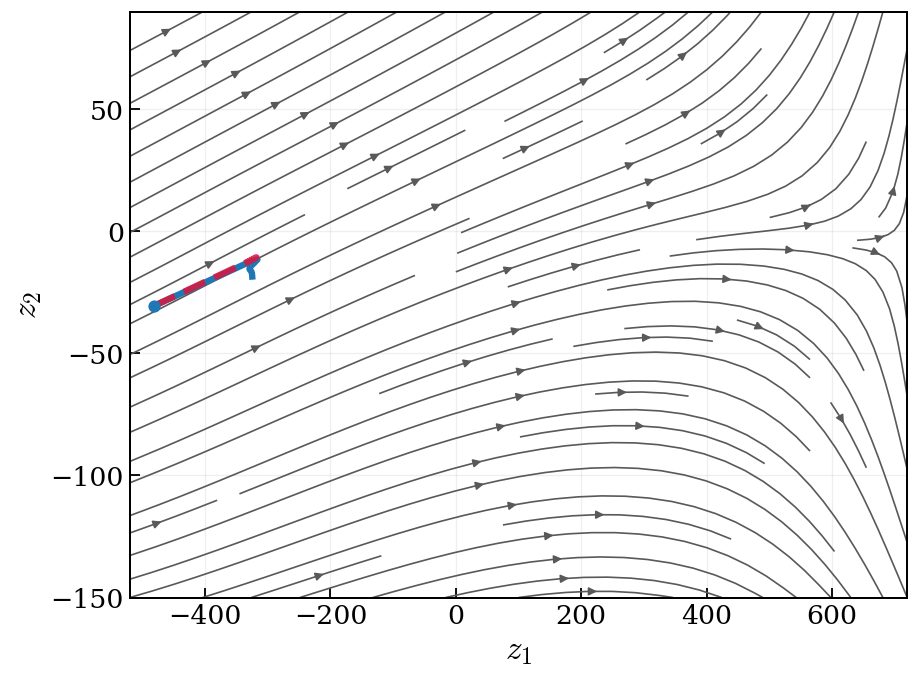

[slice plot] sim=804, traj_end_step=10
  conditioning time t = 14
  SP_raw = 200000
  e_raw  = 99994.7
  I_raw  = 108232
  G_ref shape = (2, 60, 60)


In [106]:
nodes_csv = "GOH_Nodes_Test_for_Visualization.csv"
elems_csv = "GOH_Elements_Test_for_Visualization.csv"

z1_lim = (-520, 720)
z2_lim = (-150, 90)

# First: generate the CNN rollout
rollout = rollout_single_sim_cnn_node(
    r_modes=9,
    sim_id=804,
    nodes_csv=nodes_csv,
    elems_csv=elems_csv,
)

# Then: make the z1-z2 slice plot using that rollout
slice_meta = plot_selected_sim_cnn_node_z1_z2_slice(
    r_modes=9,
    sim_id=804,
    rollout=rollout,
    traj_end_step=10,

    grid_n=25,
    normalize_arrows=False,
    use_streamplot=True,

    z1_lim=z1_lim,
    z2_lim=z2_lim,

    quiver_color="black",
    quiver_alpha=0.85,
    quiver_width=0.0035,
    quiver_headwidth=4.0,
    quiver_headlength=5.0,
    quiver_headaxislength=4.5,
    quiver_linewidth=0.6,
    arrow_length_frac=0.6,
    show_terminal_tangent=False,

    pred_linewidth=3.8,
    true_linewidth=3.8,
    true_alpha=0.85,
    title=None,
    show_true_traj=True,
    #save_path="Model_D_latent_sim_804_step_68.png",

    growth_key="g_pred_grid",   # only needed if that is the key name in rollout
)

## Plot Reconstructed Displacement

In [98]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


def plot_rollout_reconstructed_displacement_3d(
    rollout: dict,
    nodes_csv: str,
    elems_csv: str,
    step_idx: int | None = None,
    scale: float = 1.0,
    color_by: str = "disp_mag",   # "disp_mag", "ux", "uy", "uz"
    cmap: str = "viridis",
    vmin: float | None = None,
    vmax: float | None = None,
    show_undeformed: bool = True,
    undeformed_alpha: float = 0.18,
    deformed_alpha: float = 1.0,
    edgecolor: str | None = None,
    linewidth: float = 0.0,
    elev: float = 22,
    azim: float = -60,
    figsize=(9, 7),
    title: str | None = None,
    axis_equal: bool = True,
    show_colorbar: bool = True,
    save_path: str | None = None,
    save_dpi: int = 400,
):
    """
    Plot reconstructed predicted displacement on the bottom-surface mesh
    for a specified rollout timepoint.

    Parameters
    ----------
    rollout : dict
        Output from rollout_single_sim_vanilla_node(...), must contain:
          - "u_pred_nodes": (T, N, 3)
          - "t": (T,)
          - "sim_id"
    nodes_csv, elems_csv : str
        Mesh files used by load_bottom_surface_mesh_direct.
    step_idx : int or None
        Rollout time index to plot. Defaults to final step.
    scale : float
        Visual scaling applied to displacement before plotting.
    color_by : str
        One of: "disp_mag", "ux", "uy", "uz".
    vmin, vmax : float or None
        Fixed color limits. If None, inferred from the selected frame.
    """

    if "u_pred_nodes" not in rollout:
        raise KeyError("rollout must contain 'u_pred_nodes'.")

    u_pred_nodes = np.asarray(rollout["u_pred_nodes"], dtype=np.float64)
    t_arr = np.asarray(rollout.get("t", []), dtype=np.float64)

    if u_pred_nodes.ndim != 3 or u_pred_nodes.shape[2] != 3:
        raise ValueError(f"Expected u_pred_nodes shape (T, N, 3), got {u_pred_nodes.shape}")

    T, N, _ = u_pred_nodes.shape
    if step_idx is None:
        step_idx = T - 1
    step_idx = int(np.clip(step_idx, 0, T - 1))

    # Load bottom surface mesh
    node_xyz_bot, elem_conn_bot, node_ids_bot, elem_node_ids_bot = load_bottom_surface_mesh_direct(
        nodes_csv, elems_csv
    )

    node_xyz_bot = np.asarray(node_xyz_bot, dtype=np.float64)
    elem_conn_bot = np.asarray(elem_conn_bot)

    if node_xyz_bot.shape[0] != N:
        raise ValueError(
            f"Mesh node count ({node_xyz_bot.shape[0]}) does not match rollout u_pred_nodes ({N})."
        )

    u = u_pred_nodes[step_idx]
    x_def = node_xyz_bot + scale * u

    if color_by == "disp_mag":
        node_scalar = np.linalg.norm(u, axis=1)
        cbar_label = r"$\|\mathbf{u}\|$"
    elif color_by == "ux":
        node_scalar = u[:, 0]
        cbar_label = r"$u_x$"
    elif color_by == "uy":
        node_scalar = u[:, 1]
        cbar_label = r"$u_y$"
    elif color_by == "uz":
        node_scalar = u[:, 2]
        cbar_label = r"$u_z$"
    else:
        raise ValueError("color_by must be one of: 'disp_mag', 'ux', 'uy', 'uz'")

    # Build polygon faces and per-face scalar
    faces_def = []
    faces_und = []
    face_scalar = []

    for conn in elem_conn_bot:
        conn = np.asarray(conn, dtype=int)

        pts_def = x_def[conn]
        pts_und = node_xyz_bot[conn]

        faces_def.append(pts_def)
        faces_und.append(pts_und)

        # Average nodal scalar to face color
        face_scalar.append(np.mean(node_scalar[conn]))

    face_scalar = np.asarray(face_scalar, dtype=np.float64)

    # Fixed or automatic color limits
    cmin = np.min(face_scalar) if vmin is None else float(vmin)
    cmax = np.max(face_scalar) if vmax is None else float(vmax)

    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection="3d")

    if show_undeformed:
        poly_und = Poly3DCollection(
            faces_und,
            facecolor=(0.7, 0.7, 0.7, undeformed_alpha),
            edgecolor="none",
            linewidth=0.0,
        )
        ax.add_collection3d(poly_und)

    poly_def = Poly3DCollection(
        faces_def,
        linewidth=linewidth,
        edgecolor=edgecolor if edgecolor is not None else "none",
        alpha=deformed_alpha,
    )
    poly_def.set_array(face_scalar)
    poly_def.set_cmap(cmap)
    poly_def.set_clim(cmin, cmax)
    ax.add_collection3d(poly_def)

    # Set axes limits from both undeformed and deformed geometry
    xyz_all = np.vstack([node_xyz_bot, x_def])
    xmin, ymin, zmin = xyz_all.min(axis=0)
    xmax, ymax, zmax = xyz_all.max(axis=0)

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_zlim(zmin, zmax)

    if axis_equal:
        ranges = np.array([xmax - xmin, ymax - ymin, zmax - zmin], dtype=float)
        max_range = np.max(ranges)
        xmid = 0.5 * (xmin + xmax)
        ymid = 0.5 * (ymin + ymax)
        zmid = 0.5 * (zmin + zmax)

        ax.set_xlim(xmid - 0.5 * max_range, xmid + 0.5 * max_range)
        ax.set_ylim(ymid - 0.5 * max_range, ymid + 0.5 * max_range)
        ax.set_zlim(0, zmid + 0.5 * max_range)

    ax.view_init(elev=elev, azim=azim)

    xticks = ax.get_xticks()
    yticks = ax.get_yticks()
    zticks = ax.get_zticks()

    # hide the default z-axis line
    ax.zaxis.line.set_color((0, 0, 0, 0))
    
    # draw a custom z-axis line only up to the highest tick you want
    z0, z1 = ax.get_zlim()
    ztop = 80   # highest tick you want the visible axis to reach
    
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    
    # choose the corner where matplotlib is drawing that z-axis
    x_axis_corner = xmax
    y_axis_corner = ymax
    
    ax.plot(
        [x_axis_corner, x_axis_corner],
        [y_axis_corner, y_axis_corner],
        [z0, ztop],
        color='k',
        lw=1.2
    )
    
    ax.set_xticks([0, 100, 200])
    ax.set_yticks([0, 100, 200])
    ax.set_zticks([0, 80])
    ax.tick_params(axis='x', labelbottom=False)
    ax.tick_params(axis='y', labelleft=False)
    ax.tick_params(axis='z', labelleft=False)
    ax.grid(False)
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor('white')
    ax.yaxis.pane.set_edgecolor('white')
    ax.zaxis.pane.set_edgecolor('white')
    
    sim_id = rollout.get("sim_id", "unknown")
    t_val = t_arr[step_idx] if len(t_arr) > step_idx else step_idx

    if title is None:
        title = f"Predicted reconstructed displacement | sim={sim_id} | step={step_idx} | t={t_val:.4g}"
    ax.set_title(title)

    if show_colorbar:
        mappable = plt.cm.ScalarMappable(cmap=cmap)
        mappable.set_array(face_scalar)
        mappable.set_clim(cmin, cmax)
        cbar = fig.colorbar(mappable, ax=ax, shrink=0.75, pad=0.08)
        cbar.set_label(cbar_label)

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=save_dpi, bbox_inches="tight")
        print(f"[saved figure] {save_path}")

    plt.show()

    return {
        "step_idx": step_idx,
        "t": float(t_val) if np.isscalar(t_val) else t_val,
        "u": u,
        "x_def": x_def,
        "node_scalar": node_scalar,
        "face_scalar": face_scalar,
        "vmin_used": cmin,
        "vmax_used": cmax,
    }

[bottom surface mesh — robust]
  node_xyz_bot: (3721, 3)
  elem_conn_bot: (3600, 4)
  node_id range: 3722 7442
  conn min/max: 0 3720
[saved figure] Model_D_sim_804_rollout_disp_10_steps.png


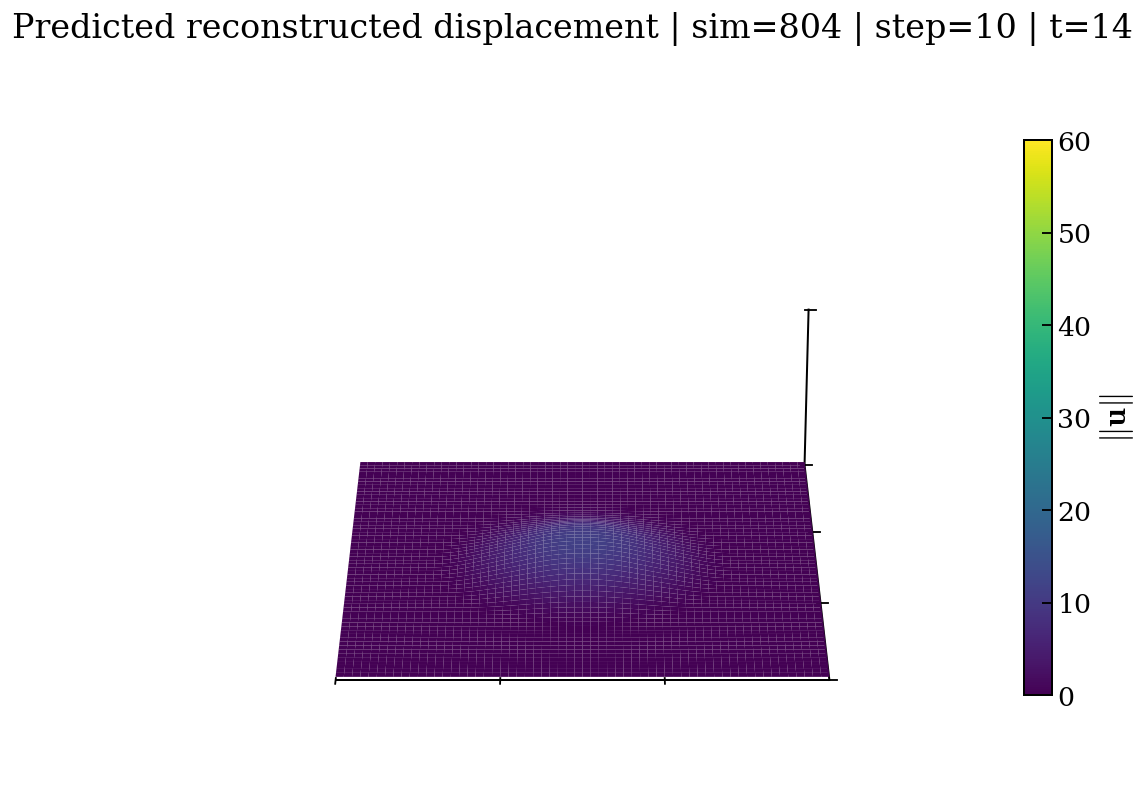

{'step_idx': 10,
 't': 14.0,
 'u': array([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]], shape=(3721, 3)),
 'x_def': array([[  0. ,   0. ,   1.5],
        [  0. ,   5. ,   1.5],
        [  0. ,  10. ,   1.5],
        ...,
        [300. , 290. ,   1.5],
        [300. , 295. ,   1.5],
        [300. , 300. ,   1.5]], shape=(3721, 3)),
 'node_scalar': array([0., 0., 0., ..., 0., 0., 0.], shape=(3721,)),
 'face_scalar': array([0., 0., 0., ..., 0., 0., 0.], shape=(3600,)),
 'vmin_used': 0.0,
 'vmax_used': 60.0}

In [104]:
plot_rollout_reconstructed_displacement_3d(
    rollout=rollout,
    nodes_csv=nodes_csv,
    elems_csv=elems_csv,
    step_idx=10,              # or None for final
    scale=1.0,
    color_by="disp_mag",
    cmap="viridis",
    show_undeformed=True,
    vmin=0.0,
    vmax=60.0,
    elev=25,
    azim=-90,
    save_dpi=500,
    save_path="Model_D_sim_804_rollout_disp_10_steps.png",

)

# Plot the True Displacement

In [3]:
import numpy as np
import zarr
DESIGN_ZARR_PATH = "Design_and_Metadata.zarr"

def load_sim_index_all(design_zarr_path):
    g_design = zarr.open_group(design_zarr_path, mode="r")
    mgrp = g_design["Mapping_indexes_and_metadata"]
    sim_index_all = np.asarray(mgrp["sim_index"], dtype=np.int64)
    return sim_index_all

def load_time_vals_all(design_zarr_path):
    g_design = zarr.open_group(design_zarr_path, mode="r")
    mgrp = g_design["Mapping_indexes_and_metadata"]
    time_vals_all = np.asarray(mgrp["time_vals"], dtype=np.float64)
    return time_vals_all

In [4]:
sim_index_all = load_sim_index_all(DESIGN_ZARR_PATH)
time_vals_all = load_time_vals_all(DESIGN_ZARR_PATH)

In [5]:
import numpy as np
import zarr
def build_job_to_sim_map():
    g_disp = zarr.open("Design_and_Metadata.zarr", mode="r")
    job_index_per_sim = g_disp["Mapping_indexes_and_metadata"]["job_index_per_sim"][:]

    return {int(job_id): int(sim_id) for sim_id, job_id in enumerate(job_index_per_sim)}

In [6]:
job_to_sim = build_job_to_sim_map()

In [7]:
import numpy as np

def load_bottom_surface_mesh_direct(nodes_csv: str, elems_csv: str):
    """
    Robust bottom-surface mesh loader:

    - elems_csv contains both layers; bottom layer is second half of rows
    - bottom nodes are defined as the unique node IDs referenced by bottom elements
      (this is the only assumption that cannot be broken by file ordering)

    Returns:
      node_xyz_bot : (Nbot, 3)
      elem_conn_bot: (Ne_bot, 4) 0-based indices into node_xyz_bot
      node_ids_bot : (Nbot,)     node IDs corresponding to node_xyz_bot rows
      elem_node_ids_bot : (Ne_bot,4) original node IDs for debugging
    """
    nodes = np.loadtxt(nodes_csv, delimiter=",")
    elems = np.loadtxt(elems_csv, delimiter=",")

    node_ids = nodes[:, 0].astype(np.int64)
    node_xyz = nodes[:, 1:4].astype(np.float64)

    elem_ids = elems[:, 0].astype(np.int64)
    elem_node_ids = elems[:, 1:5].astype(np.int64)
    Ne = elem_node_ids.shape[0]
    if Ne % 2 != 0:
        raise ValueError(f"Expected even number of elements (2 layers), got Ne={Ne}")

    # bottom layer = second half of element rows
    half = Ne // 2
    elem_node_ids_bot = elem_node_ids[half:, :]   # (Ne_bot, 4)

    # bottom node IDs = unique node IDs referenced by bottom elements
    bottom_node_ids = np.unique(elem_node_ids_bot.reshape(-1))

    # pull those nodes from nodes_csv
    # (use a dict for fast lookup by ID)
    id2xyz = {int(nid): node_xyz[i] for i, nid in enumerate(node_ids)}

    missing = [int(nid) for nid in bottom_node_ids if int(nid) not in id2xyz]
    if len(missing) > 0:
        raise ValueError(
            f"{len(missing)} node IDs referenced by bottom elements are missing from nodes_csv. "
            f"Example missing IDs: {missing[:10]}"
        )

    # build bottom node table, sorted by node_id
    node_ids_bot = np.sort(bottom_node_ids.astype(np.int64))
    node_xyz_bot = np.vstack([id2xyz[int(nid)] for nid in node_ids_bot]).astype(np.float64)

    # map node_id -> local index [0..Nbot-1]
    id2bot = {int(nid): i for i, nid in enumerate(node_ids_bot)}

    # remap element connectivity to local indices
    get_idx = np.vectorize(lambda nid: id2bot.get(int(nid), -1), otypes=[np.int64])
    elem_conn_bot = get_idx(elem_node_ids_bot)

    bad = np.where(elem_conn_bot < 0)
    if bad[0].size > 0:
        ei = int(bad[0][0])
        raise ValueError(
            "Internal mapping failure (shouldn't happen if missing-check passed).\n"
            f"Example bad elem row: {ei}\n"
            f"elem_node_ids_bot[ei] = {elem_node_ids_bot[ei]}\n"
            f"elem_conn_bot[ei]     = {elem_conn_bot[ei]}"
        )

    print("[bottom surface mesh — robust]")
    print("  node_xyz_bot:", node_xyz_bot.shape)
    print("  elem_conn_bot:", elem_conn_bot.shape)
    print("  node_id range:", int(node_ids_bot.min()), int(node_ids_bot.max()))
    print("  conn min/max:", int(elem_conn_bot.min()), int(elem_conn_bot.max()))

    return node_xyz_bot, elem_conn_bot, node_ids_bot, elem_node_ids_bot


In [8]:
import numpy as np
import zarr

def get_true_u_nodes_for_sim_step(
    sim_id: int,
    step_k: int,                       # index within this sim's timeline (0..T_true-1)
    sim_index: np.ndarray,
    time_vals: np.ndarray,
    zarr_disp_path: str = "displacements.zarr",
    snapshots_key: str = "snapshots",  # <-- per your note
) -> np.ndarray:
    """
    Returns u_true_nodes at sim local step_k as (N,3).

    Assumes displacements.zarr stores full displacement snapshots at:
        displacements.zarr/snapshots

    Supports snapshots array stored as (S,M) or (M,S),
    with flattening order [ux_block, uy_block, uz_block].
    """
    g = zarr.open_group(zarr_disp_path, mode="r")

    if snapshots_key not in g:
        raise KeyError(f"Could not find '{snapshots_key}' in {zarr_disp_path}. Available: {list(g.array_keys())}")

    snaps = g[snapshots_key]  # zarr array

    # global snapshot indices for this sim, sorted by time
    idx = np.where(sim_index == sim_id)[0]
    if idx.size == 0:
        raise ValueError(f"No snapshots for sim_id={sim_id}")
    t_s = time_vals[idx]
    order = np.argsort(t_s)
    idx_sorted = idx[order]

    if step_k < 0 or step_k >= idx_sorted.size:
        raise IndexError(f"step_k={step_k} out of range for sim length {idx_sorted.size}")

    gidx = int(idx_sorted[step_k])  # global snapshot index

    if snaps.ndim != 2:
        raise ValueError(f"Expected snapshots to be 2D, got shape {snaps.shape}")

    S = sim_index.shape[0]

    # pull snapshot vector u_flat of length M
    if snaps.shape[0] == S:          # (S,M)
        u_flat = np.asarray(snaps[gidx, :], dtype=np.float64)
    elif snaps.shape[1] == S:        # (M,S)
        u_flat = np.asarray(snaps[:, gidx], dtype=np.float64)
    else:
        raise ValueError(f"Snapshots shape {snaps.shape} doesn't match S={S} in either axis")

    M = u_flat.shape[0]
    if M % 3 != 0:
        raise ValueError(f"Expected M divisible by 3, got M={M}")
    N = M // 3

    ux = u_flat[0:N]
    uy = u_flat[N:2*N]
    uz = u_flat[2*N:3*N]
    return np.stack([ux, uy, uz], axis=1)  # (N,3)


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


def plot_true_displacement_3d(
    sim_id: int,
    step_k: int,
    sim_index: np.ndarray,
    time_vals: np.ndarray,
    nodes_csv: str,
    elems_csv: str,
    zarr_disp_path: str = "displacements.zarr",
    snapshots_key: str = "snapshots",
    scale: float = 1.0,
    color_by: str = "disp_mag",   # "disp_mag", "ux", "uy", "uz"
    cmap: str = "viridis",
    vmin: float | None = None,
    vmax: float | None = None,
    show_undeformed: bool = True,
    undeformed_alpha: float = 0.18,
    deformed_alpha: float = 1.0,
    edgecolor: str | None = None,
    linewidth: float = 0.0,
    elev: float = 22,
    azim: float = -60,
    figsize=(9, 7),
    title: str | None = None,
    axis_equal: bool = True,
    show_colorbar: bool = True,
    save_path: str | None = None,
    save_dpi: int = 400,
):
    """
    Plot the TRUE displacement field on the bottom-surface mesh
    for a specified sim_id and local step_k.

    Uses get_true_u_nodes_for_sim_step(...) to pull the full nodal truth
    displacement at the requested step, then visualizes it using the same
    style as plot_rollout_reconstructed_displacement_3d(...).
    """

    # --- true displacement lookup ---
    u_true_nodes = get_true_u_nodes_for_sim_step(
        sim_id=sim_id,
        step_k=step_k,
        sim_index=sim_index,
        time_vals=time_vals,
        zarr_disp_path=zarr_disp_path,
        snapshots_key=snapshots_key,
    )
    u_true_nodes = np.asarray(u_true_nodes, dtype=np.float64)

    if u_true_nodes.ndim != 2 or u_true_nodes.shape[1] != 3:
        raise ValueError(f"Expected u_true_nodes shape (N,3), got {u_true_nodes.shape}")

    N = u_true_nodes.shape[0]

    # --- time lookup for labeling ---
    idx = np.where(sim_index == sim_id)[0]
    if idx.size == 0:
        raise ValueError(f"No snapshots found for sim_id={sim_id}")
    t_s = time_vals[idx]
    order = np.argsort(t_s)
    idx_sorted = idx[order]

    if step_k < 0 or step_k >= idx_sorted.size:
        raise IndexError(f"step_k={step_k} out of range for sim length {idx_sorted.size}")

    t_val = float(time_vals[idx_sorted[step_k]])

    # --- load bottom surface mesh ---
    node_xyz_bot, elem_conn_bot, node_ids_bot, elem_node_ids_bot = load_bottom_surface_mesh_direct(
        nodes_csv, elems_csv
    )

    node_xyz_bot = np.asarray(node_xyz_bot, dtype=np.float64)
    elem_conn_bot = np.asarray(elem_conn_bot)

    if node_xyz_bot.shape[0] != N:
        raise ValueError(
            f"Mesh node count ({node_xyz_bot.shape[0]}) does not match true displacement node count ({N})."
        )

    u = u_true_nodes
    x_def = node_xyz_bot + scale * u

    # --- choose coloring ---
    if color_by == "disp_mag":
        node_scalar = np.linalg.norm(u, axis=1)
        cbar_label = r"$\|\mathbf{u}\|$"
    elif color_by == "ux":
        node_scalar = u[:, 0]
        cbar_label = r"$u_x$"
    elif color_by == "uy":
        node_scalar = u[:, 1]
        cbar_label = r"$u_y$"
    elif color_by == "uz":
        node_scalar = u[:, 2]
        cbar_label = r"$u_z$"
    else:
        raise ValueError("color_by must be one of: 'disp_mag', 'ux', 'uy', 'uz'")

    # --- build polygon faces and per-face scalar ---
    faces_def = []
    faces_und = []
    face_scalar = []

    for conn in elem_conn_bot:
        conn = np.asarray(conn, dtype=int)

        pts_def = x_def[conn]
        pts_und = node_xyz_bot[conn]

        faces_def.append(pts_def)
        faces_und.append(pts_und)

        # average nodal scalar to face color
        face_scalar.append(np.mean(node_scalar[conn]))

    face_scalar = np.asarray(face_scalar, dtype=np.float64)

    # --- fixed or automatic color limits ---
    cmin = np.min(face_scalar) if vmin is None else float(vmin)
    cmax = np.max(face_scalar) if vmax is None else float(vmax)

    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection="3d")

    if show_undeformed:
        poly_und = Poly3DCollection(
            faces_und,
            facecolor=(0.7, 0.7, 0.7, undeformed_alpha),
            edgecolor="none",
            linewidth=0.0,
        )
        ax.add_collection3d(poly_und)

    poly_def = Poly3DCollection(
        faces_def,
        linewidth=linewidth,
        edgecolor=edgecolor if edgecolor is not None else "none",
        alpha=deformed_alpha,
    )
    poly_def.set_array(face_scalar)
    poly_def.set_cmap(cmap)
    poly_def.set_clim(cmin, cmax)
    ax.add_collection3d(poly_def)

    # --- axes limits from undeformed + deformed geometry ---
    xyz_all = np.vstack([node_xyz_bot, x_def])
    xmin, ymin, zmin = xyz_all.min(axis=0)
    xmax, ymax, zmax = xyz_all.max(axis=0)

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_zlim(zmin, zmax)

    if axis_equal:
        ranges = np.array([xmax - xmin, ymax - ymin, zmax - zmin], dtype=float)
        max_range = np.max(ranges)
    
        xmid = 0.5 * (xmin + xmax)
        ymid = 0.5 * (ymin + ymax)
    
        ax.set_xlim(xmid - 0.5 * max_range, xmid + 0.5 * max_range)
        ax.set_ylim(ymid - 0.5 * max_range, ymid + 0.5 * max_range)
        ax.set_zlim(0.0, max_range)

    ax.view_init(elev=elev, azim=azim)

    # --- custom styling to match your rollout figure ---
    ax.zaxis.line.set_color((0, 0, 0, 0))

    z0, z1 = ax.get_zlim()
    ztop = 80

    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    x_axis_corner = xmax
    y_axis_corner = ymax

    ax.plot(
        [x_axis_corner, x_axis_corner],
        [y_axis_corner, y_axis_corner],
        [z0, ztop],
        color="k",
        lw=1.2
    )

    ax.set_xticks([0, 100, 200])
    ax.set_yticks([0, 100, 200])
    ax.set_zticks([0, 80])
    ax.tick_params(axis="x", labelbottom=False)
    ax.tick_params(axis="y", labelleft=False)
    ax.tick_params(axis="z", labelleft=False)
    ax.grid(False)
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor("white")
    ax.yaxis.pane.set_edgecolor("white")
    ax.zaxis.pane.set_edgecolor("white")

    if title is None:
        title = f"True displacement | sim={sim_id} | step={step_k} | t={t_val:.4g}"
    ax.set_title(title)

    if show_colorbar:
        mappable = plt.cm.ScalarMappable(cmap=cmap)
        mappable.set_array(face_scalar)
        mappable.set_clim(cmin, cmax)
        cbar = fig.colorbar(mappable, ax=ax, shrink=0.75, pad=0.08)
        cbar.set_label(cbar_label)

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=save_dpi, bbox_inches="tight")
        print(f"[saved figure] {save_path}")

    plt.show()

    return {
        "sim_id": sim_id,
        "step_k": step_k,
        "t": t_val,
        "u": u,
        "x_def": x_def,
        "node_scalar": node_scalar,
        "face_scalar": face_scalar,
        "vmin_used": cmin,
        "vmax_used": cmax,
    }

[bottom surface mesh — robust]
  node_xyz_bot: (3721, 3)
  elem_conn_bot: (3600, 4)
  node_id range: 3722 7442
  conn min/max: 0 3720


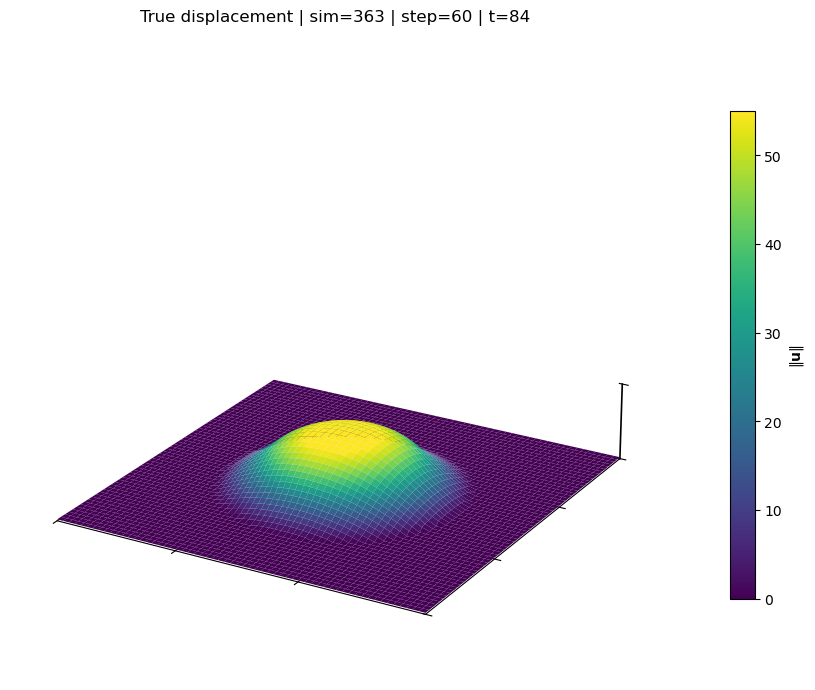

In [10]:
nodes_csv = "GOH_Nodes_Test_for_Visualization.csv"
elems_csv = "GOH_Elements_Test_for_Visualization.csv"

out_true = plot_true_displacement_3d(
    sim_id=job_to_sim[394],
    step_k=60,
    sim_index=sim_index_all,
    time_vals=time_vals_all,
    nodes_csv=nodes_csv,
    elems_csv=elems_csv,
    zarr_disp_path="displacements.zarr",
    snapshots_key="snapshots",
    scale=1.0,
    color_by="disp_mag",
    cmap="viridis",
    vmin=0,
    vmax=55,
    #save_path="true_disp_job394_step60.png",
)

In [13]:
import numpy as np

def build_bottom_surface_elem_grid_mapping(
    nodes_csv: str = "GOH_Nodes_Test_for_Visualization.csv",
    elems_csv: str = "GOH_Elements_Test_for_Visualization.csv",
    tol_xy: float = 1e-8,
):
    """
    Build a structured (H,W) grid mapping for a two-layer quad mesh by selecting
    ONLY the bottom layer (smaller element centroid z) at each in-plane (x,y) cell.

    Assumed CSV formats (no headers):
      Nodes: [node_id, x, y, z]   (z required here)
      Elems: [elem_id, n1, n2, n3, n4]  (quads)

    Returns:
      H, W: inferred grid shape from unique centroid x/y positions
      bottom_elem_idx: (H*W,) element indices (0..Ne-1) selecting bottom element per cell
      cell_xy: (H*W, 2) centroid (x,y) per cell (for debugging)
      elem_id: (Ne,) element ids
      node_id: (Nn,) node ids
      node_xyz: (Nn,3)
      elem_conn_local: (Ne,4) node indices (0..Nn-1)
      xs, ys: grid lines (unique x and y centroid coords)
    """
    # ---- load nodes ----
    nodes = np.loadtxt(nodes_csv, delimiter=",", dtype=np.float64)
    if nodes.ndim != 2 or nodes.shape[1] < 4:
        raise ValueError(
            f"Nodes CSV must have 4 cols [id,x,y,z] (no headers). Got shape {nodes.shape}"
        )

    node_id = nodes[:, 0].astype(np.int64)
    node_xyz = nodes[:, 1:4].astype(np.float64)  # (Nn,3)

    node_id_to_local = {int(nid): i for i, nid in enumerate(node_id)}

    # ---- load elements ----
    elems = np.loadtxt(elems_csv, delimiter=",", dtype=np.int64)
    if elems.ndim != 2 or elems.shape[1] < 5:
        raise ValueError(
            f"Elements CSV must have >=5 cols [eid,n1,n2,n3,n4] (no headers). Got shape {elems.shape}"
        )

    elem_id = elems[:, 0].astype(np.int64)
    elem_conn_ids = elems[:, 1:5].astype(np.int64)  # (Ne,4)
    Ne = elem_conn_ids.shape[0]

    # Convert node IDs -> local node indices
    elem_conn_local = np.empty((Ne, 4), dtype=np.int64)
    for a in range(4):
        try:
            elem_conn_local[:, a] = np.array(
                [node_id_to_local[int(nid)] for nid in elem_conn_ids[:, a]],
                dtype=np.int64
            )
        except KeyError as e:
            raise KeyError(f"Element connectivity references node id not found: {e}")

    # ---- element centroids ----
    cent = node_xyz[elem_conn_local].mean(axis=1)  # (Ne,3)
    xe, ye, ze = cent[:, 0], cent[:, 1], cent[:, 2]

    # Quantize x,y to remove floating noise
    xe_q = np.round(xe / tol_xy) * tol_xy
    ye_q = np.round(ye / tol_xy) * tol_xy

    # Build grid lines
    xs = np.unique(xe_q); xs.sort()
    ys = np.unique(ye_q); ys.sort()
    W = xs.size
    H = ys.size
    n_cells = H * W

    ix = np.searchsorted(xs, xe_q)
    iy = np.searchsorted(ys, ye_q)
    cell = (iy * W + ix).astype(np.int64)  # (Ne,)

    # ---- select bottom element per cell (min z) ----
    bottom_elem_idx = np.full(n_cells, -1, dtype=np.int64)
    best_z = np.full(n_cells, np.inf, dtype=np.float64)

    for e in range(Ne):
        c = cell[e]
        if ze[e] < best_z[c]:
            best_z[c] = ze[e]
            bottom_elem_idx[c] = e

    occupied = bottom_elem_idx >= 0
    if not np.all(occupied):
        missing = np.where(~occupied)[0][:10]
        raise ValueError(
            f"Some grid cells have no assigned element (unexpected for structured mesh). "
            f"Example missing cell indices: {missing}"
        )

    # Debug: check it really reduced 2 layers -> 1 per cell
    # Count elements per cell (should be 2 for most cells in a 2-layer mesh)
    counts = np.bincount(cell, minlength=n_cells)
    print(f"[bottom mapping] Ne={Ne}, grid H={H}, W={W}, H*W={n_cells}")
    print(f"[bottom mapping] per-cell counts: min={counts[counts>0].min()}, max={counts.max()}, "
          f"unique occupied cells={np.count_nonzero(counts)}")
    print(f"[bottom mapping] selected bottom elems: {bottom_elem_idx.shape[0]} (should equal H*W)")

    # For debugging: centroid (x,y) per cell (from selected bottom element)
    cell_xy = np.stack([xe[bottom_elem_idx], ye[bottom_elem_idx]], axis=1)

    return H, W, bottom_elem_idx, cell_xy, elem_id, node_id, node_xyz, elem_conn_local, xs, ys


def rasterize_bottom_surface_field(
    vec_elem: np.ndarray,          # (Ne,)
    H: int, W: int,
    bottom_elem_idx: np.ndarray,   # (H*W,)
):
    """
    Convert an element field vector (Ne,) into a bottom-surface grid image (H,W)
    by selecting vec_elem at bottom_elem_idx for each cell.
    """
    flat = vec_elem[bottom_elem_idx]          # (H*W,)
    return flat.reshape(H, W)


In [14]:
#Global Cache for the Coord and Connectivity CSVs
_BOTTOM_GRID_CACHE = None

def get_bottom_grid_cache():
    global _BOTTOM_GRID_CACHE
    if _BOTTOM_GRID_CACHE is None:
        H, W, bottom_idx, *_ = build_bottom_surface_elem_grid_mapping(
            nodes_csv="GOH_Nodes_Test_for_Visualization.csv",
            elems_csv="GOH_Elements_Test_for_Visualization.csv",
            tol_xy=1e-8,
        )
        _BOTTOM_GRID_CACHE = (H, W, bottom_idx)
    return _BOTTOM_GRID_CACHE


In [15]:
H, W, bottom_idx = get_bottom_grid_cache()
print("H =", H)
print("W =", W)
print("bottom_idx shape =", bottom_idx.shape)

[bottom mapping] Ne=7200, grid H=60, W=60, H*W=3600
[bottom mapping] per-cell counts: min=2, max=2, unique occupied cells=3600
[bottom mapping] selected bottom elems: 3600 (should equal H*W)
H = 60
W = 60
bottom_idx shape = (3600,)


In [21]:
import zarr

def load_elem_growth_for_sim(
    sim_id: int,
    sim_index: np.ndarray,
    time_vals: np.ndarray,
    zarr_sdv_path: str = "ip_growth_elem.zarr",
    folder_x: str = "snaps_SDV1",
    folder_y: str = "snaps_SDV4",
):
    """
    Returns element growth for this sim for ALL frames:
      t_sim: (T,)
      Gx_sim: (T, Ne)
      Gy_sim: (T, Ne)
      idx_sorted: (T,) global snapshot indices for this sim
    """
    g_sdv = zarr.open_group(zarr_sdv_path, mode="r")

    def _load_snap_folder(folder_name: str) -> np.ndarray:
        candidates = [
            f"{folder_name}/{folder_name}",
            f"{folder_name}/data",
            f"{folder_name}/snaps",
            f"{folder_name}",
        ]
        last_err = None
        for key in candidates:
            try:
                return np.asarray(g_sdv[key], dtype=np.float32)
            except Exception as e:
                last_err = e
        raise KeyError(f"Could not load '{folder_name}'. Tried={candidates}. Last error={repr(last_err)}")

    Gx_raw = _load_snap_folder(folder_x)
    Gy_raw = _load_snap_folder(folder_y)

    # select frames for this sim
    idx = np.where(sim_index == sim_id)[0]
    if idx.size < 2:
        raise ValueError(f"Sim {sim_id} has too few frames ({idx.size}).")

    t_s = time_vals[idx]
    order = np.argsort(t_s)
    idx_sorted = idx[order]
    t_sim = t_s[order]

    # Make snapshot-major: (S, Ne)
    S = sim_index.shape[0]
    if Gx_raw.shape[1] == S:   # (Ne, S)
        Gx_all = Gx_raw.T
    else:                      # assume (S, Ne)
        Gx_all = Gx_raw

    if Gy_raw.shape[1] == S:
        Gy_all = Gy_raw.T
    else:
        Gy_all = Gy_raw

    # slice sim
    Gx_sim = Gx_all[idx_sorted, :]  # (T, Ne)
    Gy_sim = Gy_all[idx_sorted, :]  # (T, Ne)

    return t_sim, Gx_sim, Gy_sim, idx_sorted


In [22]:
import numpy as np

def get_true_bottom_growth_grid_for_sim_step(
    sim_id: int,
    step_k: int,                      # 0-based within this sim after sorting by time
    sim_index: np.ndarray,
    time_vals: np.ndarray,
    H: int,
    W: int,
    zarr_sdv_path: str = "ip_growth_elem.zarr",
    folder_x: str = "snaps_SDV1",
    folder_y: str = "snaps_SDV4",
):
    """
    Returns:
      G_true_grid: (2,H,W) raw (not normalized), channels: [Gx, Gy]
    """
    t_sim, Gx_sim_elem, Gy_sim_elem, _ = load_elem_growth_for_sim(
        sim_id=sim_id,
        sim_index=sim_index,
        time_vals=time_vals,
        zarr_sdv_path=zarr_sdv_path,
        folder_x=folder_x,
        folder_y=folder_y,
    )

    if step_k < 0 or step_k >= Gx_sim_elem.shape[0]:
        raise IndexError(f"step_k={step_k} out of range for sim length T={Gx_sim_elem.shape[0]}")

    Ne_full = Gx_sim_elem.shape[1]
    if Ne_full % 2 != 0:
        raise ValueError(f"Expected even Ne from growth arrays, got Ne={Ne_full}")
    half = Ne_full // 2

    gx = Gx_sim_elem[step_k, half:]   # bottom half
    gy = Gy_sim_elem[step_k, half:]

    if gx.shape[0] != H * W:
        raise ValueError(f"Expected bottom elems H*W={H*W}, got {gx.shape[0]}")

    G_true = np.zeros((2, H, W), dtype=np.float32)
    G_true[0] = gx.reshape(H, W)
    G_true[1] = gy.reshape(H, W)
    return G_true


In [32]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection


def plot_true_growth_2d(
    sim_id: int,
    step_k: int,
    sim_index: np.ndarray,
    time_vals: np.ndarray,
    H: int,
    W: int,
    nodes_csv: str,
    elems_csv: str,
    plot_on: str = "deformed",      # "deformed" or "undeformed"
    component: str = "gx",          # "gx" or "gy"
    zarr_sdv_path: str = "ip_growth_elem.zarr",
    folder_x: str = "snaps_SDV1",
    folder_y: str = "snaps_SDV4",
    zarr_disp_path: str = "displacements.zarr",
    snapshots_key: str = "snapshots",
    scale: float = 1.0,
    cmap: str = "viridis",
    vmin: float | None = None,
    vmax: float | None = None,
    show_reference_surface: bool = True,
    reference_alpha: float = 0.18,
    surface_alpha: float = 1.0,
    edgecolor: str | None = None,
    linewidth: float = 0.0,
    figsize=(7, 6),
    title: str | None = None,
    axis_equal: bool = True,
    show_colorbar: bool = True,
    save_path: str | None = None,
    save_dpi: int = 400,
):
    """
    Plot the true bottom-surface growth field (Gx or Gy) in 2D on either the
    undeformed or deformed bottom-surface coordinates, projected onto the x-y plane.
    """

    # ----------------------------
    # true growth lookup on bottom surface
    # ----------------------------
    G_true = get_true_bottom_growth_grid_for_sim_step(
        sim_id=sim_id,
        step_k=step_k,
        sim_index=sim_index,
        time_vals=time_vals,
        H=H,
        W=W,
        zarr_sdv_path=zarr_sdv_path,
        folder_x=folder_x,
        folder_y=folder_y,
    )
    G_true = np.asarray(G_true, dtype=np.float64)

    if G_true.shape != (2, H, W):
        raise ValueError(f"Expected G_true shape (2,{H},{W}), got {G_true.shape}")

    if component.lower() == "gx":
        elem_scalar_grid = G_true[0]
        cbar_label = r"$G_x$"
    elif component.lower() == "gy":
        elem_scalar_grid = G_true[1]
        cbar_label = r"$G_y$"
    else:
        raise ValueError("component must be 'gx' or 'gy'")

    elem_scalar_flat = elem_scalar_grid.reshape(-1)

    # ----------------------------
    # true displacement lookup
    # ----------------------------
    u_true_nodes = get_true_u_nodes_for_sim_step(
        sim_id=sim_id,
        step_k=step_k,
        sim_index=sim_index,
        time_vals=time_vals,
        zarr_disp_path=zarr_disp_path,
        snapshots_key=snapshots_key,
    )
    u_true_nodes = np.asarray(u_true_nodes, dtype=np.float64)

    if u_true_nodes.ndim != 2 or u_true_nodes.shape[1] != 3:
        raise ValueError(f"Expected u_true_nodes shape (N,3), got {u_true_nodes.shape}")

    # ----------------------------
    # time lookup
    # ----------------------------
    idx = np.where(sim_index == sim_id)[0]
    if idx.size == 0:
        raise ValueError(f"No snapshots found for sim_id={sim_id}")
    t_s = time_vals[idx]
    order = np.argsort(t_s)
    idx_sorted = idx[order]

    if step_k < 0 or step_k >= idx_sorted.size:
        raise IndexError(f"step_k={step_k} out of range for sim length {idx_sorted.size}")

    t_val = float(time_vals[idx_sorted[step_k]])

    # ----------------------------
    # load bottom surface mesh
    # ----------------------------
    node_xyz_bot, elem_conn_bot, *_ = load_bottom_surface_mesh_direct(nodes_csv, elems_csv)
    node_xyz_bot = np.asarray(node_xyz_bot, dtype=np.float64)
    elem_conn_bot = np.asarray(elem_conn_bot, dtype=int)

    N = node_xyz_bot.shape[0]
    if u_true_nodes.shape[0] != N:
        raise ValueError(
            f"Mesh node count ({N}) does not match u_true_nodes count ({u_true_nodes.shape[0]})."
        )

    x_und = node_xyz_bot
    x_def = node_xyz_bot + scale * u_true_nodes

    plot_on_l = plot_on.lower()
    if plot_on_l == "undeformed":
        verts_main_xyz = x_und
        verts_ref_xyz = x_def
    elif plot_on_l == "deformed":
        verts_main_xyz = x_def
        verts_ref_xyz = x_und
    else:
        raise ValueError("plot_on must be 'undeformed' or 'deformed'")

    # project to x-y plane
    verts_main_xy = verts_main_xyz[:, :2]
    verts_ref_xy = verts_ref_xyz[:, :2]

    if elem_scalar_flat.shape[0] != elem_conn_bot.shape[0]:
        raise ValueError(
            f"Expected H*W={H*W} element scalars to match bottom mesh elements "
            f"({elem_conn_bot.shape[0]}), got {elem_scalar_flat.shape[0]}"
        )

    polys_main = []
    polys_ref = []
    face_scalar = []

    for e, conn in enumerate(elem_conn_bot):
        conn = np.asarray(conn, dtype=int)
        polys_main.append(verts_main_xy[conn])
        polys_ref.append(verts_ref_xy[conn])
        face_scalar.append(elem_scalar_flat[e])

    face_scalar = np.asarray(face_scalar, dtype=np.float64)

    cmin = np.min(face_scalar) if vmin is None else float(vmin)
    cmax = np.max(face_scalar) if vmax is None else float(vmax)

    # ----------------------------
    # plot
    # ----------------------------
    fig, ax = plt.subplots(figsize=figsize)

    if show_reference_surface:
        poly_ref = PolyCollection(
            polys_ref,
            facecolor=(0.7, 0.7, 0.7, reference_alpha),
            edgecolor="none",
            linewidth=0.0,
        )
        ax.add_collection(poly_ref)

    poly_main = PolyCollection(
        polys_main,
        edgecolor=edgecolor if edgecolor is not None else "none",
        linewidth=linewidth,
        alpha=surface_alpha,
        cmap=cmap,
    )
    poly_main.set_array(face_scalar)
    poly_main.set_clim(cmin, cmax)
    ax.add_collection(poly_main)

    # axes limits
    xy_all = np.vstack([verts_main_xy, verts_ref_xy])
    xmin, ymin = xy_all.min(axis=0)
    xmax, ymax = xy_all.max(axis=0)

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    if axis_equal:
        ax.set_aspect("equal", adjustable="box")

    ax.set_xticks([0, 100, 200])
    ax.set_yticks([0, 100, 200])
    ax.tick_params(axis="x", labelbottom=False)
    ax.tick_params(axis="y", labelleft=False)
    ax.grid(False)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    if title is None:
        where_txt = "deformed" if plot_on_l == "deformed" else "undeformed"
        comp_txt = "x-growth" if component.lower() == "gx" else "y-growth"
        title = f"True {comp_txt} on {where_txt} mesh | sim={sim_id} | step={step_k} | t={t_val:.4g}"
    ax.set_title(title)

    if show_colorbar:
        cbar = fig.colorbar(poly_main, ax=ax, shrink=0.85, pad=0.03)
        cbar.set_label(cbar_label)

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=save_dpi, bbox_inches="tight")
        print(f"[saved figure] {save_path}")

    plt.show()

    return {
        "sim_id": sim_id,
        "step_k": step_k,
        "t": t_val,
        "component": component.lower(),
        "plot_on": plot_on_l,
        "u_true_nodes": u_true_nodes,
        "verts_main_xy": verts_main_xy,
        "verts_ref_xy": verts_ref_xy,
        "elem_scalar_grid": elem_scalar_grid,
        "face_scalar": face_scalar,
        "vmin_used": cmin,
        "vmax_used": cmax,
    }

[bottom surface mesh — robust]
  node_xyz_bot: (3721, 3)
  elem_conn_bot: (3600, 4)
  node_id range: 3722 7442
  conn min/max: 0 3720
[saved figure] true_gy_job70_step30.png


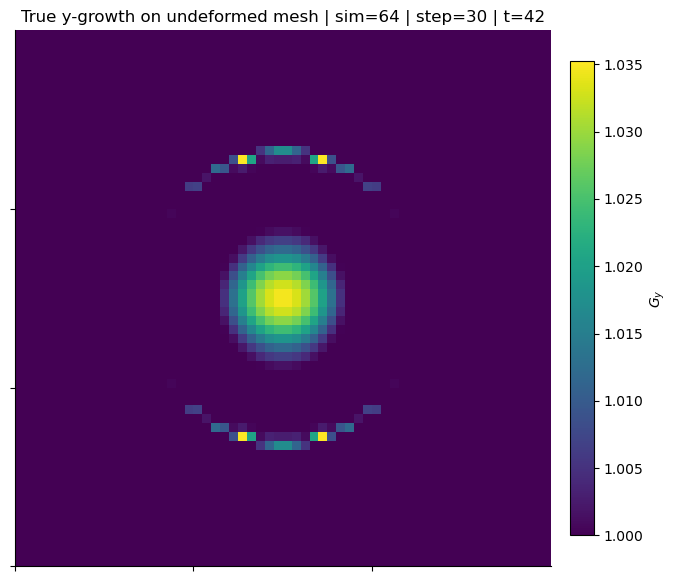

{'sim_id': 64,
 'step_k': 30,
 't': 42.0,
 'component': 'gy',
 'plot_on': 'undeformed',
 'u_true_nodes': array([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]], shape=(3721, 3)),
 'verts_main_xy': array([[  0.,   0.],
        [  0.,   5.],
        [  0.,  10.],
        ...,
        [300., 290.],
        [300., 295.],
        [300., 300.]], shape=(3721, 2)),
 'verts_ref_xy': array([[  0.,   0.],
        [  0.,   5.],
        [  0.,  10.],
        ...,
        [300., 290.],
        [300., 295.],
        [300., 300.]], shape=(3721, 2)),
 'elem_scalar_grid': array([[1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        ...,
        [1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.]], shape=(60, 60)),
 'face_scalar': array([1., 1., 1., ..., 1., 1., 1.], shape=(3600,)),
 'vmin_used': np.

In [50]:
plot_true_growth_2d(
    sim_id=job_to_sim[70],
    step_k=30,
    sim_index=sim_index_all,
    time_vals=time_vals_all,
    H=H,
    W=W,
    nodes_csv=nodes_csv,
    elems_csv=elems_csv,
    component="gy",
    plot_on="undeformed",
    save_path="true_gy_job70_step30.png",
)